In [ ]:
# ============================================================
# INDEPENDENT BULK LAW + CONDITIONAL FRACTIONAL FLOOR TO Rs_free
# Self-contained single Colab cell
# ============================================================

import os, re, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------------
# USER SETTINGS
# -----------------------------
BASELINE_CSV = "/content/mts_field_scaling_best_detail.csv"
SEARCH_ROOTS = ["/content"]
ROT_PATTERN = "*rotmod*.dat"

# Best independent bulk law from your scan
F_BULK = 0.90
ZETA   = 0.15
XI     = -0.20
KAPPA  = 2.0

# Scan for conditional Rs floor:
# Rs_bulk = Rs_free * (chi/chi_med)^zeta * (lev_free/lev_med)^xi
# Rs_eff  = max(Rs_bulk, c * Rs_free) if lev_free >= L0 else Rs_bulk
#
# This directly targets the pattern:
# rlever_high failures = Rs_eff shrunk too far below Rs_free in high-lev systems
C_SCAN  = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80]
L0_SCAN = [15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 75.0, 100.0]

# QC
MIN_NPTS   = 10
RLEVER_MIN = 2.0
RLEVER_MAX = 50.0

OUTDIR = "/content/mts_independent_fractional_floor_scan"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# HELPERS
# -----------------------------
def norm_gal(s):
    s = str(s).strip().upper()
    s = re.sub(r"_ROTMOD.*$", "", s)
    s = re.sub(r"\.DAT$", "", s)
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s

def discover_rotmod_files(roots):
    files = []
    for root in roots:
        files.extend(glob.glob(os.path.join(root, "**", ROT_PATTERN), recursive=True))
    return sorted(set(files))

def robust_read_rotmod(path):
    try:
        df = pd.read_csv(
            path,
            delim_whitespace=True,
            comment="#",
            header=None,
            engine="python"
        )
    except Exception:
        return None

    if df is None or df.shape[1] < 2:
        return None

    base_names = ["r", "vobs", "evobs", "vgas", "vdisk", "vbul"]
    rename = {i: base_names[i] for i in range(min(len(base_names), df.shape[1]))}
    df = df.rename(columns=rename)

    if "r" not in df.columns or "vobs" not in df.columns:
        return None

    for c in ["evobs", "vgas", "vdisk", "vbul"]:
        if c not in df.columns:
            df[c] = np.nan

    for c in ["r", "vobs", "evobs", "vgas", "vdisk", "vbul"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["r", "vobs"]).copy()
    df = df[df["r"] > 0].sort_values("r").reset_index(drop=True)

    if len(df) < 5:
        return None

    if df["evobs"].isna().all():
        df["evobs"] = np.maximum(0.05 * np.abs(df["vobs"]), 2.0)
    else:
        ev = df["evobs"].to_numpy(dtype=float)
        bad = ~np.isfinite(ev) | (ev <= 0)
        fallback = np.maximum(0.05 * np.abs(df["vobs"].to_numpy(dtype=float)), 2.0)
        ev[bad] = fallback[bad]
        df["evobs"] = ev

    for c in ["vgas", "vdisk", "vbul"]:
        arr = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        arr[~np.isfinite(arr)] = 0.0
        df[c] = arr

    return df

def detect_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Missing required column. Need one of {candidates}. Found: {list(df.columns)}")
    return None

def master_shape(r, Rs, kappa):
    x = np.maximum(np.asarray(r, dtype=float) / max(Rs, 1e-12), 0.0)
    return np.sqrt(np.maximum(1.0 - np.exp(-(x ** kappa)), 0.0))

def fit_vinf_linear(r, vobs, evobs, Rs, kappa):
    s = master_shape(r, Rs, kappa)
    w = 1.0 / np.maximum(np.asarray(evobs, dtype=float), 1e-12) ** 2
    den = np.sum(w * s * s)
    if den <= 0 or not np.isfinite(den):
        return np.nan, None, np.nan
    Vinf = np.sum(w * s * np.asarray(vobs, dtype=float)) / den
    if not np.isfinite(Vinf):
        return np.nan, None, np.nan
    pred = Vinf * s
    rmse = float(np.sqrt(np.mean((pred - np.asarray(vobs, dtype=float)) ** 2)))
    return float(Vinf), pred, rmse

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def linear_reg(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan
    A = np.vstack([x, np.ones_like(x)]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    slope, intercept = coef
    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return float(slope), float(r2)

# -----------------------------
# LOAD BASELINE
# -----------------------------
base = pd.read_csv(BASELINE_CSV)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {BASELINE_CSV}")

col_gal  = detect_col(base, ["gal", "galaxy", "Galaxy"])
col_Mb   = detect_col(base, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary", "M_b"])
col_Rs   = detect_col(base, ["Rs_fit", "Rs", "R_s"])
col_Vinf = detect_col(base, ["Vinf_fit", "Vinf", "V_inf"])
col_rmse = detect_col(base, ["rmse", "RMSE"])
col_rlev = detect_col(base, ["rlever", "r_lever"])
col_a0   = detect_col(base, ["a0_eff", "a0", "a0eff"], required=False)
col_qc   = detect_col(base, ["qc_pass", "qc"], required=False)

base = base.copy()
base["gal_norm"]    = base[col_gal].map(norm_gal)
base["Mb_proxy"]    = pd.to_numeric(base[col_Mb], errors="coerce")
base["Rs_free"]     = pd.to_numeric(base[col_Rs], errors="coerce")
base["Vinf_free"]   = pd.to_numeric(base[col_Vinf], errors="coerce")
base["rmse_free"]   = pd.to_numeric(base[col_rmse], errors="coerce")
base["rlever_free"] = pd.to_numeric(base[col_rlev], errors="coerce")
base["a0_eff_free"] = pd.to_numeric(base[col_a0], errors="coerce") if col_a0 else np.nan
base["qc_free"]     = base[col_qc].astype(bool) if col_qc else True

base = base.replace([np.inf, -np.inf], np.nan)
base = base.dropna(subset=["gal_norm", "Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "rlever_free"]).copy()

# Medians from your existing project state
chi_med = 0.866995
lev_med = 24.548571

# -----------------------------
# LOAD ROTMODS
# -----------------------------
rot_files = discover_rotmod_files(SEARCH_ROOTS)
print(f"Found rotmod files: {len(rot_files)}")

gal_dict = {}
file_failures = []

for fp in rot_files:
    g = norm_gal(os.path.basename(fp))
    df = robust_read_rotmod(fp)
    if df is None:
        file_failures.append({"file": fp, "gal_norm": g, "reason": "parse_failed"})
        continue
    gal_dict[g] = {"file": fp, "df": df}

print(f"Loaded galaxies: {len(gal_dict)}")
print(f"Failed galaxies: {len(file_failures)}")

# -----------------------------
# BUILD MATCHED FRAME
# -----------------------------
rows = []
for _, row in base.iterrows():
    g = row["gal_norm"]
    if g not in gal_dict:
        continue

    df = gal_dict[g]["df"]
    r = df["r"].to_numpy(dtype=float)
    vobs = df["vobs"].to_numpy(dtype=float)

    # keep same chi proxy family you were already using in the independent scan
    source = (
        np.maximum(df["vgas"].to_numpy(dtype=float), 0.0) ** 2 +
        np.maximum(df["vdisk"].to_numpy(dtype=float), 0.0) ** 2 +
        np.maximum(df["vbul"].to_numpy(dtype=float), 0.0) ** 2
    )
    source = np.where(np.isfinite(source) & (source > 0), source, 0.0)

    if source.sum() > 0:
        c = np.cumsum(source)
        target = F_BULK * c[-1]
        idx = int(np.searchsorted(c, target, side="left"))
        idx = min(max(idx, 0), len(r) - 1)
        r_frac = float(r[idx])
    else:
        r_frac = np.nan

    r_max = float(np.nanmax(r)) if len(r) else np.nan
    chi_frac = np.nan if (not np.isfinite(r_frac) or not np.isfinite(r_max) or r_max <= 0) else float(r_frac / r_max)

    rows.append({
        "gal": row[col_gal],
        "gal_norm": g,
        "Mb_proxy": float(row["Mb_proxy"]),
        "Rs_free": float(row["Rs_free"]),
        "Vinf_free": float(row["Vinf_free"]),
        "rmse_free": float(row["rmse_free"]),
        "rlever_free": float(row["rlever_free"]),
        "a0_eff_free": float(row["a0_eff_free"]) if np.isfinite(row["a0_eff_free"]) else np.nan,
        "qc_free": bool(row["qc_free"]),
        "n_pts": int(len(df)),
        "r_min": float(np.nanmin(r)),
        "r_max": r_max,
        "vobs_max": float(np.nanmax(vobs)),
        "vflat_obs": float(vobs[-1]),
        "chi_frac": chi_frac,
        "r_frac": r_frac,
        "file": gal_dict[g]["file"]
    })

matched = pd.DataFrame(rows)
matched = matched.replace([np.inf, -np.inf], np.nan)
matched = matched.dropna(subset=["Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "rlever_free", "chi_frac", "r_max"]).copy()
print(f"Matched baseline rows: {len(matched)}")

# -----------------------------
# BULK LAW
# -----------------------------
def Rs_bulk_law(Rs_free, chi_frac, lev_free):
    return Rs_free * ((chi_frac / chi_med) ** ZETA) * ((lev_free / lev_med) ** XI)

# -----------------------------
# SCAN
# -----------------------------
total_specs = len(C_SCAN) * len(L0_SCAN)
print(f"Total specs = {total_specs}")

rows_all_specs = []
best_detail = None
best_score = np.inf
counter = 0

for cfrac in C_SCAN:
    for L0 in L0_SCAN:
        counter += 1
        detail_rows = []

        for _, m in matched.iterrows():
            g = m["gal_norm"]
            df = gal_dict[g]["df"]
            r = df["r"].to_numpy(dtype=float)
            vobs = df["vobs"].to_numpy(dtype=float)
            evobs = df["evobs"].to_numpy(dtype=float)

            Rs_bulk = Rs_bulk_law(m["Rs_free"], m["chi_frac"], m["rlever_free"])

            # core repair:
            # only activate for high-lev systems that were over-compressed by the bulk law
            floor_val = cfrac * m["Rs_free"] if m["rlever_free"] >= L0 else -np.inf
            Rs_eff = float(max(Rs_bulk, floor_val))

            Vinf_eff, pred, rmse_eff = fit_vinf_linear(r, vobs, evobs, Rs_eff, KAPPA)
            if not np.isfinite(Vinf_eff) or pred is None or not np.isfinite(rmse_eff):
                continue

            rlever_eff = float(m["r_max"] / max(Rs_eff, 1e-12))
            a0_eff = float((Vinf_eff ** 2) / max(Rs_eff, 1e-12))

            qc_npts_ok = (m["n_pts"] >= MIN_NPTS)
            qc_rlever_low_ok = (rlever_eff >= RLEVER_MIN)
            qc_rlever_high_ok = (rlever_eff <= RLEVER_MAX)
            qc_pass = bool(qc_npts_ok and qc_rlever_low_ok and qc_rlever_high_ok)

            fail_reason = "pass"
            if not qc_rlever_low_ok and not qc_rlever_high_ok:
                fail_reason = "rlever_both"
            elif not qc_rlever_low_ok:
                fail_reason = "rlever_low"
            elif not qc_rlever_high_ok:
                fail_reason = "rlever_high"

            detail_rows.append({
                "gal": m["gal"],
                "gal_norm": g,
                "cfrac": cfrac,
                "L0": L0,
                "f": F_BULK,
                "zeta": ZETA,
                "xi": XI,
                "kappa": KAPPA,
                "Mb_proxy": m["Mb_proxy"],
                "chi_frac": m["chi_frac"],
                "r_frac": m["r_frac"],
                "lev_free": m["rlever_free"],
                "Rs_free": m["Rs_free"],
                "Vinf_free": m["Vinf_free"],
                "rmse_free": m["rmse_free"],
                "Rs_bulk": float(Rs_bulk),
                "Rs_floor": float(floor_val) if np.isfinite(floor_val) else np.nan,
                "floor_active": bool(m["rlever_free"] >= L0 and Rs_bulk < cfrac * m["Rs_free"]),
                "Rs_eff": Rs_eff,
                "Vinf_eff": Vinf_eff,
                "rmse_eff": rmse_eff,
                "delta_rmse_fixed_minus_free": float(rmse_eff - m["rmse_free"]),
                "a0_eff": a0_eff,
                "rlever": rlever_eff,
                "qc_pass": qc_pass,
                "qc_npts_ok": qc_npts_ok,
                "qc_rlever_low_ok": qc_rlever_low_ok,
                "qc_rlever_high_ok": qc_rlever_high_ok,
                "fail_reason": fail_reason,
                "n_pts": m["n_pts"],
                "r_min": m["r_min"],
                "r_max": m["r_max"],
                "vobs_max": m["vobs_max"],
                "vflat_obs": m["vflat_obs"],
                "solver_method": "linear_Vinf_with_conditional_Rs_floor"
            })

        if len(detail_rows) == 0:
            continue

        d = pd.DataFrame(detail_rows)
        d_qc = d[d["qc_pass"]].copy()

        n_fit = len(d)
        n_qc = len(d_qc)

        med_rmse = float(np.median(d_qc["rmse_eff"])) if n_qc else np.inf
        mean_rmse = float(np.mean(d_qc["rmse_eff"])) if n_qc else np.inf
        p90_rmse = float(np.percentile(d_qc["rmse_eff"], 90)) if n_qc else np.inf

        median_delta = float(np.median(d["delta_rmse_fixed_minus_free"]))
        mean_delta = float(np.mean(d["delta_rmse_fixed_minus_free"]))
        improved_count = int((d["delta_rmse_fixed_minus_free"] < 0).sum())
        worsened_count = int((d["delta_rmse_fixed_minus_free"] > 0).sum())

        pass_count = int((d["fail_reason"] == "pass").sum())
        rlever_low_count = int((d["fail_reason"] == "rlever_low").sum())
        rlever_high_count = int((d["fail_reason"] == "rlever_high").sum())
        rlever_both_count = int((d["fail_reason"] == "rlever_both").sum())

        if n_qc >= 3:
            slope_logRs_logchi, r2_logRs_logchi = linear_reg(
                safe_log10(d_qc["chi_frac"]), safe_log10(d_qc["Rs_eff"])
            )
            slope_logRs_loglevfree, r2_logRs_loglevfree = linear_reg(
                safe_log10(d_qc["lev_free"]), safe_log10(d_qc["Rs_eff"])
            )
            slope_loga0_logMb, r2_loga0_logMb = linear_reg(
                safe_log10(d_qc["Mb_proxy"]), safe_log10(d_qc["a0_eff"])
            )
            slope_logVinf_logMb, btfr_r2 = linear_reg(
                safe_log10(d_qc["Mb_proxy"]), safe_log10(d_qc["Vinf_eff"])
            )
            btfr_slope = np.nan if not np.isfinite(slope_logVinf_logMb) else float(1.0 / max(4.0 * slope_logVinf_logMb, 1e-12))
        else:
            slope_logRs_logchi = r2_logRs_logchi = np.nan
            slope_logRs_loglevfree = r2_logRs_loglevfree = np.nan
            slope_loga0_logMb = r2_loga0_logMb = np.nan
            btfr_slope = btfr_r2 = np.nan

        # Lower is better.
        # This explicitly rewards fewer rlever_high failures while keeping RMSE primary.
        score = (
            med_rmse
            + 0.05 * rlever_high_count
            + 0.02 * rlever_low_count
            + 0.10 * max(mean_delta, 0.0)
            - 0.02 * improved_count
        )

        rows_all_specs.append({
            "cfrac": cfrac,
            "L0": L0,
            "f": F_BULK,
            "zeta": ZETA,
            "xi": XI,
            "kappa": KAPPA,
            "n_fit": n_fit,
            "n_qc": n_qc,
            "med_rmse": med_rmse,
            "mean_rmse": mean_rmse,
            "p90_rmse": p90_rmse,
            "median_delta_rmse_vs_free": median_delta,
            "mean_delta_rmse_vs_free": mean_delta,
            "improved_count": improved_count,
            "worsened_count": worsened_count,
            "pass_count": pass_count,
            "rlever_low_count": rlever_low_count,
            "rlever_high_count": rlever_high_count,
            "rlever_both_count": rlever_both_count,
            "slope_logRs_logchi": slope_logRs_logchi,
            "r2_logRs_logchi": r2_logRs_logchi,
            "slope_logRs_loglevfree": slope_logRs_loglevfree,
            "r2_logRs_loglevfree": r2_logRs_loglevfree,
            "slope_loga0_logMb": slope_loga0_logMb,
            "r2_loga0_logMb": r2_loga0_logMb,
            "btfr_slope_logMb_logV4": btfr_slope,
            "btfr_r2": btfr_r2,
            "score": score,
            "n_fail_rows": int(n_fit < len(matched))
        })

        if score < best_score:
            best_score = score
            best_detail = d.copy()

        if counter % 8 == 0 or counter == total_specs:
            print(f"Progress: {counter}/{total_specs}")

# -----------------------------
# SUMMARISE
# -----------------------------
if len(rows_all_specs) == 0:
    raise RuntimeError("No successful spec rows were recorded.")

scan = pd.DataFrame(rows_all_specs).sort_values(
    ["score", "med_rmse", "rlever_high_count", "median_delta_rmse_vs_free"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

best = scan.iloc[0].to_dict()
best_detail = best_detail.sort_values(["qc_pass", "rmse_eff"], ascending=[False, True]).reset_index(drop=True)
best_qc = best_detail[best_detail["qc_pass"]].copy()
best_worst = best_detail.sort_values("rmse_eff", ascending=False).head(20).copy()

print("\n" + "=" * 132)
print("INDEPENDENT BULK + CONDITIONAL FRACTIONAL FLOOR TO Rs_free")
print("=" * 132)
print(scan.head(20).to_string(index=False))

print("\n" + "=" * 132)
print("BEST LAW")
print("=" * 132)
print(best)

print("\n" + "=" * 132)
print("BEST-DETAIL PREVIEW")
print("=" * 132)
preview_cols = [
    "gal", "cfrac", "L0", "Mb_proxy", "chi_frac", "r_frac", "lev_free",
    "Rs_free", "Rs_bulk", "Rs_floor", "floor_active", "Rs_eff",
    "Vinf_free", "Vinf_eff", "rmse_free", "rmse_eff",
    "delta_rmse_fixed_minus_free", "rlever", "qc_pass", "fail_reason"
]
print(best_detail[preview_cols].head(25).to_string(index=False))

print("\n" + "=" * 132)
print("QC FAILURE BREAKDOWN (BEST LAW)")
print("=" * 132)
print(best_detail["fail_reason"].value_counts(dropna=False).to_string())

# -----------------------------
# SAVE
# -----------------------------
scan_path    = os.path.join(OUTDIR, "fractional_floor_scan_summary.csv")
detail_path  = os.path.join(OUTDIR, "fractional_floor_scan_best_detail.csv")
best20_path  = os.path.join(OUTDIR, "fractional_floor_scan_best20_qc.csv")
worst20_path = os.path.join(OUTDIR, "fractional_floor_scan_worst20_allfits.csv")
fail_path    = os.path.join(OUTDIR, "rotmod_file_failures.csv")
summary_path = os.path.join(OUTDIR, "fractional_floor_scan_summary.txt")

scan.to_csv(scan_path, index=False)
best_detail.to_csv(detail_path, index=False)
best_qc.head(20).to_csv(best20_path, index=False)
best_worst.to_csv(worst20_path, index=False)
pd.DataFrame(file_failures).to_csv(fail_path, index=False)

with open(summary_path, "w") as f:
    f.write("INDEPENDENT BULK + CONDITIONAL FRACTIONAL FLOOR TO Rs_free\n")
    f.write(f"Baseline: {BASELINE_CSV}\n")
    f.write(f"Found rotmod files: {len(rot_files)}\n")
    f.write(f"Loaded galaxies: {len(gal_dict)}\n")
    f.write(f"Matched baseline rows: {len(matched)}\n\n")
    f.write("Bulk branch:\n")
    f.write(f"  f     = {F_BULK}\n")
    f.write(f"  zeta  = {ZETA}\n")
    f.write(f"  xi    = {XI}\n")
    f.write(f"  kappa = {KAPPA}\n\n")
    f.write("Best law:\n")
    f.write(json.dumps(best, indent=2, default=float))
    f.write("\n")

plt.figure(figsize=(7,5))
plt.scatter(scan["L0"], scan["med_rmse"], c=scan["cfrac"], s=80)
plt.colorbar(label="cfrac")
plt.xlabel("L0")
plt.ylabel("QC median RMSE")
plt.title("Conditional Rs floor scan: QC median RMSE")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "qc_med_rmse_vs_L0.png"), dpi=160)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(scan["L0"], scan["rlever_high_count"], c=scan["cfrac"], s=80)
plt.colorbar(label="cfrac")
plt.xlabel("L0")
plt.ylabel("rlever_high_count")
plt.title("Conditional Rs floor scan: rlever_high failures")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "rlever_high_vs_L0.png"), dpi=160)
plt.close()

plt.figure(figsize=(7,5))
plt.hist(best_detail["rlever"], bins=25)
plt.xlabel("rlever")
plt.ylabel("count")
plt.title("Best-law rlever distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_rlever_hist.png"), dpi=160)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(best_detail["lev_free"], best_detail["Rs_eff"] / best_detail["Rs_free"], s=18)
plt.xlabel("lev_free")
plt.ylabel("Rs_eff / Rs_free")
plt.title("Best-law Rs ratio vs lev_free")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_Rsratio_vs_levfree.png"), dpi=160)
plt.close()

print("\nSaved:")
print(scan_path)
print(detail_path)
print(best20_path)
print(worst20_path)
print(fail_path)
print(summary_path)
print(os.path.join(OUTDIR, "qc_med_rmse_vs_L0.png"))
print(os.path.join(OUTDIR, "rlever_high_vs_L0.png"))
print(os.path.join(OUTDIR, "best_rlever_hist.png"))
print(os.path.join(OUTDIR, "best_Rsratio_vs_levfree.png"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/mts_field_scaling_best_detail.csv'

In [ ]:
# ============================================================
# MTS R_PEAK SCALING — fully self-contained
# ============================================================
# WHAT THIS CELL DOES:
#   Tests Rs = k * r_peak where r_peak = radius of max(Vbar)
#   instead of Rs = k * r_bar (radius where Vbar = 0.5*max)
#
#   Also tests Rs = k * r_bar^a * r_peak^(1-a) blend.
#
#   Motivation: r_bar is dominated by inner rise of Vbar.
#   r_peak is the physical scale of peak baryonic mass
#   concentration. For compact systems r_peak >> r_bar,
#   which may give these galaxies the larger Rs they need.
#
# DEPENDS ON: rotmod .dat files only
# CONSTANTS: all defined explicitly below
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
CELL_ID      = "MTS_RS_RPEAK_v1"
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_VAL        = 1.75

REF_MED  = 16.280; REF_HARD  = 80.110; REF_FIX  = 71.888
DAY3_MED = 16.814; DAY3_HARD = 77.495; DAY3_FIX = 62.357

K_VALUES   = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.30]
# blend: Rs = k * r_bar^(1-b) * r_peak^b
# b=0: pure r_bar (Day3), b=1: pure r_peak
B_VALUES   = [0.0, 0.25, 0.5, 0.75, 1.0]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
CENTRE_MISSING = [
    "NGC2841","UGC02487","NGC5985","NGC0801","UGC02885",
]
HARD_FIXABLE = [g for g in HARD_FAILS if g not in CENTRE_MISSING]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_rs_rpeak"
os.makedirs(OUTDIR, exist_ok=True)

print(f"CELL: {CELL_ID}")
print(f"P_VAL={P_VAL}  ALPHA={ALPHA}  BETA={BETA}")
print(f"SOURCE_FLOOR={SOURCE_FLOOR}  RS_MIN={RS_MIN}")
print(f"Rs law: Rs = k * r_bar^(1-b) * r_peak^b")
print(f"b scan: {B_VALUES}   k scan: {K_VALUES}")

# ----------------------------------------------------------------
# FUNCTIONS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp  = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def read_rotmod(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals  = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    mc  = max(len(r) for r in rows)
    arr = np.full((len(rows), mc), np.nan)
    for i, row in enumerate(rows): arr[i,:len(row)] = row
    r=arr[:,0]; vobs=arr[:,1]
    ev   =arr[:,2] if mc>=3 else np.full_like(vobs,5.0)
    vgas =arr[:,3] if mc>=4 else np.zeros_like(vobs)
    vdisk=arr[:,4] if mc>=5 else np.zeros_like(vobs)
    vbul =arr[:,5] if mc>=6 else np.zeros_like(vobs)
    mask=(np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
          np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
          (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid rows")
    order=np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_Sp(rot, p):
    r=rot["r"]; vb2=np.maximum(vbar2(rot),0.0)
    r_safe=np.maximum(r,R_MIN)
    denom=(r_safe**p)*np.sqrt(r_safe**2+R_CORE**2)
    rho=vb2/np.maximum(denom,1e-30)
    rho=moving_average(rho,SMOOTH_WIN)
    rho=np.maximum(rho,0.0); pk=np.max(rho)
    if pk<=0: raise RuntimeError("Zero source")
    return r, np.maximum(rho/pk, SOURCE_FLOOR)

def get_r_bar(rot):
    """Radius where Vbar first reaches 50% of max(Vbar)."""
    vb2=np.maximum(vbar2(rot),0.0); vb=np.sqrt(vb2)
    vm=np.max(vb)
    if vm<=0: return np.nan
    idx=np.where(vb>=F_BAR*vm)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def get_r_peak(rot):
    """Radius where Vbar reaches its maximum value."""
    vb2=np.maximum(vbar2(rot),0.0); vb=np.sqrt(vb2)
    if np.max(vb)<=0: return np.nan
    return float(rot["r"][int(np.argmax(vb))])

def solve_field(rho_r, rho_vals, Rs, r_max_obs):
    rmax_g=max(R_MAX,r_max_obs*1.15)
    r=np.linspace(R_MIN,rmax_g,N_R); dr=r[1]-r[0]
    pchip=PchipInterpolator(rho_r,rho_vals,extrapolate=False)
    rho_g=np.empty_like(r)
    rho_g[r<=rho_r[0]]=float(rho_vals[0])
    mid=(r>rho_r[0])&(r<rho_r[-1])
    rho_g[mid]=pchip(r[mid]); rho_g[r>=rho_r[-1]]=0.0
    rho_g=np.maximum(rho_g,0.0)
    A=lil_matrix((N_R,N_R),dtype=float); b=np.zeros(N_R,dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        A[i,i-1]=cm; A[i,i]=-(cm+cp)-1.0/Rs**2; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/Rs**2
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid=spsolve(A.tocsr(),b)
    u=np.maximum(m_grid-m_inf_val,0.0)
    U=cumulative_trapezoid(u,r,initial=0.0)
    return r, u, np.maximum(U,0.0)

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs=rot["r"]; vb2=np.maximum(vbar2(rot),0.0)
    r_g,u_g,U_g=solve_field(rho_r,rho_n,Rs,float(r_obs.max()))
    U_inf=float(np.max(U_g))
    if not (np.isfinite(U_inf) and U_inf>0): raise RuntimeError("U_inf")
    U_fn=interp1d(r_g,U_g,bounds_error=False,fill_value="extrapolate")
    u_fn=interp1d(r_g,u_g,bounds_error=False,fill_value="extrapolate")
    idx=np.where(U_g>=F_FRAC*U_inf)[0]
    if len(idx)==0: raise RuntimeError("rt")
    rt=float(r_g[idx[0]])
    u_t=max(float(u_fn(rt)),1e-30)
    vb2_fn=interp1d(r_obs,vb2,bounds_error=False,fill_value="extrapolate")
    vb2_t=max(float(vb2_fn(rt)),1e-30)
    carrier=(rt*u_t)**ALPHA * vb2_t**BETA
    shape=U_fn(r_obs)/U_inf
    return {"carrier":carrier,"shape":shape,
            "vobs":rot["vobs"],"vmax_obs":float(np.max(rot["vobs"]))}

def score(gal_data):
    carriers=np.array([g["carrier"] for g in gal_data])
    vmaxes  =np.array([g["vmax_obs"] for g in gal_data])
    C=float(np.mean(vmaxes**2)/np.mean(carriers))
    rmses=[]; srms=[]
    ih=[]; ihf=[]; ihm=[]; ia=[]; ib=[]
    for g in gal_data:
        Vp=float(np.sqrt(max(C*g["carrier"],0.0)))*g["shape"]
        vo=g["vobs"]
        rmses.append(safe_rmse(vo,Vp))
        os_=vo/max(float(np.max(vo)),1e-12)
        ps_=Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_,ps_))
        ih.append(g["is_hard"]); ihf.append(g["is_fixable"])
        ihm.append(g["is_missing"]); ia.append(g["is_A"])
        ib.append(g["is_B"])
    rmses=np.array(rmses); srms=np.array(srms)
    ih=np.array(ih); ihf=np.array(ihf); ihm=np.array(ihm)
    ia=np.array(ia); ib=np.array(ib)
    return {
        "C":    C,
        "med":  float(np.nanmedian(rmses)),
        "p90":  float(np.nanpercentile(rmses,90)),
        "hard": float(np.nanmedian(rmses[ih]))  if ih.any()  else np.nan,
        "fix":  float(np.nanmedian(rmses[ihf])) if ihf.any() else np.nan,
        "miss": float(np.nanmedian(rmses[ihm])) if ihm.any() else np.nan,
        "A":    float(np.nanmedian(rmses[ia]))  if ia.any()  else np.nan,
        "B":    float(np.nanmedian(rmses[ib]))  if ib.any()  else np.nan,
        "sh":   float(np.nanmedian(srms)),
        "n":    len(gal_data),
    }

# ----------------------------------------------------------------
# LOAD + compute r_peak for all galaxies
# ----------------------------------------------------------------
def bootstrap():
    files=sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files=sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files")
    return files

files=bootstrap(); name_to_path={}
for fp in files:
    base=os.path.basename(fp)
    key=re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key=re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key]=fp
print(f"\nFiles: {len(name_to_path)}")

gal_store={}
for name,fp in name_to_path.items():
    try:
        rot=read_rotmod(fp)
        r_bar =get_r_bar(rot)
        r_peak=get_r_peak(rot)
        if not (np.isfinite(r_bar) and r_bar>0): continue
        if not (np.isfinite(r_peak) and r_peak>0): continue
        rr,rn=build_Sp(rot,P_VAL)
        gal_store[name]={
            "rot":rot,"r_bar":r_bar,"r_peak":r_peak,
            "rho_r":rr,"rho_n":rn,
            "r_max":float(rot["r"][-1]),
            "vmax_obs":float(np.max(rot["vobs"])),
        }
    except: pass
print(f"Loaded: {len(gal_store)}")

# Print r_bar vs r_peak for hard galaxies
print("\nr_bar vs r_peak for hard galaxies:")
print(f"  {'Name':20s} {'r_bar':7s} {'r_peak':7s} "
      f"{'ratio':7s} {'grp'}")
print("-"*55)
for name in sorted(HARD_FAILS):
    if name not in gal_store: continue
    gd=gal_store[name]
    grp="miss" if name in CENTRE_MISSING else "fix"
    ratio=gd["r_peak"]/gd["r_bar"]
    print(f"  {name:20s} {gd['r_bar']:7.3f} {gd['r_peak']:7.3f} "
          f"{ratio:7.2f}  {grp}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
print("\n"+"="*78)
print("SCAN: Rs = k * r_bar^(1-b) * r_peak^b")
print("="*78)
print(f"\n  {'b':5s} {'k':5s}  {'C':8s}  {'med':7s}  "
      f"{'p90':7s}  {'hard':8s}  {'fix':8s}  "
      f"{'miss':7s}  {'sh':7s}")

rows=[]
for b_val in B_VALUES:
    print(f"\n  -- b={b_val} --")
    for k_val in K_VALUES:
        gal_data=[]
        for name,gd in gal_store.items():
            r_bar=gd["r_bar"]; r_peak=gd["r_peak"]
            r_eff=float((r_bar**(1-b_val))*(r_peak**b_val))
            Rs=float(np.clip(k_val*r_eff, RS_MIN, RS_MAX))
            try:
                res=run_galaxy(gd["rot"],gd["rho_r"],gd["rho_n"],Rs)
                res["name"]=name
                res["is_hard"]   =name in HARD_FAILS
                res["is_fixable"]=name in HARD_FIXABLE
                res["is_missing"]=name in CENTRE_MISSING
                res["is_A"]      =name in SUBCLASS_A
                res["is_B"]      =name in SUBCLASS_B
                gal_data.append(res)
            except: pass

        if len(gal_data)<10: continue
        sc=score(gal_data)

        marker=""
        if b_val==0.0 and k_val==0.10: marker=" <-- Day3"
        if b_val==0.0 and k_val==0.15: marker=" <-- Day2"

        print(f"  b={b_val:.2f} k={k_val:.2f}  "
              f"C={sc['C']:8.2f}  med={sc['med']:7.3f}  "
              f"p90={sc['p90']:7.2f}  hard={sc['hard']:8.3f}  "
              f"fix={sc['fix']:8.3f}  miss={sc['miss']:7.3f}  "
              f"sh={sc['sh']:.4f}{marker}")

        rows.append({"b":b_val,"k":k_val,
                     **{kk:sc[kk] for kk in
                        ["C","med","p90","hard","fix",
                         "miss","A","B","sh","n"]}})

df=pd.DataFrame(rows)
df.to_csv(os.path.join(OUTDIR,"rpeak_scan.csv"),index=False)

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
print("\n"+"="*78)
print("SUMMARY")
print("="*78)

best_med =df.loc[df["med"].idxmin()]
best_fix =df.loc[df["fix"].idxmin()]
best_hard=df.loc[df["hard"].idxmin()]

print(f"\nBest med:  b={best_med['b']} k={best_med['k']}  "
      f"med={best_med['med']:.3f}  fix={best_med['fix']:.3f}  "
      f"hard={best_med['hard']:.3f}")
print(f"Best fix:  b={best_fix['b']} k={best_fix['k']}  "
      f"med={best_fix['med']:.3f}  fix={best_fix['fix']:.3f}  "
      f"hard={best_fix['hard']:.3f}")
print(f"Best hard: b={best_hard['b']} k={best_hard['k']}  "
      f"med={best_hard['med']:.3f}  fix={best_hard['fix']:.3f}  "
      f"hard={best_hard['hard']:.3f}")

print(f"\nDay2: med={REF_MED}  fix={REF_FIX}  hard={REF_HARD}")
print(f"Day3: med={DAY3_MED}  fix={DAY3_FIX}  hard={DAY3_HARD}")

pareto=df[(df["fix"]<DAY3_FIX-2.0) &
          (df["med"]<REF_MED+1.0)].sort_values("fix")
print(f"\nPareto (fix < {DAY3_FIX-2:.1f} AND med < {REF_MED+1:.1f}):")
if len(pareto)>0:
    print(pareto[["b","k","med","p90","hard",
                  "fix","miss","sh"]].to_string(index=False))
else:
    print("  None.")
    rel=df[df["fix"]<DAY3_FIX].sort_values("fix")
    print(f"  Best fix regardless of med constraint:")
    print(rel[["b","k","med","p90","hard",
               "fix","miss","sh"]].head(8).to_string(index=False))

print(f"\nCELL {CELL_ID} complete.")

In [ ]:
# ============================================================
# FAST FIELD-CONTAINER TEST (single self-contained Colab cell)
# Much faster than the solve_bvp version
# ============================================================

import os, re, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

warnings.filterwarnings("ignore")

BASELINE_CSV = "/content/mts_field_scaling_best_detail.csv"
OUTDIR = "/content/mts_field_container_fast"
os.makedirs(OUTDIR, exist_ok=True)

SEARCH_ROOTS = ["/content", "/mnt/data"]

# -----------------------------
# SMALLER / FASTER SCAN
# -----------------------------
N_SCAN_GALAXIES = 12
N_PLOT_GALAXIES = 9

M2_GRID   = [0.00, 0.03, 0.08]
A3_GRID   = [0.00, 0.20, 0.60]
BAMP_GRID = [0.50, 1.50, 3.00]
ETA_GRID  = [0.80, 1.50, 2.50]

N_GRID = 160
EXTEND_FACTOR = 1.20
TOY_RD_FRAC_OF_RMAX = 0.18

# ============================================================
# HELPERS
# ============================================================
def norm_name(s):
    s = str(s).strip().upper()
    s = re.sub(r'[^A-Z0-9]+', '', s)
    return s

def choose_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    return None

def exponential_disk_mass_fraction(x):
    return 1.0 - np.exp(-x)*(1.0 + x)

# ============================================================
# LOAD BASELINE
# ============================================================
base = pd.read_csv(BASELINE_CSV)

col_gal  = choose_col(base, ["gal", "galaxy", "name"])
col_Mb   = choose_col(base, ["Mb_proxy", "mb_proxy", "mb", "mbar_proxy"])
col_Rs   = choose_col(base, ["Rs_fit", "Rs", "rs_fit"])
col_Vinf = choose_col(base, ["Vinf_fit", "Vinf", "vinf_fit"])
col_rmse = choose_col(base, ["rmse"])
col_rlev = choose_col(base, ["rlever"])

required = [col_gal, col_Mb, col_Rs, col_Vinf, col_rmse, col_rlev]
if any(c is None for c in required):
    raise ValueError(f"Missing required baseline columns. Found: {list(base.columns)}")

base = base[[col_gal, col_Mb, col_Rs, col_Vinf, col_rmse, col_rlev]].copy()
base.columns = ["gal", "Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "rlever_free"]
base["gal_norm"] = base["gal"].map(norm_name)
base = base.drop_duplicates("gal_norm").reset_index(drop=True)

print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {BASELINE_CSV}")

# ============================================================
# LOAD ROTMOD FILES
# ============================================================
rotmod_files = []
for root in SEARCH_ROOTS:
    if os.path.exists(root):
        rotmod_files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
        rotmod_files.extend(glob.glob(os.path.join(root, "**", "*ROTMOD*.dat"), recursive=True))
rotmod_files = sorted(set(rotmod_files))

print(f"Found rotmod files: {len(rotmod_files)}")
if not rotmod_files:
    raise FileNotFoundError("No rotmod files found.")

def parse_rotmod_file(fp):
    rows = []
    with open(fp, "r", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("!"):
                continue
            parts = re.split(r"\s+", s)
            try:
                vals = [float(x) for x in parts]
            except:
                continue
            if len(vals) >= 3:
                rows.append(vals)

    if len(rows) < 6:
        return None

    ncol = max(len(r) for r in rows)
    arr = np.full((len(rows), ncol), np.nan)
    for i, r in enumerate(rows):
        arr[i, :len(r)] = r

    df = pd.DataFrame(arr)
    rename = {}
    if df.shape[1] >= 1: rename[0] = "r"
    if df.shape[1] >= 2: rename[1] = "vobs"
    if df.shape[1] >= 3: rename[2] = "verr"
    if df.shape[1] >= 4: rename[3] = "vgas"
    if df.shape[1] >= 5: rename[4] = "vdisk"
    if df.shape[1] >= 6: rename[5] = "vbul"
    df = df.rename(columns=rename)

    for c in ["r", "vobs", "verr", "vgas", "vdisk", "vbul"]:
        if c not in df.columns:
            df[c] = np.nan

    df = df[["r", "vobs", "verr", "vgas", "vdisk", "vbul"]].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["r", "vobs"])
    df = df[df["r"] > 0].sort_values("r").reset_index(drop=True)

    if len(df) < 6:
        return None

    med_err = np.nanmedian(df["verr"].values[np.isfinite(df["verr"].values) & (df["verr"].values > 0)])
    if not np.isfinite(med_err):
        med_err = 5.0
    bad = ~np.isfinite(df["verr"]) | (df["verr"] <= 0)
    df.loc[bad, "verr"] = med_err
    return df

galaxy_dict = {}
failed_files = []
for fp in rotmod_files:
    stem = Path(fp).stem
    stem = re.sub(r'_ROTMOD.*$', '', stem, flags=re.I)
    stem = re.sub(r'_rotmod.*$', '', stem, flags=re.I)
    gnorm = norm_name(stem)
    try:
        df = parse_rotmod_file(fp)
        if df is None:
            failed_files.append((fp, "parse_none"))
            continue
        galaxy_dict[gnorm] = {"file": fp, "df": df}
    except Exception as e:
        failed_files.append((fp, repr(e)))

print(f"Loaded galaxies: {len(galaxy_dict)}")
print(f"Failed galaxies: {len(failed_files)}")

matched = base[base["gal_norm"].isin(galaxy_dict.keys())].copy().reset_index(drop=True)
print(f"Matched baseline rows: {len(matched)}")
if len(matched) == 0:
    raise ValueError("No matched galaxies.")

# ============================================================
# SOURCE PROFILE
# ============================================================
def make_source_profile(df, Mb_proxy):
    r = df["r"].values.astype(float)

    vgas  = df["vgas"].values.astype(float)
    vdisk = df["vdisk"].values.astype(float)
    vbul  = df["vbul"].values.astype(float)

    has_bary_cols = np.isfinite(vgas).any() or np.isfinite(vdisk).any() or np.isfinite(vbul).any()

    if has_bary_cols:
        vbar2 = np.zeros_like(r)
        for arr in [vgas, vdisk, vbul]:
            ok = np.isfinite(arr)
            vbar2[ok] += np.clip(arr[ok], 0, None)**2
        gbar = vbar2 / np.clip(r, 1e-6, None)
        if (not np.isfinite(gbar).any()) or np.nanmax(gbar) <= 0:
            has_bary_cols = False

    if not has_bary_cols:
        rmax = np.nanmax(r)
        Rd = max(TOY_RD_FRAC_OF_RMAX * rmax, 0.15)
        x = r / Rd
        menc_frac = exponential_disk_mass_fraction(x)
        gbar = (Mb_proxy * menc_frac) / np.clip(r, 1e-6, None)**2

    gbar = np.nan_to_num(gbar, nan=0.0, posinf=0.0, neginf=0.0)
    if np.nanmax(gbar) <= 0:
        return r, np.zeros_like(r), False

    src = gbar / np.nanmax(gbar)
    return r, src, has_bary_cols

# ============================================================
# FAST RADIAL FIELD SOLVER
# Equation:
# M'' + 2/r M' - m2 M - a3 M^3 = -b src
#
# We approximate with:
# y1 = M
# y2 = dM/dr
# d y1 = y2
# d y2 = m2*y1 + a3*y1^3 - b*src - 2/r*y2
#
# Integrate outward from centre-like boundary:
# M(r0)=M0, M'(r0)=0
# choose M0 by a tiny grid search that minimises |M(rmax)|
# ============================================================
def integrate_field_outward(r_data, src_data, m2, a3, bamp, M0):
    rmin = max(1e-4, 0.5*np.min(r_data))
    rmax = max(r_data) * EXTEND_FACTOR
    r = np.linspace(rmin, rmax, N_GRID)
    src_interp = interp1d(r_data, src_data, kind="linear", bounds_error=False, fill_value=(src_data[0], 0.0))
    s = src_interp(r)

    M = np.zeros_like(r)
    dM = np.zeros_like(r)
    M[0] = M0
    dM[0] = 0.0

    for i in range(N_GRID - 1):
        h = r[i+1] - r[i]

        def rhs(rr, mm, vv, ss):
            dd = m2*mm + a3*(mm**3) - bamp*ss - 2.0*vv/max(rr, 1e-6)
            return vv, dd

        k1_m, k1_v = rhs(r[i], M[i], dM[i], s[i])
        m2k = M[i] + 0.5*h*k1_m
        v2k = dM[i] + 0.5*h*k1_v
        s2k = 0.5*(s[i] + s[min(i+1, N_GRID-1)])
        k2_m, k2_v = rhs(r[i] + 0.5*h, m2k, v2k, s2k)

        m3k = M[i] + 0.5*h*k2_m
        v3k = dM[i] + 0.5*h*k2_v
        k3_m, k3_v = rhs(r[i] + 0.5*h, m3k, v3k, s2k)

        m4k = M[i] + h*k3_m
        v4k = dM[i] + h*k3_v
        k4_m, k4_v = rhs(r[i+1], m4k, v4k, s[i+1])

        M[i+1]  = M[i]  + (h/6.0)*(k1_m + 2*k2_m + 2*k3_m + k4_m)
        dM[i+1] = dM[i] + (h/6.0)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

        if not np.isfinite(M[i+1]) or abs(M[i+1]) > 1e6:
            return None, None

    M_on_data = np.interp(r_data, r, M)
    return M_on_data, M[-1]

def solve_static_field_fast(r_data, src_data, m2, a3, bamp):
    # tiny coarse search over centre amplitudes
    M0_grid = np.linspace(0.0, 3.0, 21)
    best_M = None
    best_tail = np.inf
    for M0 in M0_grid:
        M, tail = integrate_field_outward(r_data, src_data, m2, a3, bamp, M0)
        if M is None:
            continue
        crit = abs(tail)
        if crit < best_tail:
            best_tail = crit
            best_M = M.copy()
    return best_M

# ============================================================
# OBSERVABLE MAP
# ============================================================
def field_to_vnorm(r, M, eta):
    Mp = np.clip(M, 0, None)
    if np.nanmax(Mp) <= 0:
        return np.zeros_like(r), np.zeros_like(r)
    S = cumulative_trapezoid(Mp, r, initial=0.0)
    if S[-1] <= 0:
        return np.zeros_like(r), S
    Sn = S / S[-1]
    vnorm = np.sqrt(np.clip(1.0 - np.exp(-eta * Sn), 0, 1))
    return vnorm, S

def fit_vinf(vobs, verr, vnorm):
    w = 1.0 / np.clip(verr, 1e-3, None)**2
    den = np.sum(w * vnorm * vnorm)
    if den <= 0:
        return np.nan
    num = np.sum(w * vobs * vnorm)
    return max(num / den, 1e-9)

def curve_rmse(vobs, vpred):
    return float(np.sqrt(np.mean((vobs - vpred)**2)))

def emergent_Rs_from_S(r, S):
    if len(S) == 0 or S[-1] <= 0:
        return np.nan
    Sn = S / S[-1]
    idx = np.where(Sn >= 0.5)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return r[0]
    x0, x1 = r[i-1], r[i]
    y0, y1 = Sn[i-1], Sn[i]
    if y1 == y0:
        return x1
    return x0 + (0.5 - y0)*(x1 - x0)/(y1 - y0)

def qc_rlever(r, Rs_eff, low=2.0, high=50.0):
    if not np.isfinite(Rs_eff) or Rs_eff <= 0:
        return np.inf, False, "bad_Rs"
    lev = np.nanmax(r) / Rs_eff
    if lev < low:
        return lev, False, "rlever_low"
    if lev > high:
        return lev, False, "rlever_high"
    return lev, True, "pass"

# ============================================================
# CHOOSE GALAXIES FOR SCAN
# ============================================================
meta_rows = []
for _, row in matched.iterrows():
    g = row["gal_norm"]
    df = galaxy_dict[g]["df"]
    r, src, has_bary = make_source_profile(df, row["Mb_proxy"])
    meta_rows.append({
        "gal": row["gal"],
        "gal_norm": g,
        "Mb_proxy": row["Mb_proxy"],
        "Rs_free": row["Rs_free"],
        "Vinf_free": row["Vinf_free"],
        "rmse_free": row["rmse_free"],
        "rlever_free": row["rlever_free"],
        "n_pts": len(df),
        "has_bary_cols": has_bary,
    })

meta = pd.DataFrame(meta_rows).sort_values(
    ["has_bary_cols", "rlever_free", "Mb_proxy"],
    ascending=[False, True, True]
).reset_index(drop=True)

idxs = np.linspace(0, len(meta)-1, N_SCAN_GALAXIES).astype(int)
scan_sample = meta.iloc[np.unique(idxs)].copy().reset_index(drop=True)
print(f"Scan galaxies: {len(scan_sample)}")

# ============================================================
# SPEC EVALUATION
# ============================================================
def eval_spec(m2, a3, bamp, eta, sample_df):
    rows = []
    fail_count = 0
    for _, row in sample_df.iterrows():
        g = row["gal_norm"]
        df = galaxy_dict[g]["df"]
        r = df["r"].values.astype(float)
        vobs = df["vobs"].values.astype(float)
        verr = df["verr"].values.astype(float)

        rr, src, has_bary = make_source_profile(df, row["Mb_proxy"])
        M = solve_static_field_fast(rr, src, m2, a3, bamp)
        if M is None:
            fail_count += 1
            continue

        vnorm, S = field_to_vnorm(rr, M, eta)
        if np.nanmax(vnorm) <= 0:
            fail_count += 1
            continue

        Vinf_eff = fit_vinf(vobs, verr, vnorm)
        if not np.isfinite(Vinf_eff) or Vinf_eff <= 0:
            fail_count += 1
            continue

        vpred = Vinf_eff * vnorm
        rmse_eff = curve_rmse(vobs, vpred)
        Rs_eff = emergent_Rs_from_S(rr, S)
        rlev_eff, qc_pass, fail_reason = qc_rlever(rr, Rs_eff)

        rows.append({
            "gal": row["gal"],
            "gal_norm": g,
            "Mb_proxy": row["Mb_proxy"],
            "Rs_eff": Rs_eff,
            "Vinf_eff": Vinf_eff,
            "rmse_eff": rmse_eff,
            "rmse_free": row["rmse_free"],
            "delta_rmse_eff_minus_free": rmse_eff - row["rmse_free"],
            "rlever_eff": rlev_eff,
            "qc_pass": qc_pass,
            "fail_reason": fail_reason,
        })

    if len(rows) == 0:
        return None, None

    det = pd.DataFrame(rows)
    qc = det[det["qc_pass"]].copy()

    med_rmse = float(np.median(qc["rmse_eff"])) if len(qc) else np.inf
    mean_rmse = float(np.mean(qc["rmse_eff"])) if len(qc) else np.inf
    p90_rmse = float(np.quantile(qc["rmse_eff"], 0.90)) if len(qc) else np.inf

    score = med_rmse + 0.25*max(mean_rmse - med_rmse, 0) + 0.03*fail_count

    summ = {
        "m2": m2,
        "a3": a3,
        "bamp": bamp,
        "eta": eta,
        "n_fit": len(det),
        "n_qc": len(qc),
        "med_rmse": med_rmse,
        "mean_rmse": mean_rmse,
        "p90_rmse": p90_rmse,
        "median_delta_rmse_vs_free": float(np.median(det["delta_rmse_eff_minus_free"])),
        "mean_delta_rmse_vs_free": float(np.mean(det["delta_rmse_eff_minus_free"])),
        "improved_count": int((det["delta_rmse_eff_minus_free"] < 0).sum()),
        "worsened_count": int((det["delta_rmse_eff_minus_free"] > 0).sum()),
        "rlever_low_count": int((det["fail_reason"] == "rlever_low").sum()),
        "rlever_high_count": int((det["fail_reason"] == "rlever_high").sum()),
        "n_fail_rows": fail_count,
        "score": score,
    }
    return summ, det

# ============================================================
# RUN SCAN
# ============================================================
all_specs = []
best_detail = None
best_score = np.inf

total_specs = len(M2_GRID)*len(A3_GRID)*len(BAMP_GRID)*len(ETA_GRID)
print(f"Total specs = {total_specs}")

done = 0
for m2 in M2_GRID:
    for a3 in A3_GRID:
        for bamp in BAMP_GRID:
            for eta in ETA_GRID:
                done += 1
                summ, det = eval_spec(m2, a3, bamp, eta, scan_sample)
                if summ is not None:
                    all_specs.append(summ)
                    if summ["score"] < best_score:
                        best_score = summ["score"]
                        best_detail = det.copy()
                if done % 10 == 0 or done == total_specs:
                    print(f"Progress: {done}/{total_specs}")

if len(all_specs) == 0:
    raise RuntimeError("No successful specs recorded.")

scan = pd.DataFrame(all_specs).sort_values(
    ["score", "med_rmse", "median_delta_rmse_vs_free"],
    ascending=[True, True, True]
).reset_index(drop=True)

best = scan.iloc[0].to_dict()

print("\n" + "="*60)
print("FAST FIELD-CONTAINER SCAN")
print("="*60)
print(scan.head(20).to_string(index=False))
print("\nBEST SPEC")
print(best)

# ============================================================
# RUN BEST ON ALL MATCHED
# ============================================================
def run_best_all(best, matched_df):
    out = []
    for _, row in matched_df.iterrows():
        g = row["gal_norm"]
        df = galaxy_dict[g]["df"]
        r = df["r"].values.astype(float)
        vobs = df["vobs"].values.astype(float)
        verr = df["verr"].values.astype(float)

        rr, src, has_bary = make_source_profile(df, row["Mb_proxy"])
        M = solve_static_field_fast(rr, src, best["m2"], best["a3"], best["bamp"])
        if M is None:
            out.append({"gal": row["gal"], "failed": True, "fail_stage": "field"})
            continue

        vnorm, S = field_to_vnorm(rr, M, best["eta"])
        if np.nanmax(vnorm) <= 0:
            out.append({"gal": row["gal"], "failed": True, "fail_stage": "vnorm"})
            continue

        Vinf_eff = fit_vinf(vobs, verr, vnorm)
        if not np.isfinite(Vinf_eff) or Vinf_eff <= 0:
            out.append({"gal": row["gal"], "failed": True, "fail_stage": "vinf"})
            continue

        vpred = Vinf_eff * vnorm
        rmse_eff = curve_rmse(vobs, vpred)
        Rs_eff = emergent_Rs_from_S(rr, S)
        rlev_eff, qc_pass, fail_reason = qc_rlever(rr, Rs_eff)

        out.append({
            "gal": row["gal"],
            "gal_norm": g,
            "Mb_proxy": row["Mb_proxy"],
            "failed": False,
            "Rs_free": row["Rs_free"],
            "Vinf_free": row["Vinf_free"],
            "rmse_free": row["rmse_free"],
            "rlever_free": row["rlever_free"],
            "Rs_eff": Rs_eff,
            "Vinf_eff": Vinf_eff,
            "rmse_eff": rmse_eff,
            "delta_rmse_eff_minus_free": rmse_eff - row["rmse_free"],
            "rlever_eff": rlev_eff,
            "qc_pass": qc_pass,
            "fail_reason": fail_reason,
        })
    return pd.DataFrame(out)

all_detail = run_best_all(best, matched)
all_ok = all_detail[all_detail["failed"] == False].copy()
all_qc = all_ok[all_ok["qc_pass"] == True].copy()

print("\n" + "="*60)
print("BEST SPEC ON ALL MATCHED")
print("="*60)
print(f"n_fit: {len(all_ok)}")
print(f"n_qc : {len(all_qc)}")
print(f"med_rmse_qc : {np.median(all_qc['rmse_eff']) if len(all_qc) else np.nan:.6f}")
print(f"mean_rmse_qc: {np.mean(all_qc['rmse_eff']) if len(all_qc) else np.nan:.6f}")
print(f"p90_rmse_qc : {np.quantile(all_qc['rmse_eff'], 0.90) if len(all_qc) else np.nan:.6f}")
print(f"improved vs free: {(all_ok['delta_rmse_eff_minus_free'] < 0).sum()} / {len(all_ok)}")
print("\nQC failure breakdown")
print(all_ok["fail_reason"].value_counts(dropna=False).to_string())

# ============================================================
# SAVE
# ============================================================
scan.to_csv(os.path.join(OUTDIR, "scan_summary.csv"), index=False)
best_detail.to_csv(os.path.join(OUTDIR, "scan_best_detail_sample.csv"), index=False)
all_detail.to_csv(os.path.join(OUTDIR, "best_on_all.csv"), index=False)
all_qc.to_csv(os.path.join(OUTDIR, "best_on_all_qc.csv"), index=False)

# plots
plt.figure(figsize=(6,6))
plt.scatter(all_ok["rmse_free"], all_ok["rmse_eff"], s=20)
mx = max(all_ok["rmse_free"].max(), all_ok["rmse_eff"].max())
plt.plot([0, mx], [0, mx], "--")
plt.xlabel("rmse_free")
plt.ylabel("rmse_eff")
plt.title("Fast field-container vs free baseline")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "rmse_eff_vs_free.png"), dpi=150)
plt.close()

plt.figure(figsize=(7,5))
plt.hist(all_ok["rlever_eff"].dropna(), bins=25)
plt.xlabel("rlever_eff")
plt.ylabel("count")
plt.title("Best-spec rlever_eff histogram")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "rlever_eff_hist.png"), dpi=150)
plt.close()

plot_df = all_ok.sort_values(["qc_pass", "rmse_eff"], ascending=[False, True]).head(N_PLOT_GALAXIES)
ncols = 3
nrows = int(np.ceil(len(plot_df)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
axes = np.atleast_1d(axes).ravel()

for ax in axes[len(plot_df):]:
    ax.axis("off")

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    g = row["gal_norm"]
    df = galaxy_dict[g]["df"]
    r = df["r"].values.astype(float)
    vobs = df["vobs"].values.astype(float)
    verr = df["verr"].values.astype(float)

    rr, src, _ = make_source_profile(df, row["Mb_proxy"])
    M = solve_static_field_fast(rr, src, best["m2"], best["a3"], best["bamp"])
    vnorm, S = field_to_vnorm(rr, M, best["eta"])
    vpred = row["Vinf_eff"] * vnorm

    ax.errorbar(r, vobs, yerr=verr, fmt="o", ms=3, label="obs")
    ax.plot(r, vpred, lw=2, label="field")
    ax.set_title(f"{row['gal']}\nrmse={row['rmse_eff']:.2f} | {row['fail_reason']}")
    ax.set_xlabel("r")
    ax.set_ylabel("v")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_overlays.png"), dpi=160)
plt.close()

with open(os.path.join(OUTDIR, "summary.txt"), "w") as f:
    f.write("FAST FIELD-CONTAINER SCAN\n")
    f.write(json.dumps(best, indent=2))
    f.write("\n\n")
    f.write(f"n_fit = {len(all_ok)}\n")
    f.write(f"n_qc  = {len(all_qc)}\n")
    if len(all_qc):
        f.write(f"med_rmse_qc = {np.median(all_qc['rmse_eff']):.6f}\n")
        f.write(f"mean_rmse_qc = {np.mean(all_qc['rmse_eff']):.6f}\n")
        f.write(f"p90_rmse_qc = {np.quantile(all_qc['rmse_eff'], 0.90):.6f}\n")
    f.write(f"improved_vs_free = {(all_ok['delta_rmse_eff_minus_free'] < 0).sum()} / {len(all_ok)}\n")
    f.write("\n")
    f.write(all_ok["fail_reason"].value_counts(dropna=False).to_string())

print("\nSaved to:", OUTDIR)
for fn in [
    "scan_summary.csv",
    "scan_best_detail_sample.csv",
    "best_on_all.csv",
    "best_on_all_qc.csv",
    "rmse_eff_vs_free.png",
    "rlever_eff_hist.png",
    "best_overlays.png",
    "summary.txt",
]:
    print(os.path.join(OUTDIR, fn))

In [ ]:
# ============================================================
# INDEPENDENT CONTAINER-RADIUS AUDIT
# Tests whether Rc = Rs * rlever is the real primary variable
# ============================================================

import os, re, math, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
BASELINE_CANDIDATES = [
    "/content/mts_field_scaling_best_detail.csv",
    "/content/mts_fixed_predictive_Rs_run/fixed_predictive_Rs_catalogue_audit.csv",
    "/content/mts_independent_scan/scan_best_detail.csv",
]
OUTDIR = "/content/mts_container_radius_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def pick_col(df, candidates, required=False):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    if required:
        raise ValueError(f"Required column not found. Needed one of: {candidates}\nFound: {list(df.columns)}")
    return None

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def ols_fit(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.array([]), np.array([]), np.array([])
    A = np.vstack([np.ones_like(x), x]).T
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    intercept, slope = beta
    yhat = intercept + slope * x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return intercept, slope, r2, x, y, yhat

def corr_pair(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    xs = x[m]
    ys = y[m]
    if np.std(xs) == 0 or np.std(ys) == 0:
        return np.nan
    return float(np.corrcoef(xs, ys)[0,1])

def summary_abs_err(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return {"n": 0}
    e = np.abs(y_pred[m] - y_true[m])
    return {
        "n": int(m.sum()),
        "median_abs_error": float(np.median(e)),
        "mean_abs_error": float(np.mean(e)),
        "p90_abs_error": float(np.percentile(e, 90)),
    }

def detect_qc_mask(df):
    qc_col = pick_col(df, ["qc_pass", "QC_pass", "pass_qc", "qc"])
    if qc_col is not None:
        q = df[qc_col]
        if q.dtype == bool:
            return q.fillna(False).values
        if pd.api.types.is_numeric_dtype(q):
            return q.fillna(0).astype(float).values > 0
        return q.astype(str).str.lower().isin(["true", "1", "yes", "pass"]).values

    # fallback if explicit QC column absent
    rlever_col = pick_col(df, ["rlever", "rlever_free", "rlever_eff"])
    npts_col   = pick_col(df, ["n_pts", "npts"])
    mask = np.ones(len(df), dtype=bool)
    if npts_col is not None:
        mask &= pd.to_numeric(df[npts_col], errors="coerce").fillna(0).values >= 10
    if rlever_col is not None:
        rv = pd.to_numeric(df[rlever_col], errors="coerce").values
        mask &= np.isfinite(rv) & (rv >= 2.0) & (rv <= 50.0)
    return mask

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
baseline_path = first_existing(BASELINE_CANDIDATES)
if baseline_path is None:
    raise FileNotFoundError("Could not find a baseline CSV. Checked:\n" + "\n".join(BASELINE_CANDIDATES))

base = pd.read_csv(baseline_path)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {baseline_path}")

# ------------------------------------------------------------
# COLUMN DETECTION
# ------------------------------------------------------------
col_gal    = pick_col(base, ["gal", "Galaxy", "galaxy"], required=True)
col_Mb     = pick_col(base, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary", "M_bary_proxy"], required=True)
col_Rs     = pick_col(base, ["Rs_fit", "Rs_eff", "Rs_free", "Rs"], required=True)
col_Vinf   = pick_col(base, ["Vinf_fit", "Vinf_eff", "Vinf_free", "Vinf"], required=False)
col_rmse   = pick_col(base, ["rmse", "RMSE", "rmse_eff", "rmse_free"], required=False)
col_rlever = pick_col(base, ["rlever", "rlever_free", "rlever_eff"], required=True)
col_a0     = pick_col(base, ["a0_eff", "a0_eff_free", "a0"], required=False)
col_npts   = pick_col(base, ["n_pts", "npts"], required=False)
col_rmax   = pick_col(base, ["r_max", "rmax"], required=False)
col_chi    = pick_col(base, ["chi_frac", "chi"], required=False)
col_rfrac  = pick_col(base, ["r_frac"], required=False)
col_qc     = pick_col(base, ["qc_pass", "QC_pass", "pass_qc", "qc"], required=False)

# ------------------------------------------------------------
# PREP TABLE
# ------------------------------------------------------------
df = base.copy()

for c in [col_Mb, col_Rs, col_rlever, col_Vinf, col_rmse, col_a0, col_npts, col_rmax, col_chi, col_rfrac]:
    if c is not None:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["Rc_star"] = df[col_Rs] * df[col_rlever]
df["logMb"]   = safe_log10(df[col_Mb])
df["logRs"]   = safe_log10(df[col_Rs])
df["logRc"]   = safe_log10(df["Rc_star"])
df["logrlever"] = safe_log10(df[col_rlever])
if col_a0 is not None:
    df["loga0"] = safe_log10(df[col_a0])
if col_Vinf is not None:
    df["logVinf"] = safe_log10(df[col_Vinf])

qc_mask = detect_qc_mask(df)
df["qc_detected"] = qc_mask

valid_all = np.isfinite(df["logMb"]) & np.isfinite(df["logRc"])
valid_qc  = valid_all & df["qc_detected"]

# ------------------------------------------------------------
# FIT Rc = C * Mb^gamma
# ------------------------------------------------------------
A_all, gamma_all, r2_all, x_all, y_all, yhat_all = ols_fit(df.loc[valid_all, "logMb"], df.loc[valid_all, "logRc"])
A_qc,  gamma_qc,  r2_qc,  x_qc,  y_qc,  yhat_qc  = ols_fit(df.loc[valid_qc,  "logMb"], df.loc[valid_qc,  "logRc"])

C_all = 10**A_all if np.isfinite(A_all) else np.nan
C_qc  = 10**A_qc  if np.isfinite(A_qc)  else np.nan

# preferred law = QC law
df["logRc_pred"] = A_qc + gamma_qc * df["logMb"]
df["Rc_pred"]    = 10**df["logRc_pred"]
df["Rs_pred"]    = df["Rc_pred"] / df[col_rlever]
df["logRs_pred"] = safe_log10(df["Rs_pred"])

df["delta_logRc"] = df["logRc"] - df["logRc_pred"]
df["abs_delta_logRc"] = np.abs(df["delta_logRc"])

df["delta_logRs_pred_minus_free"] = df["logRs_pred"] - df["logRs"]
df["abs_delta_logRs_pred"] = np.abs(df["delta_logRs_pred_minus_free"])

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
all_Rs_metrics = summary_abs_err(df.loc[valid_all, "logRs"], df.loc[valid_all, "logRs_pred"])
qc_Rs_metrics  = summary_abs_err(df.loc[valid_qc,  "logRs"], df.loc[valid_qc,  "logRs_pred"])

diag = {
    "corr_delta_logRc_vs_logMb": corr_pair(df["delta_logRc"], df["logMb"]),
    "corr_abs_delta_logRc_vs_logMb": corr_pair(df["abs_delta_logRc"], df["logMb"]),
    "corr_delta_logRs_pred_vs_logMb": corr_pair(df["delta_logRs_pred_minus_free"], df["logMb"]),
    "corr_abs_delta_logRs_pred_vs_logMb": corr_pair(df["abs_delta_logRs_pred"], df["logMb"]),
    "corr_delta_logRc_vs_logrlever": corr_pair(df["delta_logRc"], df["logrlever"]),
    "corr_abs_delta_logRc_vs_logrlever": corr_pair(df["abs_delta_logRc"], df["logrlever"]),
}

if "loga0" in df.columns:
    diag["corr_delta_logRc_vs_loga0"] = corr_pair(df["delta_logRc"], df["loga0"])
    diag["corr_abs_delta_logRc_vs_loga0"] = corr_pair(df["abs_delta_logRc"], df["loga0"])
if col_npts is not None:
    diag["corr_delta_logRc_vs_npts"] = corr_pair(df["delta_logRc"], df[col_npts])
    diag["corr_abs_delta_logRc_vs_npts"] = corr_pair(df["abs_delta_logRc"], df[col_npts])
if col_rmax is not None:
    diag["corr_delta_logRc_vs_rmax"] = corr_pair(df["delta_logRc"], df[col_rmax])
    diag["corr_abs_delta_logRc_vs_rmax"] = corr_pair(df["abs_delta_logRc"], df[col_rmax])
if col_chi is not None:
    diag["corr_delta_logRc_vs_chi"] = corr_pair(df["delta_logRc"], df[col_chi])
    diag["corr_abs_delta_logRc_vs_chi"] = corr_pair(df["abs_delta_logRc"], df[col_chi])
if col_rfrac is not None:
    diag["corr_delta_logRc_vs_rfrac"] = corr_pair(df["delta_logRc"], df[col_rfrac])
    diag["corr_abs_delta_logRc_vs_rfrac"] = corr_pair(df["abs_delta_logRc"], df[col_rfrac])

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\n============================================================")
print("CONTAINER-RADIUS AUDIT")
print("============================================================")
print(f"Using:")
print(f"  Rc = Rs * rlever")
print()
print("QC best-fit law:")
print(f"log10(Rc) = {A_qc:.12f} + {gamma_qc:.12f} * log10(Mb_proxy)")
print(f"Rc = {C_qc:.12e} * Mb_proxy^{gamma_qc:.12f}")
print()
print("ALL ROWS")
print({
    "tag": "all_rows",
    "n": int(valid_all.sum()),
    "slope_logRc_logMb": float(gamma_all),
    "r2_logRc_logMb": float(r2_all),
    "intercept_logRc_logMb": float(A_all),
    "median_abs_delta_logRc": float(np.nanmedian(df.loc[valid_all, "abs_delta_logRc"])),
    "mean_abs_delta_logRc": float(np.nanmean(df.loc[valid_all, "abs_delta_logRc"])),
    "p90_abs_delta_logRc": float(np.nanpercentile(df.loc[valid_all, "abs_delta_logRc"], 90)),
    "median_abs_delta_logRs_pred": float(np.nanmedian(df.loc[valid_all, "abs_delta_logRs_pred"])),
    "mean_abs_delta_logRs_pred": float(np.nanmean(df.loc[valid_all, "abs_delta_logRs_pred"])),
    "p90_abs_delta_logRs_pred": float(np.nanpercentile(df.loc[valid_all, "abs_delta_logRs_pred"], 90)),
})
print()
print("QC ONLY")
print({
    "tag": "qc_only",
    "n": int(valid_qc.sum()),
    "slope_logRc_logMb": float(gamma_qc),
    "r2_logRc_logMb": float(r2_qc),
    "intercept_logRc_logMb": float(A_qc),
    "median_abs_delta_logRc": float(np.nanmedian(df.loc[valid_qc, "abs_delta_logRc"])),
    "mean_abs_delta_logRc": float(np.nanmean(df.loc[valid_qc, "abs_delta_logRc"])),
    "p90_abs_delta_logRc": float(np.nanpercentile(df.loc[valid_qc, "abs_delta_logRc"], 90)),
    "median_abs_delta_logRs_pred": float(np.nanmedian(df.loc[valid_qc, "abs_delta_logRs_pred"])),
    "mean_abs_delta_logRs_pred": float(np.nanmean(df.loc[valid_qc, "abs_delta_logRs_pred"])),
    "p90_abs_delta_logRs_pred": float(np.nanpercentile(df.loc[valid_qc, "abs_delta_logRs_pred"], 90)),
})
print()
print("Rs PREDICTION ERROR FROM Rc LAW")
print("ALL:", all_Rs_metrics)
print("QC :", qc_Rs_metrics)
print()
print("DIAGNOSTICS")
print(diag)

# ------------------------------------------------------------
# TOP / WORST TABLES
# ------------------------------------------------------------
detail_cols = [col_gal, col_Mb, col_Rs, col_rlever, "Rc_star", "Rc_pred", "Rs_pred",
               "delta_logRc", "abs_delta_logRc", "delta_logRs_pred_minus_free", "abs_delta_logRs_pred"]
for c in [col_Vinf, col_rmse, col_a0, col_npts, col_rmax, col_chi, col_rfrac]:
    if c is not None and c not in detail_cols:
        detail_cols.append(c)
if col_qc is not None and col_qc not in detail_cols:
    detail_cols.append(col_qc)
if "qc_detected" not in detail_cols:
    detail_cols.append("qc_detected")

detail = df[detail_cols].copy()
best20 = detail.sort_values("abs_delta_logRc", ascending=True).head(20)
worst20 = detail.sort_values("abs_delta_logRc", ascending=False).head(20)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df.loc[valid_all, "logMb"], df.loc[valid_all, "logRc"], s=18, alpha=0.7, label="all")
xx = np.linspace(np.nanmin(df.loc[valid_all, "logMb"]), np.nanmax(df.loc[valid_all, "logMb"]), 200)
plt.plot(xx, A_all + gamma_all*xx, linewidth=2, label=f"all fit: slope={gamma_all:.3f}")
plt.plot(xx, A_qc + gamma_qc*xx, linewidth=2, linestyle="--", label=f"QC fit: slope={gamma_qc:.3f}")
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("log10(Rc = Rs*rlever)")
plt.title("Container radius vs mass")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_vs_Mb.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[valid_all, "logMb"], df.loc[valid_all, "delta_logRc"], s=18, alpha=0.7)
plt.axhline(0, linewidth=1)
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("delta log10(Rc)")
plt.title("Rc residual vs mass")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_residual_vs_Mb.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[valid_all, "logrlever"], df.loc[valid_all, "delta_logRc"], s=18, alpha=0.7)
plt.axhline(0, linewidth=1)
plt.xlabel("log10(rlever)")
plt.ylabel("delta log10(Rc)")
plt.title("Rc residual vs rlever")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_residual_vs_rlever.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[valid_all, "logRs"], df.loc[valid_all, "logRs_pred"], s=18, alpha=0.7)
lims = [
    np.nanmin([df.loc[valid_all, "logRs"].min(), df.loc[valid_all, "logRs_pred"].min()]),
    np.nanmax([df.loc[valid_all, "logRs"].max(), df.loc[valid_all, "logRs_pred"].max()])
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("log10(Rs observed)")
plt.ylabel("log10(Rs predicted from Rc law)")
plt.title("Observed Rs vs predicted Rs")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rs_pred_vs_Rs_obs.png", dpi=180)
plt.close()

if "loga0" in df.columns:
    plt.figure(figsize=(7,5))
    plt.scatter(df.loc[valid_all, "loga0"], df.loc[valid_all, "delta_logRc"], s=18, alpha=0.7)
    plt.axhline(0, linewidth=1)
    plt.xlabel("log10(a0_eff)")
    plt.ylabel("delta log10(Rc)")
    plt.title("Rc residual vs a0_eff")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/Rc_residual_vs_a0.png", dpi=180)
    plt.close()

# ------------------------------------------------------------
# SAVE OUTPUTS
# ------------------------------------------------------------
audit_path   = f"{OUTDIR}/container_radius_audit_full.csv"
qc_path      = f"{OUTDIR}/container_radius_audit_qc.csv"
best20_path  = f"{OUTDIR}/container_radius_best20.csv"
worst20_path = f"{OUTDIR}/container_radius_worst20.csv"
summary_path = f"{OUTDIR}/container_radius_summary.txt"

df.to_csv(audit_path, index=False)
df.loc[valid_qc].to_csv(qc_path, index=False)
best20.to_csv(best20_path, index=False)
worst20.to_csv(worst20_path, index=False)

with open(summary_path, "w") as f:
    f.write("CONTAINER-RADIUS AUDIT\n")
    f.write("======================\n\n")
    f.write(f"Baseline file: {baseline_path}\n")
    f.write(f"Rows loaded: {len(df)}\n")
    f.write(f"QC rows: {int(valid_qc.sum())}\n\n")
    f.write("Preferred QC law:\n")
    f.write(f"log10(Rc) = {A_qc:.12f} + {gamma_qc:.12f} * log10(Mb_proxy)\n")
    f.write(f"Rc = {C_qc:.12e} * Mb_proxy^{gamma_qc:.12f}\n\n")
    f.write("All rows metrics:\n")
    f.write(str({
        "n": int(valid_all.sum()),
        "slope_logRc_logMb": float(gamma_all),
        "r2_logRc_logMb": float(r2_all),
        "median_abs_delta_logRc": float(np.nanmedian(df.loc[valid_all, "abs_delta_logRc"])),
        "mean_abs_delta_logRc": float(np.nanmean(df.loc[valid_all, "abs_delta_logRc"])),
        "p90_abs_delta_logRc": float(np.nanpercentile(df.loc[valid_all, "abs_delta_logRc"], 90)),
    }) + "\n\n")
    f.write("QC rows metrics:\n")
    f.write(str({
        "n": int(valid_qc.sum()),
        "slope_logRc_logMb": float(gamma_qc),
        "r2_logRc_logMb": float(r2_qc),
        "median_abs_delta_logRc": float(np.nanmedian(df.loc[valid_qc, "abs_delta_logRc"])),
        "mean_abs_delta_logRc": float(np.nanmean(df.loc[valid_qc, "abs_delta_logRc"])),
        "p90_abs_delta_logRc": float(np.nanpercentile(df.loc[valid_qc, "abs_delta_logRc"], 90)),
    }) + "\n\n")
    f.write("Rs prediction error from Rc law:\n")
    f.write("ALL: " + str(all_Rs_metrics) + "\n")
    f.write("QC : " + str(qc_Rs_metrics) + "\n\n")
    f.write("Diagnostics:\n")
    f.write(str(diag) + "\n")

print("\nSaved:")
print(audit_path)
print(qc_path)
print(best20_path)
print(worst20_path)
print(summary_path)
print(f"{OUTDIR}/Rc_vs_Mb.png")
print(f"{OUTDIR}/Rc_residual_vs_Mb.png")
print(f"{OUTDIR}/Rc_residual_vs_rlever.png")
print(f"{OUTDIR}/Rs_pred_vs_Rs_obs.png")
if os.path.exists(f"{OUTDIR}/Rc_residual_vs_a0.png"):
    print(f"{OUTDIR}/Rc_residual_vs_a0.png")

FileNotFoundError: Could not find a baseline CSV. Checked:
/content/mts_field_scaling_best_detail.csv
/content/mts_fixed_predictive_Rs_run/fixed_predictive_Rs_catalogue_audit.csv
/content/mts_independent_scan/scan_best_detail.csv

In [ ]:
# ============================================================
# INDEPENDENT Rc LAW SCAN
# Tests:
#   Rc = C * Mb^gamma * a0^beta
# then Rs_pred = Rc_pred / rlever
# ============================================================

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BASELINE_CANDIDATES = [
    "/content/mts_field_scaling_best_detail.csv",
    "/content/mts_container_radius_audit/container_radius_audit_full.csv",
    "/content/mts_Rs_star_mass_audit/Rs_star_mass_audit_full.csv",
]
OUTDIR = "/content/mts_Rc_mass_a0_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def pick_col(df, candidates, required=False):
    low = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in low:
            return low[c.lower()]
    if required:
        raise ValueError(f"Missing required column. Needed one of {candidates}. Found: {list(df.columns)}")
    return None

def safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def detect_qc_mask(df):
    qc_col = pick_col(df, ["qc_pass", "QC_pass", "pass_qc", "qc"])
    if qc_col is not None:
        q = df[qc_col]
        if q.dtype == bool:
            return q.fillna(False).values
        if pd.api.types.is_numeric_dtype(q):
            return q.fillna(0).astype(float).values > 0
        return q.astype(str).str.lower().isin(["true","1","yes","pass"]).values

    rlever_col = pick_col(df, ["rlever", "rlever_free", "rlever_eff"])
    npts_col   = pick_col(df, ["n_pts", "npts"])
    mask = np.ones(len(df), dtype=bool)
    if npts_col is not None:
        mask &= safe_num(df[npts_col]).fillna(0).values >= 10
    if rlever_col is not None:
        rv = safe_num(df[rlever_col]).values
        mask &= np.isfinite(rv) & (rv >= 2.0) & (rv <= 50.0)
    return mask

def fit_log_plane(x1, x2, y):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    y  = np.asarray(y, dtype=float)
    m = np.isfinite(x1) & np.isfinite(x2) & np.isfinite(y)
    x1, x2, y = x1[m], x2[m], y[m]
    if len(y) < 5:
        return np.nan, np.nan, np.nan, np.nan, m
    A = np.column_stack([np.ones_like(x1), x1, x2])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    c0, c1, c2 = coef
    yhat = A @ coef
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res/ss_tot
    return c0, c1, c2, r2, m

def err_stats(obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    m = np.isfinite(obs) & np.isfinite(pred)
    if m.sum() == 0:
        return {"n": 0}
    e = np.abs(pred[m] - obs[m])
    return {
        "n": int(m.sum()),
        "median_abs_log_error": float(np.median(e)),
        "mean_abs_log_error": float(np.mean(e)),
        "p90_abs_log_error": float(np.percentile(e, 90)),
    }

def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    if np.std(x[m]) == 0 or np.std(y[m]) == 0:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
baseline_path = first_existing(BASELINE_CANDIDATES)
if baseline_path is None:
    raise FileNotFoundError("No baseline CSV found.")

df = pd.read_csv(baseline_path)
print(f"Loaded baseline rows: {len(df)}")
print(f"Baseline file: {baseline_path}")

# ------------------------------------------------------------
# COLUMNS
# ------------------------------------------------------------
col_gal    = pick_col(df, ["gal", "Galaxy", "galaxy"], required=True)
col_Mb     = pick_col(df, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary"], required=True)
col_Rs     = pick_col(df, ["Rs_fit", "Rs_eff", "Rs_free", "Rs"], required=True)
col_rlever = pick_col(df, ["rlever", "rlever_free", "rlever_eff"], required=True)
col_a0     = pick_col(df, ["a0_eff", "a0_eff_free", "a0"], required=True)
col_Vinf   = pick_col(df, ["Vinf_fit", "Vinf_eff", "Vinf_free", "Vinf"])
col_rmse   = pick_col(df, ["rmse", "RMSE", "rmse_eff", "rmse_free"])
col_npts   = pick_col(df, ["n_pts", "npts"])

for c in [col_Mb, col_Rs, col_rlever, col_a0, col_Vinf, col_rmse, col_npts]:
    if c is not None:
        df[c] = safe_num(df[c])

df["Rc"] = df[col_Rs] * df[col_rlever]
df["logMb"] = safe_log10(df[col_Mb])
df["logRc"] = safe_log10(df["Rc"])
df["loga0"] = safe_log10(df[col_a0])
df["logRs"] = safe_log10(df[col_Rs])
df["logrlever"] = safe_log10(df[col_rlever])

qc_mask = detect_qc_mask(df)
df["qc_detected"] = qc_mask

fit_mask_all = np.isfinite(df["logMb"]) & np.isfinite(df["loga0"]) & np.isfinite(df["logRc"])
fit_mask_qc  = fit_mask_all & df["qc_detected"]

# ------------------------------------------------------------
# SCAN BETA WITH GAMMA FREE
# logRc = logC + gamma*logMb + beta*loga0
# ------------------------------------------------------------
rows = []
betas = np.round(np.arange(-0.30, 0.31, 0.05), 2)

# first: fully free plane
c0, gamma_free, beta_free, r2_free, m_free = fit_log_plane(
    df.loc[fit_mask_qc, "logMb"],
    df.loc[fit_mask_qc, "loga0"],
    df.loc[fit_mask_qc, "logRc"]
)

# second: beta scan with gamma re-fit at each fixed beta
for beta in betas:
    sub = df.loc[fit_mask_qc, ["logMb", "loga0", "logRc"]].copy()
    sub["y2"] = sub["logRc"] - beta * sub["loga0"]
    A = np.column_stack([np.ones(len(sub)), sub["logMb"].values])
    coef, *_ = np.linalg.lstsq(A, sub["y2"].values, rcond=None)
    logC, gamma = coef
    yhat = logC + gamma*sub["logMb"].values + beta*sub["loga0"].values
    resid = sub["logRc"].values - yhat
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((sub["logRc"].values - np.mean(sub["logRc"].values))**2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res/ss_tot

    # apply to all + qc
    df["logRc_pred_tmp"] = logC + gamma*df["logMb"] + beta*df["loga0"]
    df["Rc_pred_tmp"]    = 10**df["logRc_pred_tmp"]
    df["Rs_pred_tmp"]    = df["Rc_pred_tmp"] / df[col_rlever]
    df["logRs_pred_tmp"] = safe_log10(df["Rs_pred_tmp"])

    all_stats = err_stats(df.loc[fit_mask_all, "logRs"], df.loc[fit_mask_all, "logRs_pred_tmp"])
    qc_stats  = err_stats(df.loc[fit_mask_qc,  "logRs"], df.loc[fit_mask_qc,  "logRs_pred_tmp"])

    score = (
        qc_stats["median_abs_log_error"]
        + 0.25 * qc_stats["mean_abs_log_error"]
        + 0.10 * max(0.0, 0.20 - r2)
    )

    rows.append({
        "beta": beta,
        "logC": float(logC),
        "C": float(10**logC),
        "gamma": float(gamma),
        "qc_r2_logRc": float(r2),
        "score": float(score),
        "all_n": all_stats["n"],
        "all_med_abs_logRs": all_stats["median_abs_log_error"],
        "all_mean_abs_logRs": all_stats["mean_abs_log_error"],
        "all_p90_abs_logRs": all_stats["p90_abs_log_error"],
        "qc_n": qc_stats["n"],
        "qc_med_abs_logRs": qc_stats["median_abs_log_error"],
        "qc_mean_abs_logRs": qc_stats["mean_abs_log_error"],
        "qc_p90_abs_logRs": qc_stats["p90_abs_log_error"],
    })

scan = pd.DataFrame(rows).sort_values(["score", "qc_med_abs_logRs", "qc_mean_abs_logRs"], ascending=[True, True, True]).reset_index(drop=True)
best = scan.iloc[0].to_dict()

# ------------------------------------------------------------
# BUILD BEST LAW
# ------------------------------------------------------------
beta_best = float(best["beta"])
gamma_best = float(best["gamma"])
logC_best = float(best["logC"])
C_best = float(best["C"])

df["logRc_pred"] = logC_best + gamma_best*df["logMb"] + beta_best*df["loga0"]
df["Rc_pred"]    = 10**df["logRc_pred"]
df["Rs_pred"]    = df["Rc_pred"] / df[col_rlever]
df["logRs_pred"] = safe_log10(df["Rs_pred"])

df["delta_logRc"] = df["logRc"] - df["logRc_pred"]
df["abs_delta_logRc"] = np.abs(df["delta_logRc"])
df["delta_logRs_pred_minus_obs"] = df["logRs_pred"] - df["logRs"]
df["abs_delta_logRs_pred"] = np.abs(df["delta_logRs_pred_minus_obs"])

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------
print("\n============================================================")
print("Rc = C * Mb^gamma * a0^beta")
print("============================================================")
print("Fully free QC plane:")
print({
    "logC_free": float(c0),
    "C_free": float(10**c0),
    "gamma_free": float(gamma_free),
    "beta_free": float(beta_free),
    "r2_free": float(r2_free),
})
print("\nTop 20:")
print(scan.head(20).to_string(index=False))

print("\nBest law:")
print(best)
print(f"\nBest explicit law:")
print(f"Rc = {C_best:.12f} * Mb_proxy^{gamma_best:.12f} * a0_eff^{beta_best:.12f}")
print(f"Rs = Rc / rlever")

print("\nDiagnostics of best law:")
diag = {
    "corr_delta_logRc_vs_logMb": corr(df["delta_logRc"], df["logMb"]),
    "corr_delta_logRc_vs_loga0": corr(df["delta_logRc"], df["loga0"]),
    "corr_delta_logRc_vs_logrlever": corr(df["delta_logRc"], df["logrlever"]),
    "corr_abs_delta_logRc_vs_logMb": corr(df["abs_delta_logRc"], df["logMb"]),
    "corr_abs_delta_logRc_vs_loga0": corr(df["abs_delta_logRc"], df["loga0"]),
    "corr_abs_delta_logRc_vs_logrlever": corr(df["abs_delta_logRc"], df["logrlever"]),
}
print(diag)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
detail_cols = [
    col_gal, col_Mb, col_Rs, col_rlever, col_a0,
    "Rc", "Rc_pred", "Rs_pred",
    "delta_logRc", "abs_delta_logRc",
    "delta_logRs_pred_minus_obs", "abs_delta_logRs_pred",
    "qc_detected"
]
for c in [col_Vinf, col_rmse, col_npts]:
    if c is not None and c not in detail_cols:
        detail_cols.append(c)

best_detail = df[detail_cols].copy().sort_values("abs_delta_logRc", ascending=True)
best20 = best_detail.head(20)
worst20 = best_detail.tail(20).sort_values("abs_delta_logRc", ascending=False)

scan.to_csv(f"{OUTDIR}/scan_summary.csv", index=False)
best_detail.to_csv(f"{OUTDIR}/best_detail.csv", index=False)
best20.to_csv(f"{OUTDIR}/best20.csv", index=False)
worst20.to_csv(f"{OUTDIR}/worst20.csv", index=False)

# plots
plt.figure(figsize=(7,5))
plt.scatter(df.loc[fit_mask_all, "logRc"], df.loc[fit_mask_all, "logRc_pred"], s=18, alpha=0.7)
lims = [
    np.nanmin([df.loc[fit_mask_all, "logRc"].min(), df.loc[fit_mask_all, "logRc_pred"].min()]),
    np.nanmax([df.loc[fit_mask_all, "logRc"].max(), df.loc[fit_mask_all, "logRc_pred"].max()])
]
plt.plot(lims, lims, "--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("log10(Rc observed)")
plt.ylabel("log10(Rc predicted)")
plt.title("Rc observed vs predicted")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_pred_vs_obs.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[fit_mask_all, "loga0"], df.loc[fit_mask_all, "delta_logRc"], s=18, alpha=0.7)
plt.axhline(0, linewidth=1)
plt.xlabel("log10(a0_eff)")
plt.ylabel("delta log10(Rc)")
plt.title("Rc residual vs a0")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_residual_vs_a0.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[fit_mask_all, "logMb"], df.loc[fit_mask_all, "delta_logRc"], s=18, alpha=0.7)
plt.axhline(0, linewidth=1)
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("delta log10(Rc)")
plt.title("Rc residual vs mass")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rc_residual_vs_Mb.png", dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(df.loc[fit_mask_all, "logRs"], df.loc[fit_mask_all, "logRs_pred"], s=18, alpha=0.7)
lims = [
    np.nanmin([df.loc[fit_mask_all, "logRs"].min(), df.loc[fit_mask_all, "logRs_pred"].min()]),
    np.nanmax([df.loc[fit_mask_all, "logRs"].max(), df.loc[fit_mask_all, "logRs_pred"].max()])
]
plt.plot(lims, lims, "--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("log10(Rs observed)")
plt.ylabel("log10(Rs predicted from Rc law)")
plt.title("Rs observed vs predicted")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/Rs_pred_vs_obs.png", dpi=180)
plt.close()

print("\nSaved:")
print(f"{OUTDIR}/scan_summary.csv")
print(f"{OUTDIR}/best_detail.csv")
print(f"{OUTDIR}/best20.csv")
print(f"{OUTDIR}/worst20.csv")
print(f"{OUTDIR}/Rc_pred_vs_obs.png")
print(f"{OUTDIR}/Rc_residual_vs_a0.png")
print(f"{OUTDIR}/Rc_residual_vs_Mb.png")
print(f"{OUTDIR}/Rs_pred_vs_obs.png")

In [ ]:
# ============================================
# ONE-CELL SCAN: TRUE CONTAINER EXPONENT LAW
# C = Rs * rlever^mu * a0^nu
# fit: logC = logK + gamma*logMb
# => Rs_pred = K * Mb^gamma * rlever^(-mu) * a0^(-nu)
# ============================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# USER INPUT
# ----------------------------
BASELINE_FILE = "/content/mts_field_scaling_best_detail.csv"
OUTDIR = "/content/mts_true_container_exponent_scan"

# broad but still fast enough
MU_SCAN = np.round(np.arange(0.40, 1.61, 0.05), 2)     # lever exponent
NU_SCAN = np.round(np.arange(-0.40, 0.11, 0.05), 2)    # a0 exponent

# score weights
W_QC_MED = 1.0
W_QC_MEAN = 0.35
W_CORR_MB = 2.5
W_CORR_RL = 4.0
W_CORR_A0 = 2.5

# ----------------------------
# HELPERS
# ----------------------------
os.makedirs(OUTDIR, exist_ok=True)

def first_present(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def signed_log10_abs_corr(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    xv = np.asarray(x[ok], dtype=float)
    yv = np.asarray(y[ok], dtype=float)
    if np.std(xv) == 0 or np.std(yv) == 0:
        return np.nan
    return np.corrcoef(xv, yv)[0, 1]

def fit_line(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan, np.nan, np.nan
    xv = np.asarray(x[ok], dtype=float)
    yv = np.asarray(y[ok], dtype=float)
    m, b = np.polyfit(xv, yv, 1)
    yhat = m * xv + b
    ss_res = np.sum((yv - yhat) ** 2)
    ss_tot = np.sum((yv - np.mean(yv)) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return m, b, r2

def robust_bool(series):
    if series.dtype == bool:
        return series
    vals = series.astype(str).str.strip().str.lower()
    return vals.isin(["true", "1", "yes", "pass"])

# ----------------------------
# LOAD
# ----------------------------
base = pd.read_csv(BASELINE_FILE)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {BASELINE_FILE}")

# resolve columns robustly
col_gal    = first_present(base, ["gal", "Galaxy", "galaxy", "name"])
col_Mb     = first_present(base, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary", "M_baryon"])
col_Rs     = first_present(base, ["Rs_fit", "Rs_eff", "Rs_free", "Rs"])
col_Vinf   = first_present(base, ["Vinf_fit", "Vinf_eff", "Vinf_free", "Vinf"])
col_rmse   = first_present(base, ["rmse", "RMSE"])
col_rlever = first_present(base, ["rlever", "rlever_free", "rlever_eff"])
col_a0     = first_present(base, ["a0_eff", "a0_eff_free", "a0"])
col_qc     = first_present(base, ["qc_pass", "pass_qc", "QC_pass"])
col_npts   = first_present(base, ["n_pts", "npts", "N_pts"])

required = [col_gal, col_Mb, col_Rs, col_rmse, col_rlever, col_a0]
if any(c is None for c in required):
    raise ValueError(f"Missing required baseline columns. Found columns: {list(base.columns)}")

if col_qc is None:
    base["qc_pass_fallback"] = True
    col_qc = "qc_pass_fallback"

work = base.copy()
work = work[np.isfinite(work[col_Mb])]
work = work[np.isfinite(work[col_Rs])]
work = work[np.isfinite(work[col_rlever])]
work = work[np.isfinite(work[col_a0])]
work = work[work[col_Mb] > 0]
work = work[work[col_Rs] > 0]
work = work[work[col_rlever] > 0]
work = work[work[col_a0] > 0].copy()

work["qc_pass_bool"] = robust_bool(work[col_qc])
work["logMb"] = np.log10(work[col_Mb].astype(float))
work["logRs"] = np.log10(work[col_Rs].astype(float))
work["logrlever"] = np.log10(work[col_rlever].astype(float))
work["loga0"] = np.log10(work[col_a0].astype(float))

print(f"Usable rows: {len(work)}")
print(f"QC rows:     {int(work['qc_pass_bool'].sum())}")

# baseline metrics
def metric_pack(df, pred_logRs=None):
    out = {"n": int(len(df))}
    if pred_logRs is None:
        resid = np.zeros(len(df))
        abs_log_err = np.zeros(len(df))
    else:
        resid = pred_logRs - df["logRs"].values
        abs_log_err = np.abs(resid)

    out["med_abs_logRs"] = float(np.median(abs_log_err)) if len(abs_log_err) else np.nan
    out["mean_abs_logRs"] = float(np.mean(abs_log_err)) if len(abs_log_err) else np.nan
    out["p90_abs_logRs"] = float(np.percentile(abs_log_err, 90)) if len(abs_log_err) else np.nan

    out["corr_resid_logMb"] = float(signed_log10_abs_corr(resid, df["logMb"].values)) if len(df) else np.nan
    out["corr_resid_logrlever"] = float(signed_log10_abs_corr(resid, df["logrlever"].values)) if len(df) else np.nan
    out["corr_resid_loga0"] = float(signed_log10_abs_corr(resid, df["loga0"].values)) if len(df) else np.nan
    out["corr_absresid_logMb"] = float(signed_log10_abs_corr(np.abs(resid), df["logMb"].values)) if len(df) else np.nan
    out["corr_absresid_logrlever"] = float(signed_log10_abs_corr(np.abs(resid), df["logrlever"].values)) if len(df) else np.nan
    out["corr_absresid_loga0"] = float(signed_log10_abs_corr(np.abs(resid), df["loga0"].values)) if len(df) else np.nan

    m1, b1, r21 = fit_line(df["logMb"].values, df["logRs"].values if pred_logRs is None else pred_logRs)
    out["slope_logRsPred_logMb"] = float(m1) if np.isfinite(m1) else np.nan
    out["r2_logRsPred_logMb"] = float(r21) if np.isfinite(r21) else np.nan
    return out

# ----------------------------
# SCAN
# ----------------------------
rows = []
best_detail = None
best_score = np.inf

total_specs = len(MU_SCAN) * len(NU_SCAN)
done = 0

for mu in MU_SCAN:
    for nu in NU_SCAN:
        done += 1

        # generalized container
        work["logCgen"] = work["logRs"] + mu * work["logrlever"] + nu * work["loga0"]

        qc = work[work["qc_pass_bool"]].copy()
        if len(qc) < 8:
            continue

        # fit only on QC subset
        gamma, logK = np.polyfit(qc["logMb"].values, qc["logCgen"].values, 1)
        qc_pred_logC = gamma * qc["logMb"].values + logK
        ss_res = np.sum((qc["logCgen"].values - qc_pred_logC) ** 2)
        ss_tot = np.sum((qc["logCgen"].values - np.mean(qc["logCgen"].values)) ** 2)
        qc_r2_logC = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot

        # predict Rs everywhere
        pred_logRs = logK + gamma * work["logMb"].values - mu * work["logrlever"].values - nu * work["loga0"].values
        work["logRs_pred"] = pred_logRs
        work["Rs_pred"] = 10 ** pred_logRs
        work["delta_logRs_pred_minus_obs"] = work["logRs_pred"] - work["logRs"]
        work["abs_delta_logRs_pred"] = np.abs(work["delta_logRs_pred_minus_obs"])
        work["Rs_ratio_pred_over_obs"] = work["Rs_pred"] / work[col_Rs].astype(float)

        all_pack = metric_pack(work, work["logRs_pred"].values)
        qc_pack = metric_pack(qc, work.loc[qc.index, "logRs_pred"].values)

        score = (
            W_QC_MED * qc_pack["med_abs_logRs"]
            + W_QC_MEAN * qc_pack["mean_abs_logRs"]
            + W_CORR_MB * abs(qc_pack["corr_resid_logMb"])
            + W_CORR_RL * abs(qc_pack["corr_resid_logrlever"])
            + W_CORR_A0 * abs(qc_pack["corr_resid_loga0"])
        )

        row = {
            "mu": mu,
            "nu": nu,
            "gamma": float(gamma),
            "logK": float(logK),
            "K": float(10 ** logK),
            "qc_r2_logC": float(qc_r2_logC),
            "score": float(score),

            "all_n": all_pack["n"],
            "all_med_abs_logRs": all_pack["med_abs_logRs"],
            "all_mean_abs_logRs": all_pack["mean_abs_logRs"],
            "all_p90_abs_logRs": all_pack["p90_abs_logRs"],
            "all_corr_resid_logMb": all_pack["corr_resid_logMb"],
            "all_corr_resid_logrlever": all_pack["corr_resid_logrlever"],
            "all_corr_resid_loga0": all_pack["corr_resid_loga0"],

            "qc_n": qc_pack["n"],
            "qc_med_abs_logRs": qc_pack["med_abs_logRs"],
            "qc_mean_abs_logRs": qc_pack["mean_abs_logRs"],
            "qc_p90_abs_logRs": qc_pack["p90_abs_logRs"],
            "qc_corr_resid_logMb": qc_pack["corr_resid_logMb"],
            "qc_corr_resid_logrlever": qc_pack["corr_resid_logrlever"],
            "qc_corr_resid_loga0": qc_pack["corr_resid_loga0"],
        }
        rows.append(row)

        if score < best_score:
            best_score = score
            best_detail = work.copy()
            best_row = row.copy()

        if done % 25 == 0 or done == total_specs:
            print(f"Progress: {done}/{total_specs}")

scan = pd.DataFrame(rows).sort_values(
    ["score", "qc_med_abs_logRs", "qc_mean_abs_logRs", "qc_corr_resid_logrlever"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# ----------------------------
# BEST LAW REBUILD
# ----------------------------
mu_best = float(scan.iloc[0]["mu"])
nu_best = float(scan.iloc[0]["nu"])
gamma_best = float(scan.iloc[0]["gamma"])
logK_best = float(scan.iloc[0]["logK"])
K_best = float(scan.iloc[0]["K"])

work["logCgen_best"] = work["logRs"] + mu_best * work["logrlever"] + nu_best * work["loga0"]
work["logCgen_pred_best"] = logK_best + gamma_best * work["logMb"]
work["logRs_pred_best"] = logK_best + gamma_best * work["logMb"] - mu_best * work["logrlever"] - nu_best * work["loga0"]
work["Rs_pred_best"] = 10 ** work["logRs_pred_best"]
work["delta_logRs_best"] = work["logRs_pred_best"] - work["logRs"]
work["abs_delta_logRs_best"] = np.abs(work["delta_logRs_best"])
work["Cgen_obs_best"] = 10 ** work["logCgen_best"]
work["Cgen_pred_best"] = 10 ** work["logCgen_pred_best"]
work["delta_logCgen_best"] = work["logCgen_pred_best"] - work["logCgen_best"]
work["abs_delta_logCgen_best"] = np.abs(work["delta_logCgen_best"])

qc_best = work[work["qc_pass_bool"]].copy()

# ----------------------------
# PRINT
# ----------------------------
print("\n============================================================")
print("TRUE CONTAINER EXPONENT SCAN")
print("============================================================")
print(f"Loaded baseline rows: {len(base)}")
print(f"Usable rows:          {len(work)}")
print(f"QC rows:              {len(qc_best)}")
print(f"Total specs:          {total_specs}")

print("\nTop 20:")
print(scan.head(20).to_string(index=False))

print("\nBest law:")
print(scan.iloc[0].to_dict())

print("\nBest explicit law:")
print(f"C_true = Rs * rlever^{mu_best:.12f} * a0_eff^{nu_best:.12f}")
print(f"C_true = {K_best:.12f} * Mb_proxy^{gamma_best:.12f}")
print(f"Rs = {K_best:.12f} * Mb_proxy^{gamma_best:.12f} * rlever^({-mu_best:.12f}) * a0_eff^({-nu_best:.12f})")

best_diag = {
    "all_median_abs_logRs": float(np.median(work["abs_delta_logRs_best"])),
    "all_mean_abs_logRs": float(np.mean(work["abs_delta_logRs_best"])),
    "all_p90_abs_logRs": float(np.percentile(work["abs_delta_logRs_best"], 90)),
    "qc_median_abs_logRs": float(np.median(qc_best["abs_delta_logRs_best"])),
    "qc_mean_abs_logRs": float(np.mean(qc_best["abs_delta_logRs_best"])),
    "qc_p90_abs_logRs": float(np.percentile(qc_best["abs_delta_logRs_best"], 90)),
    "corr_delta_logRs_vs_logMb": float(np.corrcoef(work["delta_logRs_best"], work["logMb"])[0,1]),
    "corr_delta_logRs_vs_logrlever": float(np.corrcoef(work["delta_logRs_best"], work["logrlever"])[0,1]),
    "corr_delta_logRs_vs_loga0": float(np.corrcoef(work["delta_logRs_best"], work["loga0"])[0,1]),
    "corr_abs_delta_logRs_vs_logMb": float(np.corrcoef(work["abs_delta_logRs_best"], work["logMb"])[0,1]),
    "corr_abs_delta_logRs_vs_logrlever": float(np.corrcoef(work["abs_delta_logRs_best"], work["logrlever"])[0,1]),
    "corr_abs_delta_logRs_vs_loga0": float(np.corrcoef(work["abs_delta_logRs_best"], work["loga0"])[0,1]),
}
print("\nDiagnostics of best law:")
print(best_diag)

# ----------------------------
# SAVE TABLES
# ----------------------------
scan.to_csv(os.path.join(OUTDIR, "scan_summary.csv"), index=False)

detail_cols = [
    col_gal, col_Mb, col_Rs, col_rlever, col_a0, col_rmse, col_qc,
    "logMb", "logRs", "logrlever", "loga0",
    "Cgen_obs_best", "Cgen_pred_best", "delta_logCgen_best", "abs_delta_logCgen_best",
    "Rs_pred_best", "delta_logRs_best", "abs_delta_logRs_best"
]
detail_cols = [c for c in detail_cols if c in work.columns]
work[detail_cols].sort_values("abs_delta_logRs_best").to_csv(
    os.path.join(OUTDIR, "best_detail.csv"), index=False
)

work.sort_values("abs_delta_logRs_best").head(20).to_csv(
    os.path.join(OUTDIR, "best20.csv"), index=False
)
work.sort_values("abs_delta_logRs_best", ascending=False).head(20).to_csv(
    os.path.join(OUTDIR, "worst20.csv"), index=False
)

# ----------------------------
# PLOTS
# ----------------------------
plt.figure(figsize=(7,5))
plt.scatter(work["logMb"], np.log10(work["Cgen_obs_best"]), s=18, alpha=0.8, label="Observed")
xx = np.linspace(work["logMb"].min(), work["logMb"].max(), 200)
yy = logK_best + gamma_best * xx
plt.plot(xx, yy, linewidth=2, label="Best-fit line")
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("log10(C_true)")
plt.title("Best container vs mass")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Ctrue_vs_Mb.png"), dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(work["logrlever"], work["delta_logRs_best"], s=18, alpha=0.8)
plt.axhline(0.0, linewidth=1)
plt.xlabel("log10(rlever)")
plt.ylabel("delta log10(Rs_pred - Rs_obs)")
plt.title("Residual vs logrlever")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_rlever.png"), dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(work["loga0"], work["delta_logRs_best"], s=18, alpha=0.8)
plt.axhline(0.0, linewidth=1)
plt.xlabel("log10(a0_eff)")
plt.ylabel("delta log10(Rs_pred - Rs_obs)")
plt.title("Residual vs loga0")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_a0.png"), dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(work["logMb"], work["delta_logRs_best"], s=18, alpha=0.8)
plt.axhline(0.0, linewidth=1)
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("delta log10(Rs_pred - Rs_obs)")
plt.title("Residual vs logMb")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_Mb.png"), dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(np.log10(work[col_Rs]), np.log10(work["Rs_pred_best"]), s=18, alpha=0.8)
lo = min(np.log10(work[col_Rs]).min(), np.log10(work["Rs_pred_best"]).min())
hi = max(np.log10(work[col_Rs]).max(), np.log10(work["Rs_pred_best"]).max())
plt.plot([lo, hi], [lo, hi], linewidth=1)
plt.xlabel("log10(Rs_obs)")
plt.ylabel("log10(Rs_pred)")
plt.title("Predicted vs observed Rs")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_pred_vs_obs.png"), dpi=180)
plt.close()

with open(os.path.join(OUTDIR, "summary.txt"), "w") as f:
    f.write("TRUE CONTAINER EXPONENT SCAN\n")
    f.write("============================\n")
    f.write(f"Baseline file: {BASELINE_FILE}\n")
    f.write(f"Usable rows: {len(work)}\n")
    f.write(f"QC rows: {len(qc_best)}\n\n")
    f.write("Best explicit law:\n")
    f.write(f"C_true = Rs * rlever^{mu_best:.12f} * a0_eff^{nu_best:.12f}\n")
    f.write(f"C_true = {K_best:.12f} * Mb_proxy^{gamma_best:.12f}\n")
    f.write(f"Rs = {K_best:.12f} * Mb_proxy^{gamma_best:.12f} * rlever^({-mu_best:.12f}) * a0_eff^({-nu_best:.12f})\n\n")
    f.write("Best row:\n")
    f.write(str(scan.iloc[0].to_dict()) + "\n\n")
    f.write("Diagnostics:\n")
    f.write(str(best_diag) + "\n")

print("\nSaved:")
print(os.path.join(OUTDIR, "scan_summary.csv"))
print(os.path.join(OUTDIR, "best_detail.csv"))
print(os.path.join(OUTDIR, "best20.csv"))
print(os.path.join(OUTDIR, "worst20.csv"))
print(os.path.join(OUTDIR, "summary.txt"))
print(os.path.join(OUTDIR, "Ctrue_vs_Mb.png"))
print(os.path.join(OUTDIR, "Rs_residual_vs_rlever.png"))
print(os.path.join(OUTDIR, "Rs_residual_vs_a0.png"))
print(os.path.join(OUTDIR, "Rs_residual_vs_Mb.png"))
print(os.path.join(OUTDIR, "Rs_pred_vs_obs.png"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/mts_field_scaling_best_detail.csv'

In [ ]:
# ============================================================
# INDEPENDENT QUADRATIC-a0 CONTAINER LAW SCAN
# Self-contained one-cell Colab script
# ============================================================

import os, re, math, glob, json, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# USER SETTINGS
# -----------------------------
BASELINE_CANDIDATES = [
    "/content/mts_field_scaling_best_detail.csv",
    "/content/mts_field_scaling_best_detail (1).csv",
]
OUTDIR = "/content/mts_quadratic_a0_container_scan"
MU_SCAN = [0.75, 0.80, 0.85, 0.90, 0.95]
USE_QC_ONLY_FOR_FIT = True   # fit the law on QC rows, evaluate on all usable rows
EPS = 1e-12

os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# HELPERS
# -----------------------------
def pick_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def norm(s):
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

def find_col(df, candidates, required=True):
    nmap = {norm(c): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        nc = norm(cand)
        if nc in nmap:
            return nmap[nc]
    if required:
        raise ValueError(f"Could not find any of columns {candidates}. Found: {list(df.columns)}")
    return None

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    return np.log10(np.clip(x, EPS, None))

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    abs_err = np.abs(err)
    return {
        "n": int(len(y_true)),
        "median_abs": float(np.median(abs_err)),
        "mean_abs": float(np.mean(abs_err)),
        "p90_abs": float(np.percentile(abs_err, 90)),
        "rmse": float(np.sqrt(np.mean(err**2))),
    }

def corr_safe(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    xs = x[ok]
    ys = y[ok]
    if np.std(xs) < 1e-15 or np.std(ys) < 1e-15:
        return np.nan
    return float(np.corrcoef(xs, ys)[0, 1])

def fit_linear(y, X):
    # least squares with intercept already in X if wanted
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    ss_res = float(np.sum((y - yhat)**2))
    ss_tot = float(np.sum((y - np.mean(y))**2))
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return beta, yhat, r2

# -----------------------------
# LOAD BASELINE
# -----------------------------
baseline_file = pick_existing(BASELINE_CANDIDATES)
if baseline_file is None:
    raise FileNotFoundError(f"Could not find baseline CSV in: {BASELINE_CANDIDATES}")

base = pd.read_csv(baseline_file)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {baseline_file}")

col_gal    = find_col(base, ["gal", "galaxy", "name"])
col_Mb     = find_col(base, ["Mb_proxy", "mb_proxy", "Mb", "Mbar_proxy", "mbar_proxy"])
col_Rs     = find_col(base, ["Rs_fit", "Rs_eff", "Rs", "rs_fit", "rs_eff"])
col_Vinf   = find_col(base, ["Vinf_fit", "Vinf_eff", "Vinf", "vinf_fit", "vinf_eff"])
col_rmse   = find_col(base, ["rmse", "rmse_eff", "rmse_fit"])
col_a0     = find_col(base, ["a0_eff", "a0", "a0eff"])
col_rlever = find_col(base, ["rlever", "r_lever", "rlever_free"])
col_qc     = find_col(base, ["qc_pass", "qc", "pass_qc"], required=False)

# optional useful columns
col_npts = find_col(base, ["n_pts", "npts", "n_points"], required=False)

work = base.copy()

# enforce numeric
for c in [col_Mb, col_Rs, col_Vinf, col_rmse, col_a0, col_rlever]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

if col_qc is None:
    work["_qc_pass_"] = True
    col_qc = "_qc_pass_"
else:
    # make sure bool-ish
    if work[col_qc].dtype != bool:
        work[col_qc] = work[col_qc].astype(str).str.lower().map(
            {"true": True, "false": False, "1": True, "0": False, "yes": True, "no": False}
        ).fillna(work[col_qc]).astype(bool)

usable = work[
    np.isfinite(work[col_Mb]) &
    np.isfinite(work[col_Rs]) &
    np.isfinite(work[col_a0]) &
    np.isfinite(work[col_rlever]) &
    (work[col_Mb] > 0) &
    (work[col_Rs] > 0) &
    (work[col_a0] > 0) &
    (work[col_rlever] > 0)
].copy()

qc = usable[usable[col_qc]].copy()

print(f"Usable rows: {len(usable)}")
print(f"QC rows:     {len(qc)}")

if len(usable) < 10:
    raise ValueError("Not enough usable rows after filtering.")
if USE_QC_ONLY_FOR_FIT and len(qc) < 10:
    raise ValueError("QC-only fit requested but too few QC rows.")

# -----------------------------
# PREP DERIVED VARIABLES
# -----------------------------
for df in [usable, qc]:
    df["logMb"] = safe_log10(df[col_Mb].values)
    df["logRs"] = safe_log10(df[col_Rs].values)
    df["loga0"] = safe_log10(df[col_a0].values)
    df["logrlever"] = safe_log10(df[col_rlever].values)

# -----------------------------
# SCAN
# model:
# logC_true = logRs + mu*logrlever + nu1*loga0 + nu2*loga0^2
# fit logC_true = logK + gamma*logMb
# =>
# logRs_pred = logK + gamma*logMb - mu*logrlever - nu1*loga0 - nu2*loga0^2
# where nu1,nu2 are simultaneously fitted by regressing:
# logRs = const + gamma*logMb - mu*logrlever + b1*loga0 + b2*(loga0^2)
# and then nu1=-b1, nu2=-b2
# -----------------------------
rows = []
details = []

fit_df = qc.copy() if USE_QC_ONLY_FOR_FIT else usable.copy()

total_specs = len(MU_SCAN)
progress_every = max(1, total_specs // 10)

for i, mu in enumerate(MU_SCAN, start=1):
    # fit on fit_df
    y_fit = fit_df["logRs"].values
    X_fit = np.column_stack([
        np.ones(len(fit_df)),
        fit_df["logMb"].values,
        -mu * fit_df["logrlever"].values,
        fit_df["loga0"].values,
        fit_df["loga0"].values**2,
    ])
    beta, yhat_fit, r2_fit = fit_linear(y_fit, X_fit)
    intercept, gamma, _, b1, b2 = beta
    logK = float(intercept)
    K = float(10**logK)
    nu1 = float(-b1)
    nu2 = float(-b2)

    # evaluate on all usable
    X_all = np.column_stack([
        np.ones(len(usable)),
        usable["logMb"].values,
        -mu * usable["logrlever"].values,
        usable["loga0"].values,
        usable["loga0"].values**2,
    ])
    logRs_pred_all = X_all @ beta
    usable_eval = usable.copy()
    usable_eval["logRs_pred"] = logRs_pred_all
    usable_eval["Rs_pred"] = 10**usable_eval["logRs_pred"]
    usable_eval["delta_logRs"] = usable_eval["logRs_pred"] - usable_eval["logRs"]
    usable_eval["abs_delta_logRs"] = np.abs(usable_eval["delta_logRs"])

    # qc slice of evaluated
    qc_eval = usable_eval[usable_eval[col_qc]].copy()

    # metrics
    all_metrics = {
        "all_n": len(usable_eval),
        "all_med_abs_logRs": float(usable_eval["abs_delta_logRs"].median()),
        "all_mean_abs_logRs": float(usable_eval["abs_delta_logRs"].mean()),
        "all_p90_abs_logRs": float(np.percentile(usable_eval["abs_delta_logRs"], 90)),
    }
    qc_metrics = {
        "qc_n": len(qc_eval),
        "qc_med_abs_logRs": float(qc_eval["abs_delta_logRs"].median()) if len(qc_eval) else np.nan,
        "qc_mean_abs_logRs": float(qc_eval["abs_delta_logRs"].mean()) if len(qc_eval) else np.nan,
        "qc_p90_abs_logRs": float(np.percentile(qc_eval["abs_delta_logRs"], 90)) if len(qc_eval) else np.nan,
    }

    # residual correlations
    all_corr_mb     = corr_safe(usable_eval["delta_logRs"], usable_eval["logMb"])
    all_corr_rlever = corr_safe(usable_eval["delta_logRs"], usable_eval["logrlever"])
    all_corr_a0     = corr_safe(usable_eval["delta_logRs"], usable_eval["loga0"])

    qc_corr_mb     = corr_safe(qc_eval["delta_logRs"], qc_eval["logMb"])
    qc_corr_rlever = corr_safe(qc_eval["delta_logRs"], qc_eval["logrlever"])
    qc_corr_a0     = corr_safe(qc_eval["delta_logRs"], qc_eval["loga0"])

    # score: prioritize QC median/mean/p90 and punish remaining structured residuals
    score = (
        qc_metrics["qc_mean_abs_logRs"]
        + 0.5 * qc_metrics["qc_med_abs_logRs"]
        + 0.25 * qc_metrics["qc_p90_abs_logRs"]
        + 0.5 * abs(qc_corr_mb if np.isfinite(qc_corr_mb) else 1.0)
        + 0.5 * abs(qc_corr_rlever if np.isfinite(qc_corr_rlever) else 1.0)
        + 0.5 * abs(qc_corr_a0 if np.isfinite(qc_corr_a0) else 1.0)
        - 0.1 * (r2_fit if np.isfinite(r2_fit) else 0.0)
    )

    row = {
        "mu": float(mu),
        "nu": float(nu1),         # linear loga0 exponent
        "gamma": float(gamma),
        "logK": float(logK),
        "K": float(K),
        "nu2_quad": float(nu2),   # quadratic curvature term
        "qc_r2_logC": float(r2_fit),
        "score": float(score),

        **all_metrics,
        "all_corr_resid_logMb": all_corr_mb,
        "all_corr_resid_logrlever": all_corr_rlever,
        "all_corr_resid_loga0": all_corr_a0,

        **qc_metrics,
        "qc_corr_resid_logMb": qc_corr_mb,
        "qc_corr_resid_logrlever": qc_corr_rlever,
        "qc_corr_resid_loga0": qc_corr_a0,
    }
    rows.append(row)

    temp = usable_eval.copy()
    temp["mu"] = mu
    temp["nu"] = nu1
    temp["gamma"] = gamma
    temp["logK"] = logK
    temp["K"] = K
    temp["nu2_quad"] = nu2
    details.append(temp)

    if i % progress_every == 0 or i == total_specs:
        print(f"Progress: {i}/{total_specs}")

scan = pd.DataFrame(rows).sort_values(
    ["score", "qc_mean_abs_logRs", "qc_med_abs_logRs", "qc_p90_abs_logRs"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

best = scan.iloc[0].to_dict()
best_mu = float(best["mu"])
best_nu = float(best["nu"])
best_gamma = float(best["gamma"])
best_logK = float(best["logK"])
best_K = float(best["K"])
best_nu2 = float(best["nu2_quad"])

best_detail = [d for d in details if abs(d["mu"].iloc[0] - best_mu) < 1e-15][0].copy()
best_detail = best_detail.sort_values("abs_delta_logRs", ascending=True).reset_index(drop=True)
best20 = best_detail.head(20).copy()
worst20 = best_detail.sort_values("abs_delta_logRs", ascending=False).head(20).copy()

# -----------------------------
# PRINT SUMMARY
# -----------------------------
print("\n" + "="*60)
print("TRUE CONTAINER EXPONENT SCAN")
print("="*60)
print(f"Loaded baseline rows: {len(base)}")
print(f"Usable rows:          {len(usable)}")
print(f"QC rows:              {len(qc)}")
print(f"Total specs:          {len(MU_SCAN)}")

print("\nTop 20:")
show_cols = [
    "mu", "nu", "gamma", "logK", "K", "nu2_quad", "qc_r2_logC", "score",
    "all_n", "all_med_abs_logRs", "all_mean_abs_logRs", "all_p90_abs_logRs",
    "all_corr_resid_logMb", "all_corr_resid_logrlever", "all_corr_resid_loga0",
    "qc_n", "qc_med_abs_logRs", "qc_mean_abs_logRs", "qc_p90_abs_logRs",
    "qc_corr_resid_logMb", "qc_corr_resid_logrlever", "qc_corr_resid_loga0",
]
print(scan[show_cols].head(20).to_string(index=False))

print("\nBest law:")
print(best)

print("\nBest explicit law:")
print(
    f"C_true = Rs * rlever^{best_mu:.12f} * a0_eff^{best_nu:.12f} * 10^({best_nu2:.12f}*(log10(a0_eff))^2)\n"
    f"C_true = {best_K:.12f} * Mb_proxy^{best_gamma:.12f}\n"
    f"Rs = {best_K:.12f} * Mb_proxy^{best_gamma:.12f} * "
    f"rlever^(-{best_mu:.12f}) * a0_eff^(-{best_nu:.12f}) * "
    f"10^(-{best_nu2:.12f}*(log10(a0_eff))^2)"
)

diag = {
    "all_median_abs_logRs": float(best_detail["abs_delta_logRs"].median()),
    "all_mean_abs_logRs": float(best_detail["abs_delta_logRs"].mean()),
    "all_p90_abs_logRs": float(np.percentile(best_detail["abs_delta_logRs"], 90)),
    "qc_median_abs_logRs": float(best_detail.loc[best_detail[col_qc], "abs_delta_logRs"].median()),
    "qc_mean_abs_logRs": float(best_detail.loc[best_detail[col_qc], "abs_delta_logRs"].mean()),
    "qc_p90_abs_logRs": float(np.percentile(best_detail.loc[best_detail[col_qc], "abs_delta_logRs"], 90)),
    "corr_delta_logRs_vs_logMb": corr_safe(best_detail["delta_logRs"], best_detail["logMb"]),
    "corr_delta_logRs_vs_logrlever": corr_safe(best_detail["delta_logRs"], best_detail["logrlever"]),
    "corr_delta_logRs_vs_loga0": corr_safe(best_detail["delta_logRs"], best_detail["loga0"]),
    "corr_abs_delta_logRs_vs_logMb": corr_safe(best_detail["abs_delta_logRs"], best_detail["logMb"]),
    "corr_abs_delta_logRs_vs_logrlever": corr_safe(best_detail["abs_delta_logRs"], best_detail["logrlever"]),
    "corr_abs_delta_logRs_vs_loga0": corr_safe(best_detail["abs_delta_logRs"], best_detail["loga0"]),
}
print("\nDiagnostics of best law:")
print(diag)

# -----------------------------
# SAVE TABLES
# -----------------------------
scan.to_csv(os.path.join(OUTDIR, "scan_summary.csv"), index=False)
best_detail.to_csv(os.path.join(OUTDIR, "best_detail.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "best20.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "worst20.csv"), index=False)

with open(os.path.join(OUTDIR, "summary.txt"), "w") as f:
    f.write("TRUE CONTAINER EXPONENT SCAN\n")
    f.write("="*40 + "\n")
    f.write(f"Baseline: {baseline_file}\n")
    f.write(f"Loaded baseline rows: {len(base)}\n")
    f.write(f"Usable rows: {len(usable)}\n")
    f.write(f"QC rows: {len(qc)}\n")
    f.write(f"Fit on QC only: {USE_QC_ONLY_FOR_FIT}\n\n")
    f.write("Best law:\n")
    f.write(json.dumps(best, indent=2, default=float))
    f.write("\n\nDiagnostics:\n")
    f.write(json.dumps(diag, indent=2, default=float))
    f.write("\n")

# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(best_detail["logMb"], np.log10(best_detail[col_Rs]), s=20, alpha=0.7, label="obs")
plt.scatter(best_detail["logMb"], best_detail["logRs_pred"], s=20, alpha=0.7, label="pred")
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("log10(Rs)")
plt.title("Rs pred vs obs (log-space)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_pred_vs_obs.png"), dpi=150)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(best_detail["logrlever"], best_detail["delta_logRs"], s=20, alpha=0.7)
plt.axhline(0, color="k", lw=1)
plt.xlabel("log10(rlever)")
plt.ylabel("delta log10(Rs_pred / Rs_obs)")
plt.title("Rs residual vs rlever")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_rlever.png"), dpi=150)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(best_detail["loga0"], best_detail["delta_logRs"], s=20, alpha=0.7)
plt.axhline(0, color="k", lw=1)
plt.xlabel("log10(a0_eff)")
plt.ylabel("delta log10(Rs_pred / Rs_obs)")
plt.title("Rs residual vs a0")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_a0.png"), dpi=150)
plt.close()

plt.figure(figsize=(7,5))
plt.scatter(best_detail["logMb"], best_detail["delta_logRs"], s=20, alpha=0.7)
plt.axhline(0, color="k", lw=1)
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("delta log10(Rs_pred / Rs_obs)")
plt.title("Rs residual vs Mb")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Rs_residual_vs_Mb.png"), dpi=150)
plt.close()

# C_true vs Mb using best law
best_detail["C_true_obs"] = (
    best_detail[col_Rs].values
    * (best_detail[col_rlever].values ** best_mu)
    * (best_detail[col_a0].values ** best_nu)
    * (10.0 ** (best_nu2 * (safe_log10(best_detail[col_a0].values) ** 2)))
)
best_detail["logC_true_obs"] = safe_log10(best_detail["C_true_obs"].values)
best_detail["logC_true_pred"] = best_logK + best_gamma * best_detail["logMb"].values

plt.figure(figsize=(7,5))
plt.scatter(best_detail["logMb"], best_detail["logC_true_obs"], s=20, alpha=0.7, label="obs")
plt.plot(
    np.sort(best_detail["logMb"].values),
    best_logK + best_gamma * np.sort(best_detail["logMb"].values),
    lw=2,
    label="fit"
)
plt.xlabel("log10(Mb_proxy)")
plt.ylabel("log10(C_true)")
plt.title("C_true vs Mb")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "Ctrue_vs_Mb.png"), dpi=150)
plt.close()

print("\nSaved:")
for fn in [
    "scan_summary.csv",
    "best_detail.csv",
    "best20.csv",
    "worst20.csv",
    "summary.txt",
    "Ctrue_vs_Mb.png",
    "Rs_residual_vs_rlever.png",
    "Rs_residual_vs_a0.png",
    "Rs_residual_vs_Mb.png",
    "Rs_pred_vs_obs.png",
]:
    print(os.path.join(OUTDIR, fn))

In [ ]:
# ============================================================
# INDEPENDENT FROZEN CONTAINER-LAW CATALOGUE AUDIT
# - Loads baseline CSV
# - Discovers and parses rotmod files recursively
# - Matches galaxies by normalized name
# - Freezes Rs from the fitted container law
# - Fits ONLY Vinf (1-parameter fit) with fixed Rs
# - Computes QC, summaries, best/worst tables, and plots
# ============================================================

import os
import re
import math
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# USER-FROZEN LAW FROM LAST RESULT
# ============================================================
MU    = 0.85
NU    = 0.2799836805691486
NU2   = 0.015116485538070185
GAMMA = 0.2899139406283622
LOGK  = 0.5511359765421556
K     = 10 ** LOGK

# Shape law used in the catalogue fitting
KAPPA = 2.0

# QC gates
RLEVER_LOW  = 2.0
RLEVER_HIGH = 50.0
MIN_PTS     = 8

# Search roots for rotmod files
SEARCH_ROOTS = [
    "/content",
    "/mnt/data",
]

# Output folder
OUTDIR = "/content/mts_frozen_container_law_audit"
os.makedirs(OUTDIR, exist_ok=True)

# Preferred baseline file candidates
BASELINE_CANDIDATES = [
    "/content/mts_field_scaling_best_detail.csv",
    "/content/mts_field_scaling_best_detail (1).csv",
]

# ============================================================
# HELPERS
# ============================================================
def norm_gal(name):
    s = str(name).strip().upper()
    s = re.sub(r"_ROT(MOD)?$", "", s)
    s = re.sub(r"\.DAT$", "", s)
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s

def find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def find_rotmod_files(roots):
    files = []
    for root in roots:
        if not os.path.exists(root):
            continue
        files.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
        files.extend(glob.glob(os.path.join(root, "**", "*ROTMOD*.DAT"), recursive=True))
    files = sorted(set(files))
    return files

def parse_rotmod_file(path):
    """
    Flexible parser:
    expects at least 3 numeric columns, interpreted as r, vobs, vobs_err.
    """
    try:
        df = pd.read_csv(
            path,
            comment="#",
            delim_whitespace=True,
            header=None,
            engine="python"
        )
    except Exception:
        try:
            df = pd.read_csv(
                path,
                comment="#",
                sep=r"\s+",
                header=None,
                engine="python"
            )
        except Exception:
            return None

    if df is None or df.shape[1] < 3:
        return None

    # keep first 3 columns
    df = df.iloc[:, :3].copy()
    df.columns = ["r", "vobs", "vobs_err"]

    for c in ["r", "vobs", "vobs_err"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df[(df["r"] > 0) & (df["vobs_err"] > 0)]
    df = df.sort_values("r").reset_index(drop=True)

    if len(df) < 5:
        return None
    return df

def infer_column(df, candidates, required=True):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    if required:
        raise ValueError(f"Could not find any of {candidates} in columns: {list(df.columns)}")
    return None

def model_v(r, Vinf, Rs, kappa):
    # Same form used throughout the recent scans
    x = np.maximum(np.asarray(r, dtype=float) / max(Rs, 1e-12), 1e-12)
    return Vinf * np.sqrt(1.0 - np.exp(-(x ** kappa)))

def fit_vinf_only(r, v, sig, Rs, kappa=2.0):
    if len(r) < 5 or not np.isfinite(Rs) or Rs <= 0:
        return None

    vmax = float(np.nanmax(v))
    v0 = max(10.0, min(600.0, vmax))
    lower = 1.0
    upper = 600.0

    def f_local(r_, Vinf):
        return model_v(r_, Vinf, Rs, kappa)

    try:
        popt, _ = curve_fit(
            f_local,
            r,
            v,
            p0=[v0],
            sigma=sig,
            absolute_sigma=True,
            bounds=([lower], [upper]),
            maxfev=20000,
        )
        Vinf = float(popt[0])
    except Exception:
        return None

    pred = model_v(r, Vinf, Rs, kappa)
    rmse = float(np.sqrt(np.mean((pred - v) ** 2)))
    return Vinf, pred, rmse

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    return np.log10(np.clip(x, 1e-300, None))

def summarize_subset(df, tag):
    out = {"tag": tag, "n": int(len(df))}
    if len(df) == 0:
        return out
    out.update({
        "med_rmse": float(df["rmse"].median()),
        "mean_rmse": float(df["rmse"].mean()),
        "p90_rmse": float(df["rmse"].quantile(0.90)),
    })
    return out

def scaling_diagnostics(df, tag):
    out = {"tag": tag, "n": int(len(df))}
    if len(df) < 3:
        return out

    use = df.copy()
    use = use[(use["Mb_proxy"] > 0) & (use["Rs_eff"] > 0) & (use["Vinf_eff"] > 0) & (use["a0_eff"] > 0)]
    if len(use) < 3:
        return out

    xMb = safe_log10(use["Mb_proxy"].values)
    yRs = safe_log10(use["Rs_eff"].values)
    yV  = safe_log10(use["Vinf_eff"].values)
    ya0 = safe_log10(use["a0_eff"].values)

    def linfit(x, y):
        if len(x) < 3:
            return np.nan, np.nan
        m, b = np.polyfit(x, y, 1)
        yhat = m * x + b
        ss_res = np.sum((y - yhat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = np.nan if ss_tot <= 0 else 1 - ss_res / ss_tot
        return float(m), float(r2)

    slope_logRs_logMb, r2_logRs_logMb = linfit(xMb, yRs)
    slope_logVinf_logMb, r2_logVinf_logMb = linfit(xMb, yV)
    slope_loga0_logMb, r2_loga0_logMb = linfit(xMb, ya0)

    # BTFR slope of log(Mb) vs log(V^4)
    xV4 = 4 * yV
    btfr_slope, btfr_r2 = linfit(xV4, xMb)

    out.update({
        "med_rmse": float(use["rmse"].median()),
        "mean_rmse": float(use["rmse"].mean()),
        "p90_rmse": float(use["rmse"].quantile(0.90)),
        "slope_logRs_logMb": slope_logRs_logMb,
        "r2_logRs_logMb": r2_logRs_logMb,
        "slope_logVinf_logMb": slope_logVinf_logMb,
        "r2_logVinf_logMb": r2_logVinf_logMb,
        "slope_loga0_logMb": slope_loga0_logMb,
        "r2_loga0_logMb": r2_loga0_logMb,
        "btfr_slope_logMb_logV4": btfr_slope,
        "btfr_r2": btfr_r2,
    })
    return out

def make_hist(series, title, path, bins=25):
    plt.figure(figsize=(6,4))
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

def scatter_plot(x, y, xlabel, ylabel, title, path):
    plt.figure(figsize=(5.5,4.5))
    plt.scatter(x, y, s=18)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

def overlay_curves(rows, gal_dict, path, n_best=4, n_worst=4):
    rows = rows.sort_values("rmse").reset_index(drop=True)
    best = rows.head(min(n_best, len(rows)))
    worst = rows.tail(min(n_worst, len(rows)))
    picked = pd.concat([best, worst], axis=0)

    plt.figure(figsize=(12, 8))
    i = 1
    for _, row in picked.iterrows():
        gal = row["gal"]
        if gal not in gal_dict:
            continue
        df = gal_dict[gal]
        pred = model_v(df["r"].values, row["Vinf_eff"], row["Rs_eff"], KAPPA)

        plt.subplot(2, 4, i)
        plt.errorbar(df["r"], df["vobs"], yerr=df["vobs_err"], fmt="o", markersize=3)
        plt.plot(df["r"], pred)
        plt.title(f"{gal}\nRMSE={row['rmse']:.2f}")
        plt.xlabel("r")
        plt.ylabel("V")
        i += 1
        if i > 8:
            break

    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

# ============================================================
# LOAD BASELINE
# ============================================================
baseline_path = find_first_existing(BASELINE_CANDIDATES)
if baseline_path is None:
    raise FileNotFoundError(f"Could not find baseline file. Tried: {BASELINE_CANDIDATES}")

base = pd.read_csv(baseline_path)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file: {baseline_path}")

col_gal    = infer_column(base, ["gal", "Galaxy", "galaxy"])
col_Mb     = infer_column(base, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary"])
col_Rs     = infer_column(base, ["Rs_fit", "Rs_free", "Rs"])
col_Vinf   = infer_column(base, ["Vinf_fit", "Vinf_free", "Vinf"])
col_rmse   = infer_column(base, ["rmse", "rmse_free", "RMSE"])
col_a0     = infer_column(base, ["a0_eff", "a0_eff_free", "a0"])
col_rlever = infer_column(base, ["rlever", "rlever_free"])
col_npts   = infer_column(base, ["n_pts", "npts"], required=False)

keep_cols = [c for c in [col_gal, col_Mb, col_Rs, col_Vinf, col_rmse, col_a0, col_rlever, col_npts] if c is not None]
base = base[keep_cols].copy()
rename_map = {
    col_gal: "gal",
    col_Mb: "Mb_proxy",
    col_Rs: "Rs_free",
    col_Vinf: "Vinf_free",
    col_rmse: "rmse_free",
    col_a0: "a0_eff_free",
    col_rlever: "rlever_free",
}
if col_npts is not None:
    rename_map[col_npts] = "n_pts_base"
base = base.rename(columns=rename_map)
base["gal_norm"] = base["gal"].map(norm_gal)

for c in ["Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "a0_eff_free", "rlever_free"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")

base = base.replace([np.inf, -np.inf], np.nan)
base = base.dropna(subset=["gal_norm", "Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "a0_eff_free", "rlever_free"])
base = base.drop_duplicates(subset=["gal_norm"]).reset_index(drop=True)

# ============================================================
# DISCOVER AND LOAD ROTMOD FILES
# ============================================================
rotmod_files = find_rotmod_files(SEARCH_ROOTS)
print(f"Found rotmod files: {len(rotmod_files)}")

gal_dict = {}
failed_files = []

for fp in rotmod_files:
    gal = Path(fp).stem
    gal = re.sub(r"_rotmod.*$", "", gal, flags=re.IGNORECASE)
    gnorm = norm_gal(gal)
    if not gnorm:
        failed_files.append({"file": fp, "reason": "bad_name"})
        continue

    parsed = parse_rotmod_file(fp)
    if parsed is None:
        failed_files.append({"file": fp, "reason": "parse_fail"})
        continue

    # Keep the longest successful version if duplicates exist
    if gnorm not in gal_dict or len(parsed) > len(gal_dict[gnorm]["df"]):
        gal_dict[gnorm] = {"gal": gal, "file": fp, "df": parsed}

print(f"Loaded galaxies: {len(gal_dict)}")
print(f"Failed galaxies: {len(failed_files)}")

# ============================================================
# MATCH BASELINE TO ROTMOD
# ============================================================
rows = []
unmatched_baseline = []

for _, brow in base.iterrows():
    gnorm = brow["gal_norm"]
    if gnorm not in gal_dict:
        unmatched_baseline.append({"gal": brow["gal"], "gal_norm": gnorm, "reason": "rotmod_missing"})
        continue

    df = gal_dict[gnorm]["df"]

    Mb_proxy = float(brow["Mb_proxy"])
    a0_eff_free = float(brow["a0_eff_free"])
    rlever_free = float(brow["rlever_free"])

    # Frozen law:
    # Rs = K * Mb^gamma * rlever^(-mu) * a0^(-nu) * 10^(-nu2*(log10(a0))^2)
    loga0 = math.log10(max(a0_eff_free, 1e-300))
    Rs_eff = (
        K
        * (Mb_proxy ** GAMMA)
        * (rlever_free ** (-MU))
        * (a0_eff_free ** (-NU))
        * (10 ** (-NU2 * (loga0 ** 2)))
    )

    fit = fit_vinf_only(
        r=df["r"].values,
        v=df["vobs"].values,
        sig=df["vobs_err"].values,
        Rs=Rs_eff,
        kappa=KAPPA,
    )

    if fit is None:
        rows.append({
            "gal": brow["gal"],
            "gal_norm": gnorm,
            "Mb_proxy": Mb_proxy,
            "Rs_free": float(brow["Rs_free"]),
            "Vinf_free": float(brow["Vinf_free"]),
            "rmse_free": float(brow["rmse_free"]),
            "a0_eff_free": a0_eff_free,
            "rlever_free": rlever_free,
            "Rs_eff": Rs_eff,
            "Vinf_eff": np.nan,
            "rmse": np.nan,
            "a0_eff": np.nan,
            "rlever": np.nan,
            "qc_pass": False,
            "qc_npts_ok": len(df) >= MIN_PTS,
            "qc_rlever_low_ok": False,
            "qc_rlever_high_ok": False,
            "fail_reason": "fit_fail",
            "n_pts": int(len(df)),
            "r_min": float(df["r"].min()),
            "r_max": float(df["r"].max()),
            "vobs_max": float(df["vobs"].max()),
            "vflat_obs": float(df["vobs"].tail(min(5, len(df))).mean()),
            "solver_method": "curve_fit_vinf_only",
            "source_file": gal_dict[gnorm]["file"],
        })
        continue

    Vinf_eff, pred, rmse_eff = fit
    r_max = float(df["r"].max())
    rlever_eff = r_max / Rs_eff if Rs_eff > 0 else np.nan
    a0_eff = (Vinf_eff ** 2) / Rs_eff if Rs_eff > 0 else np.nan

    qc_npts_ok = len(df) >= MIN_PTS
    qc_rlever_low_ok = np.isfinite(rlever_eff) and (rlever_eff >= RLEVER_LOW)
    qc_rlever_high_ok = np.isfinite(rlever_eff) and (rlever_eff <= RLEVER_HIGH)
    qc_pass = qc_npts_ok and qc_rlever_low_ok and qc_rlever_high_ok

    if qc_pass:
        fail_reason = "pass"
    elif (not qc_rlever_low_ok) and qc_rlever_high_ok:
        fail_reason = "rlever_low"
    elif qc_rlever_low_ok and (not qc_rlever_high_ok):
        fail_reason = "rlever_high"
    elif (not qc_rlever_low_ok) and (not qc_rlever_high_ok):
        fail_reason = "rlever_both"
    else:
        fail_reason = "npts"

    rows.append({
        "gal": brow["gal"],
        "gal_norm": gnorm,
        "Mb_proxy": Mb_proxy,
        "Rs_free": float(brow["Rs_free"]),
        "Vinf_free": float(brow["Vinf_free"]),
        "rmse_free": float(brow["rmse_free"]),
        "a0_eff_free": a0_eff_free,
        "rlever_free": rlever_free,
        "Rs_eff": float(Rs_eff),
        "Vinf_eff": float(Vinf_eff),
        "rmse": float(rmse_eff),
        "a0_eff": float(a0_eff),
        "rlever": float(rlever_eff),
        "qc_pass": bool(qc_pass),
        "qc_npts_ok": bool(qc_npts_ok),
        "qc_rlever_low_ok": bool(qc_rlever_low_ok),
        "qc_rlever_high_ok": bool(qc_rlever_high_ok),
        "fail_reason": fail_reason,
        "n_pts": int(len(df)),
        "r_min": float(df["r"].min()),
        "r_max": float(df["r"].max()),
        "vobs_max": float(df["vobs"].max()),
        "vflat_obs": float(df["vobs"].tail(min(5, len(df))).mean()),
        "delta_rmse_fixed_minus_free": float(rmse_eff - float(brow["rmse_free"])),
        "delta_Rs_fixed_minus_free": float(Rs_eff - float(brow["Rs_free"])),
        "delta_Vinf_fixed_minus_free": float(Vinf_eff - float(brow["Vinf_free"])),
        "solver_method": "curve_fit_vinf_only",
        "source_file": gal_dict[gnorm]["file"],
    })

audit = pd.DataFrame(rows)
audit = audit.sort_values(["qc_pass", "rmse"], ascending=[False, True]).reset_index(drop=True)

print(f"Matched baseline rows: {len(audit)}")

# ============================================================
# SUMMARIES
# ============================================================
all_ok = audit.dropna(subset=["rmse"]).copy()
qc = all_ok[all_ok["qc_pass"]].copy()

print("\n============================================================")
print("FROZEN CONTAINER-LAW CATALOGUE AUDIT")
print("============================================================")
print("Law:")
print(f"Rs = {K:.12f} * Mb_proxy^{GAMMA:.12f} * rlever^(-{MU:.12f}) * a0_eff^(-{NU:.12f}) * 10^(-{NU2:.12f}*(log10(a0_eff))^2)")
print("")
print(f"Total rows:          {len(audit)}")
print(f"Successful fits:     {len(all_ok)}")
print(f"QC pass:             {len(qc)}")
print(f"QC fail:             {len(all_ok) - len(qc)}")
if len(qc):
    print(f"QC median RMSE:      {qc['rmse'].median():.6f}")
    print(f"QC mean RMSE:        {qc['rmse'].mean():.6f}")
    print(f"QC p90 RMSE:         {qc['rmse'].quantile(0.90):.6f}")
if len(all_ok):
    print(f"All-fit median RMSE: {all_ok['rmse'].median():.6f}")
    print(f"All-fit mean RMSE:   {all_ok['rmse'].mean():.6f}")
    print(f"All-fit p90 RMSE:    {all_ok['rmse'].quantile(0.90):.6f}")

print("\n============================================================")
print("QC FAILURE BREAKDOWN")
print("============================================================")
print(all_ok["fail_reason"].value_counts(dropna=False).sort_index())

print("\nSCALING DIAGNOSTICS — QC SUBSET")
print(scaling_diagnostics(qc, "qc_subset"))

print("\nSCALING DIAGNOSTICS — ALL SUCCESSFUL FITS")
print(scaling_diagnostics(all_ok, "all_successful_fits"))

best20_qc = qc.sort_values("rmse").head(20).copy()
worst20_all = all_ok.sort_values("rmse", ascending=False).head(20).copy()

print("\n============================================================")
print("BEST 20 (QC subset)")
print("============================================================")
if len(best20_qc):
    print(best20_qc[[
        "gal","Mb_proxy","rmse","Rs_eff","Vinf_eff","a0_eff","rlever",
        "qc_pass","qc_npts_ok","qc_rlever_low_ok","qc_rlever_high_ok",
        "fail_reason","n_pts","r_min","r_max","vobs_max","vflat_obs","solver_method"
    ]].to_string(index=False))

print("\n============================================================")
print("WORST 20 (all successful fits)")
print("============================================================")
if len(worst20_all):
    print(worst20_all[[
        "gal","Mb_proxy","rmse","Rs_eff","Vinf_eff","a0_eff","rlever",
        "qc_pass","qc_npts_ok","qc_rlever_low_ok","qc_rlever_high_ok",
        "fail_reason","n_pts","r_min","r_max","vobs_max","vflat_obs","solver_method"
    ]].to_string(index=False))

print("\n============================================================")
print("FROZEN LAW VS FREE-Rs COMPARISON")
print("============================================================")
cmp_stats = {
    "median_delta_rmse": float(all_ok["delta_rmse_fixed_minus_free"].median()) if len(all_ok) else np.nan,
    "mean_delta_rmse": float(all_ok["delta_rmse_fixed_minus_free"].mean()) if len(all_ok) else np.nan,
    "improved_count": int((all_ok["delta_rmse_fixed_minus_free"] < 0).sum()) if len(all_ok) else 0,
    "worsened_count": int((all_ok["delta_rmse_fixed_minus_free"] > 0).sum()) if len(all_ok) else 0,
}
print(cmp_stats)

print("\nMost improved under frozen law:")
print(all_ok.sort_values("delta_rmse_fixed_minus_free").head(20)[[
    "gal","Mb_proxy","rmse","Rs_eff","Vinf_eff","a0_eff","rlever","qc_pass",
    "rmse_free","Rs_free","Vinf_free",
    "delta_rmse_fixed_minus_free","delta_Rs_fixed_minus_free","delta_Vinf_fixed_minus_free"
]].to_string(index=False))

print("\nMost worsened under frozen law:")
print(all_ok.sort_values("delta_rmse_fixed_minus_free", ascending=False).head(20)[[
    "gal","Mb_proxy","rmse","Rs_eff","Vinf_eff","a0_eff","rlever","qc_pass",
    "rmse_free","Rs_free","Vinf_free",
    "delta_rmse_fixed_minus_free","delta_Rs_fixed_minus_free","delta_Vinf_fixed_minus_free"
]].to_string(index=False))

# ============================================================
# SAVE TABLES
# ============================================================
audit.to_csv(os.path.join(OUTDIR, "frozen_container_law_catalogue_audit.csv"), index=False)
qc.to_csv(os.path.join(OUTDIR, "frozen_container_law_qc_pass.csv"), index=False)
best20_qc.to_csv(os.path.join(OUTDIR, "frozen_container_law_best20_qc.csv"), index=False)
worst20_all.to_csv(os.path.join(OUTDIR, "frozen_container_law_worst20_allfits.csv"), index=False)
pd.DataFrame(failed_files).to_csv(os.path.join(OUTDIR, "rotmod_file_failures.csv"), index=False)
pd.DataFrame(unmatched_baseline).to_csv(os.path.join(OUTDIR, "baseline_unmatched_rows.csv"), index=False)

# ============================================================
# PLOTS
# ============================================================
if len(all_ok):
    make_hist(all_ok["rmse"], "RMSE histogram (all successful fits)", os.path.join(OUTDIR, "rmse_hist_allfits.png"))
    make_hist(all_ok["rlever"], "rlever histogram (all successful fits)", os.path.join(OUTDIR, "rlever_hist.png"))
    scatter_plot(
        x=np.log10(all_ok["Mb_proxy"]),
        y=all_ok["rmse"],
        xlabel="log10(Mb_proxy)",
        ylabel="RMSE",
        title="RMSE vs mass",
        path=os.path.join(OUTDIR, "rmse_vs_mass_allfits.png")
    )

if len(qc):
    scatter_plot(
        x=np.log10(qc["Mb_proxy"]),
        y=np.log10(qc["Rs_eff"]),
        xlabel="log10(Mb_proxy)",
        ylabel="log10(Rs_eff)",
        title="QC: Rs vs Mb",
        path=os.path.join(OUTDIR, "qc_Rs_vs_Mb.png")
    )
    scatter_plot(
        x=np.log10(qc["Mb_proxy"]),
        y=np.log10(qc["Vinf_eff"]),
        xlabel="log10(Mb_proxy)",
        ylabel="log10(Vinf_eff)",
        title="QC: Vinf vs Mb",
        path=os.path.join(OUTDIR, "qc_Vinf_vs_Mb.png")
    )
    scatter_plot(
        x=np.log10(qc["Mb_proxy"]),
        y=np.log10(qc["a0_eff"]),
        xlabel="log10(Mb_proxy)",
        ylabel="log10(a0_eff)",
        title="QC: a0 vs Mb",
        path=os.path.join(OUTDIR, "qc_a0_vs_Mb.png")
    )

overlay_curves(all_ok, {k: v["df"] for k, v in gal_dict.items()}, os.path.join(OUTDIR, "best_worst_curve_overlays.png"))

# ============================================================
# TEXT SUMMARY
# ============================================================
with open(os.path.join(OUTDIR, "frozen_container_law_summary.txt"), "w") as f:
    f.write("FROZEN CONTAINER-LAW CATALOGUE AUDIT\n")
    f.write("====================================\n")
    f.write(f"Baseline file: {baseline_path}\n")
    f.write(f"Found rotmod files: {len(rotmod_files)}\n")
    f.write(f"Loaded galaxies: {len(gal_dict)}\n")
    f.write(f"Failed galaxies: {len(failed_files)}\n")
    f.write(f"Matched baseline rows: {len(audit)}\n\n")
    f.write("Law:\n")
    f.write(f"Rs = {K:.12f} * Mb_proxy^{GAMMA:.12f} * rlever^(-{MU:.12f}) * a0_eff^(-{NU:.12f}) * 10^(-{NU2:.12f}*(log10(a0_eff))^2)\n\n")
    f.write(f"Total rows:          {len(audit)}\n")
    f.write(f"Successful fits:     {len(all_ok)}\n")
    f.write(f"QC pass:             {len(qc)}\n")
    f.write(f"QC fail:             {len(all_ok)-len(qc)}\n")
    if len(qc):
        f.write(f"QC median RMSE:      {qc['rmse'].median():.6f}\n")
        f.write(f"QC mean RMSE:        {qc['rmse'].mean():.6f}\n")
        f.write(f"QC p90 RMSE:         {qc['rmse'].quantile(0.90):.6f}\n")
    if len(all_ok):
        f.write(f"All-fit median RMSE: {all_ok['rmse'].median():.6f}\n")
        f.write(f"All-fit mean RMSE:   {all_ok['rmse'].mean():.6f}\n")
        f.write(f"All-fit p90 RMSE:    {all_ok['rmse'].quantile(0.90):.6f}\n")
    f.write("\nQC FAILURE BREAKDOWN\n")
    f.write(all_ok["fail_reason"].value_counts(dropna=False).sort_index().to_string())
    f.write("\n\nFROZEN LAW VS FREE-Rs COMPARISON\n")
    f.write(str(cmp_stats))
    f.write("\n")

print("\n============================================================")
print("SAVED OUTPUTS")
print("============================================================")
for fn in [
    "frozen_container_law_catalogue_audit.csv",
    "frozen_container_law_qc_pass.csv",
    "frozen_container_law_best20_qc.csv",
    "frozen_container_law_worst20_allfits.csv",
    "rotmod_file_failures.csv",
    "baseline_unmatched_rows.csv",
    "frozen_container_law_summary.txt",
    "best_worst_curve_overlays.png",
    "qc_Rs_vs_Mb.png",
    "qc_Vinf_vs_Mb.png",
    "qc_a0_vs_Mb.png",
    "rlever_hist.png",
    "rmse_hist_allfits.png",
    "rmse_vs_mass_allfits.png",
]:
    p = os.path.join(OUTDIR, fn)
    if os.path.exists(p):
        print(f"Saved: {p}")

In [ ]:
# ============================================================
# INDEPENDENT ANCHORED-Rs CATALOGUE AUDIT
# ------------------------------------------------------------
# Purpose:
#   Test the "container law as backbone, not hard equality" idea.
#
#   Step 1: predict an anchor radius Rs_anchor from the frozen
#           container law found earlier.
#   Step 2: fit only:
#              - s   (multiplicative correction to Rs_anchor)
#              - Vinf
#           with tight bounds on s
#   Step 3: audit full matched catalogue against free-Rs baseline
#
# This cell is fully self-contained and does NOT depend on any
# previous cells having run.
# ============================================================

import os
import re
import math
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")

# ============================================================
# USER SETTINGS
# ============================================================

BASELINE_CSV = "/content/mts_field_scaling_best_detail.csv"
OUTDIR = "/content/mts_anchored_Rs_audit"

# Mastercurve parameters
X0_REF = 0.966
NU_REF = 0.942

# Frozen container-law coefficients (from your best quadratic-a0 container fit)
K_ANCHOR     = 3.557426832998
GAMMA_ANCHOR = 0.289913940628
MU_ANCHOR    = 0.850000000000
NU_A0        = 0.279983680569
Q_A0         = 0.015116485538

# Tight correction bounds around container anchor
S_BOUNDS = (0.50, 2.00)
VINF_BOUNDS = (5.0, 600.0)

# QC gates
MIN_NPTS = 10
RLEVER_LOW = 2.0
RLEVER_HIGH = 50.0

# Optional: search whole /content recursively for rotmod files
ROT_SEARCH_ROOT = "/content"


# ============================================================
# HELPERS
# ============================================================

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def norm_gal(name):
    if pd.isna(name):
        return None
    s = str(name).strip().upper()
    s = s.replace("_ROTMOD", "")
    s = s.replace(".DAT", "")
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s

def find_first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def load_baseline(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Baseline file not found: {path}")

    df = pd.read_csv(path)
    print(f"Loaded baseline rows: {len(df)}")
    print(f"Baseline file: {path}")

    col_gal    = find_first_existing(df.columns, ["gal", "Galaxy", "galaxy", "name"])
    col_Mb     = find_first_existing(df.columns, ["Mb_proxy", "Mbar_proxy", "Mb", "M_bary", "M_baryonic"])
    col_Rs     = find_first_existing(df.columns, ["Rs_fit", "Rs_free", "Rs_eff", "Rs"])
    col_Vinf   = find_first_existing(df.columns, ["Vinf_fit", "Vinf_free", "Vinf_eff", "Vinf"])
    col_rmse   = find_first_existing(df.columns, ["rmse", "rmse_free", "rmse_eff"])
    col_a0     = find_first_existing(df.columns, ["a0_eff", "a0", "a0_free"])
    col_rlever = find_first_existing(df.columns, ["rlever", "rlever_free"])
    col_npts   = find_first_existing(df.columns, ["n_pts", "npts"])

    required = [col_gal, col_Mb, col_Rs, col_Vinf, col_rmse, col_a0, col_rlever]
    if any(c is None for c in required):
        raise ValueError(f"Missing required baseline columns. Found columns: {list(df.columns)}")

    out = pd.DataFrame({
        "gal": df[col_gal].astype(str),
        "gal_norm": df[col_gal].map(norm_gal),
        "Mb_proxy": pd.to_numeric(df[col_Mb], errors="coerce"),
        "Rs_free": pd.to_numeric(df[col_Rs], errors="coerce"),
        "Vinf_free": pd.to_numeric(df[col_Vinf], errors="coerce"),
        "rmse_free": pd.to_numeric(df[col_rmse], errors="coerce"),
        "a0_eff_free": pd.to_numeric(df[col_a0], errors="coerce"),
        "rlever_free": pd.to_numeric(df[col_rlever], errors="coerce"),
        "n_pts_base": pd.to_numeric(df[col_npts], errors="coerce") if col_npts else np.nan,
    })

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["gal_norm", "Mb_proxy", "Rs_free", "Vinf_free", "rmse_free", "a0_eff_free", "rlever_free"])
    out = out.drop_duplicates(subset=["gal_norm"]).reset_index(drop=True)
    return out

def find_rotmod_files(root):
    pats = [
        os.path.join(root, "**", "*_rotmod.dat"),
        os.path.join(root, "**", "*rotmod*.dat"),
    ]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    files = sorted(set(files))
    return files

def parse_rotmod_file(path):
    """
    Robust parser for SPARC-like rotmod files.
    Tries to recover first three numeric columns as:
      r, vobs, verr
    """
    try:
        # Strip comments / blank lines
        rows = []
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                s = line.strip()
                if not s or s.startswith("#"):
                    continue
                parts = re.split(r"\s+", s)
                vals = []
                for p in parts:
                    try:
                        vals.append(float(p))
                    except Exception:
                        pass
                if len(vals) >= 3:
                    rows.append(vals)

        if len(rows) < 5:
            return None, "too_few_numeric_rows"

        arr = np.array(rows, dtype=float)

        # Use first three numeric cols by convention
        r = arr[:, 0]
        v = arr[:, 1]
        e = arr[:, 2]

        ok = np.isfinite(r) & np.isfinite(v) & np.isfinite(e)
        r, v, e = r[ok], v[ok], e[ok]

        ok = (r > 0) & (e > 0) & np.isfinite(r) & np.isfinite(v) & np.isfinite(e)
        r, v, e = r[ok], v[ok], e[ok]

        if len(r) < 5:
            return None, "too_few_valid_points"

        order = np.argsort(r)
        r, v, e = r[order], v[order], e[order]

        return pd.DataFrame({"r": r, "vobs": v, "verr": e}), None
    except Exception as ex:
        return None, f"parse_error: {ex}"

def build_galaxy_dict(rot_files):
    gal_dict = {}
    failures = []

    for fp in rot_files:
        gal = Path(fp).name
        gal = gal.replace("_rotmod.dat", "").replace(".dat", "")
        gnorm = norm_gal(gal)

        df, err = parse_rotmod_file(fp)
        if df is None:
            failures.append({"file": fp, "gal_norm": gnorm, "reason": err})
            continue

        # keep first successful entry per normalized name
        if gnorm not in gal_dict:
            gal_dict[gnorm] = {
                "gal": gal,
                "gal_norm": gnorm,
                "path": fp,
                "df": df.copy()
            }

    return gal_dict, pd.DataFrame(failures)

def model_velocity(r, s, Vinf, Rs_anchor):
    Rs_eff = s * Rs_anchor
    x = r / (X0_REF * Rs_eff)
    x = np.clip(x, 1e-12, None)
    return Vinf * (1.0 - np.exp(-(x ** NU_REF)))

def anchored_Rs_law(Mb, rlever, a0):
    loga0 = np.log10(a0)
    return (
        K_ANCHOR
        * (Mb ** GAMMA_ANCHOR)
        * (rlever ** (-MU_ANCHOR))
        * (a0 ** (-NU_A0))
        * (10.0 ** (-Q_A0 * (loga0 ** 2)))
    )

def fit_one_galaxy(row, gdat):
    Mb = float(row["Mb_proxy"])
    rlever_free = float(row["rlever_free"])
    a0_free = float(row["a0_eff_free"])
    Rs_free = float(row["Rs_free"])
    Vinf_free = float(row["Vinf_free"])
    rmse_free = float(row["rmse_free"])

    df = gdat["df"].copy()
    r = df["r"].to_numpy(float)
    v = df["vobs"].to_numpy(float)
    e = df["verr"].to_numpy(float)

    Rs_anchor = anchored_Rs_law(Mb, rlever_free, a0_free)
    if not np.isfinite(Rs_anchor) or Rs_anchor <= 0:
        return None

    # Initial guesses
    s0 = np.clip(Rs_free / Rs_anchor, S_BOUNDS[0], S_BOUNDS[1])
    V0 = np.clip(Vinf_free, VINF_BOUNDS[0], VINF_BOUNDS[1])

    try:
        popt, _ = curve_fit(
            lambda rr, s, Vinf: model_velocity(rr, s, Vinf, Rs_anchor),
            r, v,
            p0=[s0, V0],
            sigma=np.maximum(e, 1e-3),
            absolute_sigma=True,
            bounds=([S_BOUNDS[0], VINF_BOUNDS[0]], [S_BOUNDS[1], VINF_BOUNDS[1]]),
            maxfev=20000
        )
        s_fit, Vinf_fit = popt
        solver_method = "curve_fit_s_Vinf"
    except Exception:
        return None

    vfit = model_velocity(r, s_fit, Vinf_fit, Rs_anchor)
    rmse_eff = float(np.sqrt(np.mean((v - vfit) ** 2)))
    Rs_eff = float(s_fit * Rs_anchor)
    rmax = float(np.max(r))
    rmin = float(np.min(r))
    npts = int(len(r))
    rlever_eff = rmax / Rs_eff if Rs_eff > 0 else np.inf
    a0_eff = (Vinf_fit ** 2) / Rs_eff if Rs_eff > 0 else np.nan
    vflat_obs = float(np.median(v[-min(3, len(v)):]))
    vobs_max = float(np.max(v))

    qc_npts_ok = npts >= MIN_NPTS
    qc_rlever_low_ok = rlever_eff >= RLEVER_LOW
    qc_rlever_high_ok = rlever_eff <= RLEVER_HIGH
    qc_pass = qc_npts_ok and qc_rlever_low_ok and qc_rlever_high_ok

    fail_reason = "pass"
    if not qc_rlever_low_ok and not qc_rlever_high_ok:
        fail_reason = "rlever_both"
    elif not qc_rlever_low_ok:
        fail_reason = "rlever_low"
    elif not qc_rlever_high_ok:
        fail_reason = "rlever_high"

    return {
        "gal": row["gal"],
        "gal_norm": row["gal_norm"],
        "Mb_proxy": Mb,
        "Rs_anchor": Rs_anchor,
        "s_fit": s_fit,
        "Rs_free": Rs_free,
        "Rs_eff": Rs_eff,
        "Vinf_free": Vinf_free,
        "Vinf_eff": Vinf_fit,
        "rmse_free": rmse_free,
        "rmse_eff": rmse_eff,
        "delta_rmse_fixed_minus_free": rmse_eff - rmse_free,
        "a0_eff_free": a0_free,
        "a0_eff": a0_eff,
        "rlever_free": rlever_free,
        "rlever": rlever_eff,
        "qc_pass": qc_pass,
        "qc_npts_ok": qc_npts_ok,
        "qc_rlever_low_ok": qc_rlever_low_ok,
        "qc_rlever_high_ok": qc_rlever_high_ok,
        "fail_reason": fail_reason,
        "n_pts": npts,
        "r_min": rmin,
        "r_max": rmax,
        "vobs_max": vobs_max,
        "vflat_obs": vflat_obs,
        "solver_method": solver_method,
    }

def fit_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3:
        return np.nan, np.nan
    p = np.polyfit(x, y, 1)
    yhat = np.polyval(p, x)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return float(p[0]), float(r2)

def scaling_diagnostics(df, tag):
    if len(df) < 3:
        return {"tag": tag, "n": len(df)}

    logMb = np.log10(df["Mb_proxy"].astype(float))
    logRs = np.log10(df["Rs_eff"].astype(float))
    logV  = np.log10(df["Vinf_eff"].astype(float))
    loga0 = np.log10(df["a0_eff"].astype(float))
    logV4 = 4.0 * logV

    slope_logRs_logMb, r2_logRs_logMb = fit_slope(logMb, logRs)
    slope_logVinf_logMb, r2_logVinf_logMb = fit_slope(logMb, logV)
    slope_loga0_logMb, r2_loga0_logMb = fit_slope(logMb, loga0)
    btfr_slope_logMb_logV4, btfr_r2 = fit_slope(logMb, logV4)

    return {
        "tag": tag,
        "n": len(df),
        "med_rmse": float(df["rmse_eff"].median()),
        "mean_rmse": float(df["rmse_eff"].mean()),
        "p90_rmse": float(df["rmse_eff"].quantile(0.90)),
        "slope_logRs_logMb": slope_logRs_logMb,
        "r2_logRs_logMb": r2_logRs_logMb,
        "slope_logVinf_logMb": slope_logVinf_logMb,
        "r2_logVinf_logMb": r2_logVinf_logMb,
        "slope_loga0_logMb": slope_loga0_logMb,
        "r2_loga0_logMb": r2_loga0_logMb,
        "btfr_slope_logMb_logV4": btfr_slope_logMb_logV4,
        "btfr_r2": btfr_r2,
    }

def save_hist(series, title, xlabel, outpath):
    plt.figure(figsize=(7,5))
    plt.hist(series.dropna(), bins=25)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close()

def save_scatter(x, y, xlabel, ylabel, title, outpath, logx=False, logy=False):
    plt.figure(figsize=(6,5))
    plt.scatter(x, y, s=18)
    if logx:
        plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close()


# ============================================================
# RUN
# ============================================================

ensure_dir(OUTDIR)

base = load_baseline(BASELINE_CSV)

rot_files = find_rotmod_files(ROT_SEARCH_ROOT)
print(f"Found rotmod files: {len(rot_files)}")

gal_dict, rot_failures = build_galaxy_dict(rot_files)
print(f"Loaded galaxies: {len(gal_dict)}")
print(f"Failed galaxies: {len(rot_failures)}")

matched = base[base["gal_norm"].isin(gal_dict.keys())].copy().reset_index(drop=True)
print(f"Matched baseline rows: {len(matched)}")

rows = []
for _, row in matched.iterrows():
    res = fit_one_galaxy(row, gal_dict[row["gal_norm"]])
    if res is not None:
        rows.append(res)

audit = pd.DataFrame(rows)

if len(audit) == 0:
    raise RuntimeError("No successful anchored-Rs fits were produced.")

qc = audit[audit["qc_pass"]].copy()
best20_qc = qc.sort_values("rmse_eff").head(20).copy()
worst20_all = audit.sort_values("rmse_eff", ascending=False).head(20).copy()

summary_compare = {
    "median_delta_rmse": float(audit["delta_rmse_fixed_minus_free"].median()),
    "mean_delta_rmse": float(audit["delta_rmse_fixed_minus_free"].mean()),
    "improved_count": int((audit["delta_rmse_fixed_minus_free"] < 0).sum()),
    "worsened_count": int((audit["delta_rmse_fixed_minus_free"] > 0).sum()),
}

diag_qc = scaling_diagnostics(qc, "qc_subset")
diag_all = scaling_diagnostics(audit, "all_successful_fits")

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n" + "="*60)
print("ANCHORED-Rs CATALOGUE AUDIT")
print("="*60)
print("Law:")
print("Rs_anchor = 3.557426832998 * Mb_proxy^0.289913940628 * rlever^(-0.85)")
print("            * a0_eff^(-0.279983680569) * 10^(-0.015116485538*(log10(a0_eff))^2)")
print("")
print("Fitted per galaxy:")
print("  Rs = s * Rs_anchor,   with s in [0.5, 2.0]")
print("  plus Vinf")
print("")
print(f"Total rows:          {len(matched)}")
print(f"Successful fits:     {len(audit)}")
print(f"QC pass:             {len(qc)}")
print(f"QC fail:             {len(audit) - len(qc)}")
print(f"QC median RMSE:      {qc['rmse_eff'].median():.6f}" if len(qc) else "QC median RMSE:      nan")
print(f"QC mean RMSE:        {qc['rmse_eff'].mean():.6f}" if len(qc) else "QC mean RMSE:        nan")
print(f"QC p90 RMSE:         {qc['rmse_eff'].quantile(0.90):.6f}" if len(qc) else "QC p90 RMSE:         nan")
print(f"All-fit median RMSE: {audit['rmse_eff'].median():.6f}")
print(f"All-fit mean RMSE:   {audit['rmse_eff'].mean():.6f}")
print(f"All-fit p90 RMSE:    {audit['rmse_eff'].quantile(0.90):.6f}")

print("\n" + "="*60)
print("QC FAILURE BREAKDOWN")
print("="*60)
print(audit["fail_reason"].value_counts(dropna=False))

print("\nSCALING DIAGNOSTICS — QC SUBSET")
print(diag_qc)

print("\nSCALING DIAGNOSTICS — ALL SUCCESSFUL FITS")
print(diag_all)

print("\n" + "="*60)
print("ANCHORED-Rs VS FREE-Rs COMPARISON")
print("="*60)
print(summary_compare)

print("\nMost improved under anchored law:")
show_cols = [
    "gal", "Mb_proxy", "rmse_eff", "Rs_eff", "Vinf_eff", "a0_eff", "rlever",
    "qc_pass", "rmse_free", "Rs_free", "Vinf_free",
    "delta_rmse_fixed_minus_free", "s_fit"
]
print(audit.sort_values("delta_rmse_fixed_minus_free").head(20)[show_cols].to_string(index=False))

print("\nMost worsened under anchored law:")
print(audit.sort_values("delta_rmse_fixed_minus_free", ascending=False).head(20)[show_cols].to_string(index=False))


# ============================================================
# SAVE TABLES
# ============================================================

audit.to_csv(os.path.join(OUTDIR, "anchored_Rs_catalogue_audit.csv"), index=False)
qc.to_csv(os.path.join(OUTDIR, "anchored_Rs_qc_pass.csv"), index=False)
best20_qc.to_csv(os.path.join(OUTDIR, "anchored_Rs_best20_qc.csv"), index=False)
worst20_all.to_csv(os.path.join(OUTDIR, "anchored_Rs_worst20_allfits.csv"), index=False)
rot_failures.to_csv(os.path.join(OUTDIR, "rotmod_file_failures.csv"), index=False)

with open(os.path.join(OUTDIR, "anchored_Rs_summary.txt"), "w") as f:
    f.write("ANCHORED-Rs CATALOGUE AUDIT\n")
    f.write("="*60 + "\n")
    f.write("Rs_anchor = 3.557426832998 * Mb_proxy^0.289913940628 * rlever^(-0.85)\n")
    f.write("            * a0_eff^(-0.279983680569) * 10^(-0.015116485538*(log10(a0_eff))^2)\n")
    f.write("Rs = s * Rs_anchor, with s in [0.5, 2.0], and Vinf fit per galaxy.\n\n")
    f.write(f"Matched baseline rows: {len(matched)}\n")
    f.write(f"Successful fits: {len(audit)}\n")
    f.write(f"QC pass: {len(qc)}\n")
    f.write(f"QC fail: {len(audit)-len(qc)}\n")
    f.write(f"QC median RMSE: {qc['rmse_eff'].median() if len(qc) else np.nan}\n")
    f.write(f"QC mean RMSE: {qc['rmse_eff'].mean() if len(qc) else np.nan}\n")
    f.write(f"QC p90 RMSE: {qc['rmse_eff'].quantile(0.90) if len(qc) else np.nan}\n")
    f.write(f"All median RMSE: {audit['rmse_eff'].median()}\n")
    f.write(f"All mean RMSE: {audit['rmse_eff'].mean()}\n")
    f.write(f"All p90 RMSE: {audit['rmse_eff'].quantile(0.90)}\n\n")
    f.write("VS FREE-Rs:\n")
    for k, v in summary_compare.items():
        f.write(f"{k}: {v}\n")
    f.write("\nQC failure breakdown:\n")
    f.write(audit["fail_reason"].value_counts(dropna=False).to_string())
    f.write("\n\nQC scaling diagnostics:\n")
    f.write(str(diag_qc))
    f.write("\n\nAll-fit scaling diagnostics:\n")
    f.write(str(diag_all))


# ============================================================
# SAVE FIGURES
# ============================================================

save_hist(audit["rlever"], "Anchored-Rs rlever Histogram", "r_max / Rs_eff", os.path.join(OUTDIR, "rlever_hist.png"))
save_hist(audit["rmse_eff"], "Anchored-Rs RMSE Histogram", "RMSE", os.path.join(OUTDIR, "rmse_hist_allfits.png"))
save_scatter(qc["Mb_proxy"], qc["Rs_eff"], "Mb_proxy", "Rs_eff", "QC: Rs_eff vs Mb_proxy", os.path.join(OUTDIR, "qc_Rs_vs_Mb.png"), logx=True, logy=True)
save_scatter(qc["Mb_proxy"], qc["Vinf_eff"], "Mb_proxy", "Vinf_eff", "QC: Vinf_eff vs Mb_proxy", os.path.join(OUTDIR, "qc_Vinf_vs_Mb.png"), logx=True, logy=True)
save_scatter(qc["Mb_proxy"], qc["a0_eff"], "Mb_proxy", "a0_eff", "QC: a0_eff vs Mb_proxy", os.path.join(OUTDIR, "qc_a0_vs_Mb.png"), logx=True, logy=True)
save_scatter(audit["Mb_proxy"], audit["rmse_eff"], "Mb_proxy", "RMSE", "RMSE vs Mass (all fits)", os.path.join(OUTDIR, "rmse_vs_mass_allfits.png"), logx=True, logy=False)

# Overlay a few best and worst curves
plt.figure(figsize=(10, 7))
overlay_rows = pd.concat([
    best20_qc.head(3),
    worst20_all.head(3)
], ignore_index=True)

for _, rr in overlay_rows.iterrows():
    g = gal_dict.get(rr["gal_norm"])
    if g is None:
        continue
    df = g["df"]
    r = df["r"].to_numpy(float)
    v = df["vobs"].to_numpy(float)
    rs_anchor = rr["Rs_anchor"]
    s_fit = rr["s_fit"]
    vinf = rr["Vinf_eff"]
    rgrid = np.linspace(r.min(), r.max(), 300)
    vgrid = model_velocity(rgrid, s_fit, vinf, rs_anchor)
    plt.scatter(r, v, s=10, alpha=0.6)
    plt.plot(rgrid, vgrid, linewidth=2, label=f"{rr['gal']} | RMSE={rr['rmse_eff']:.2f}")

plt.xlabel("r")
plt.ylabel("v")
plt.title("Best/Worst Anchored-Rs Curve Overlays")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_worst_curve_overlays.png"), dpi=160)
plt.close()

print("\n" + "="*60)
print("SAVED OUTPUTS")
print("="*60)
for fn in [
    "anchored_Rs_catalogue_audit.csv",
    "anchored_Rs_qc_pass.csv",
    "anchored_Rs_best20_qc.csv",
    "anchored_Rs_worst20_allfits.csv",
    "rotmod_file_failures.csv",
    "anchored_Rs_summary.txt",
    "best_worst_curve_overlays.png",
    "qc_Rs_vs_Mb.png",
    "qc_Vinf_vs_Mb.png",
    "qc_a0_vs_Mb.png",
    "rlever_hist.png",
    "rmse_hist_allfits.png",
    "rmse_vs_mass_allfits.png",
]:
    print("Saved:", os.path.join(OUTDIR, fn))

FileNotFoundError: Baseline file not found: /content/mts_field_scaling_best_detail.csv

RAW FILE DISCOVERY
All zip files in /content: 6
Rotmod-like zip files:      3
ZIP: Rotmod_ETG (1).zip
ZIP: Rotmod_ETG.zip
ZIP: Rotmod_LTG (4).zip

Recovered rotmod-like files: 207
Loaded galaxies: 143
Failed files:    64
Progress: 25/143
Progress: 50/143
Progress: 75/143
Progress: 100/143
Progress: 125/143
Progress: 143/143

RECOVERED FREE-Rs BASELINE SUMMARY
Successful fits: 143
Fit failures:    0
QC pass:         103
QC fail:         40

ALL FITS
{'n': 143, 'med_rmse': 4.31155783332458, 'mean_rmse': 6.773100631289539, 'p90_rmse': 14.778470722452553, 'median_rlever': 6.79209289117598, 'mean_rlever': 91.5390896254121}

QC ONLY
{'n': 103, 'med_rmse': 3.611221461563084, 'mean_rmse': 5.4008089658569505, 'p90_rmse': 11.881287292524778, 'median_rlever': 6.57416681790721, 'mean_rlever': 10.523028771333612}

QC FAILURE BREAKDOWN
fail_reason
pass           103
rlever_high     24
rlever_low      16

BEST 20
     gal     rmse   Rs_fit   Vinf_fit      a0_eff    rlever  qc_pass fail_reason  n_pts 

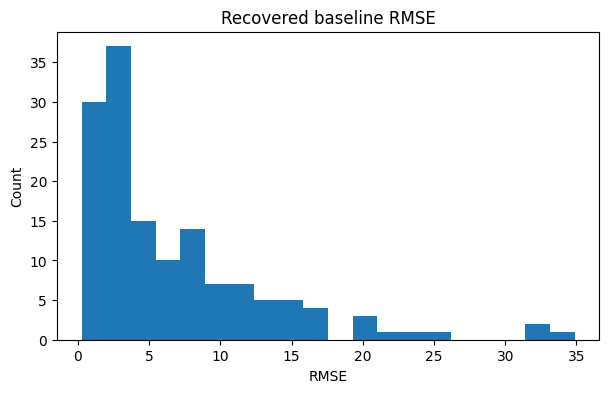

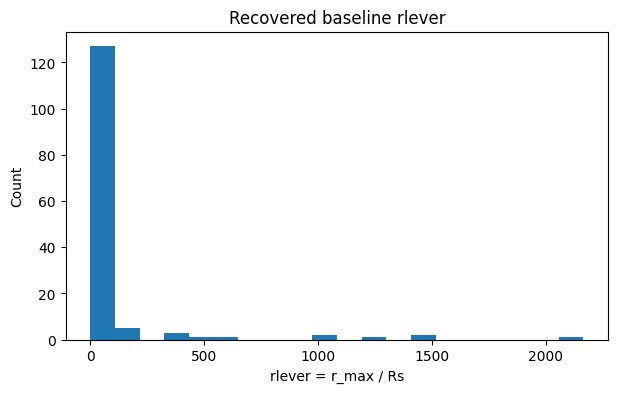

In [ ]:
# ============================================================
# INDEPENDENT SESSION-RECOVERY BASELINE REBUILD
# Raw files only. No dependency on previous cells.
# Rebuilds a fresh free-Rs baseline from rotmod files in /content.
# ============================================================

import os, re, glob, zipfile, shutil, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------------
# CONFIG
# ----------------------------
ROOT = "/content"
EXTRACT_DIR = os.path.join(ROOT, "recovered_rotmod_extract")
OUT_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")

# Fixed master-curve exponent from your earlier collapse work
NU_FIXED = 0.942

# Bounds used for recovery baseline
RS_MIN, RS_MAX = 0.05, 80.0
VINF_MIN, VINF_MAX = 5.0, 600.0

# QC gates
RLEVER_LOW = 2.0
RLEVER_HIGH = 50.0
MIN_POINTS = 8

# ----------------------------
# HELPERS
# ----------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def model_v(r, Rs, Vinf):
    r = np.asarray(r, dtype=float)
    x = np.clip(r / max(Rs, 1e-9), 0, None)
    return Vinf * (1.0 - np.exp(-(x ** NU_FIXED)))

def read_rotmod_file(path):
    # tries to recover first 3 numeric columns as r, vobs, verr
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 3:
                rows.append(vals[:3])
    if len(rows) < MIN_POINTS:
        return None
    arr = np.array(rows, dtype=float)
    df = pd.DataFrame(arr, columns=["r", "vobs", "verr"])
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df[(df["r"] > 0) & (df["vobs"] >= 0)]
    if len(df) < MIN_POINTS:
        return None
    # protect against zero / tiny errors
    med_err = np.nanmedian(df["verr"].values)
    if not np.isfinite(med_err) or med_err <= 0:
        med_err = max(1.0, 0.05 * np.nanmedian(df["vobs"].values))
    df["verr"] = np.where((df["verr"] <= 0) | ~np.isfinite(df["verr"]), med_err, df["verr"])
    return df.sort_values("r").reset_index(drop=True)

def initial_guess(df):
    r = df["r"].values
    v = df["vobs"].values
    vinf0 = float(np.nanpercentile(v, 90))
    if not np.isfinite(vinf0) or vinf0 <= 0:
        vinf0 = float(np.nanmax(v))
    half = 0.5 * vinf0
    idx = np.where(v >= half)[0]
    if len(idx) > 0:
        rs0 = float(r[idx[0]])
    else:
        rs0 = float(np.nanmedian(r))
    rs0 = float(np.clip(rs0, RS_MIN, RS_MAX))
    vinf0 = float(np.clip(vinf0, VINF_MIN, VINF_MAX))
    return rs0, vinf0

def fit_one(df):
    r = df["r"].values.astype(float)
    v = df["vobs"].values.astype(float)
    s = df["verr"].values.astype(float)

    p0 = initial_guess(df)

    try:
        popt, pcov = curve_fit(
            model_v, r, v, p0=p0, sigma=s, absolute_sigma=True,
            bounds=([RS_MIN, VINF_MIN], [RS_MAX, VINF_MAX]),
            maxfev=20000
        )
        Rs, Vinf = map(float, popt)
    except Exception:
        return None

    pred = model_v(r, Rs, Vinf)
    rmse = float(np.sqrt(np.mean((pred - v) ** 2)))
    rmax = float(np.max(r))
    rlever = float(rmax / Rs) if Rs > 0 else np.inf
    a0_eff = float((Vinf ** 2) / Rs) if Rs > 0 else np.nan

    qc_npts_ok = len(df) >= MIN_POINTS
    qc_rlever_low_ok = rlever >= RLEVER_LOW
    qc_rlever_high_ok = rlever <= RLEVER_HIGH
    qc_pass = qc_npts_ok and qc_rlever_low_ok and qc_rlever_high_ok

    if qc_pass:
        fail_reason = "pass"
    elif (not qc_rlever_low_ok) and (not qc_rlever_high_ok):
        fail_reason = "rlever_both"
    elif not qc_rlever_low_ok:
        fail_reason = "rlever_low"
    elif not qc_rlever_high_ok:
        fail_reason = "rlever_high"
    else:
        fail_reason = "other"

    return {
        "Rs_fit": Rs,
        "Vinf_fit": Vinf,
        "rmse": rmse,
        "a0_eff": a0_eff,
        "r_max": rmax,
        "rlever": rlever,
        "qc_pass": qc_pass,
        "qc_npts_ok": qc_npts_ok,
        "qc_rlever_low_ok": qc_rlever_low_ok,
        "qc_rlever_high_ok": qc_rlever_high_ok,
        "fail_reason": fail_reason,
        "n_pts": int(len(df)),
        "r_min": float(np.min(r)),
        "vobs_max": float(np.max(v)),
        "vflat_obs": float(np.nanpercentile(v, 90)),
    }

# ----------------------------
# RESET EXTRACT FOLDER
# ----------------------------
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

# ----------------------------
# FIND ZIPS + ROTMOD FILES
# ----------------------------
zip_candidates = []
for pat in ["*.zip", "*.ZIP"]:
    zip_candidates.extend(glob.glob(os.path.join(ROOT, pat)))

rotmod_zips = [p for p in zip_candidates if "rotmod" in os.path.basename(p).lower()]

print("=" * 60)
print("RAW FILE DISCOVERY")
print("=" * 60)
print(f"All zip files in /content: {len(zip_candidates)}")
print(f"Rotmod-like zip files:      {len(rotmod_zips)}")
for z in sorted(rotmod_zips)[:20]:
    print("ZIP:", os.path.basename(z))

# ----------------------------
# EXTRACT ROTMOD ZIP FILES
# ----------------------------
for z in rotmod_zips:
    subdir = os.path.join(EXTRACT_DIR, os.path.splitext(os.path.basename(z))[0])
    os.makedirs(subdir, exist_ok=True)
    try:
        with zipfile.ZipFile(z, "r") as zz:
            zz.extractall(subdir)
    except Exception as e:
        print(f"[WARN] Could not extract {os.path.basename(z)}: {e}")

# Also allow loose rotmod files already in /content
loose_rotmods = glob.glob(os.path.join(ROOT, "*rotmod*.dat"))
all_rotmod_files = glob.glob(os.path.join(EXTRACT_DIR, "**", "*rotmod*.dat"), recursive=True) + loose_rotmods
all_rotmod_files = sorted(list(set(all_rotmod_files)))

print(f"\nRecovered rotmod-like files: {len(all_rotmod_files)}")

# ----------------------------
# LOAD GALAXY DICTIONARY
# ----------------------------
galaxy_data = {}
failed_files = []

for fp in all_rotmod_files:
    gal = norm_gal(fp)
    df = read_rotmod_file(fp)
    if df is None:
        failed_files.append((fp, "parse_or_too_few_points"))
        continue
    # keep the version with the most rows if duplicates exist
    if gal not in galaxy_data or len(df) > len(galaxy_data[gal]["df"]):
        galaxy_data[gal] = {"path": fp, "df": df}

print(f"Loaded galaxies: {len(galaxy_data)}")
print(f"Failed files:    {len(failed_files)}")

# ----------------------------
# FIT FRESH BASELINE
# ----------------------------
rows = []
fit_fail = []

for i, (gal, obj) in enumerate(sorted(galaxy_data.items()), start=1):
    out = fit_one(obj["df"])
    if out is None:
        fit_fail.append((gal, obj["path"], "fit_failed"))
        continue

    row = {
        "gal": gal,
        "source_file": obj["path"],
    }
    row.update(out)
    rows.append(row)

    if i % 25 == 0 or i == len(galaxy_data):
        print(f"Progress: {i}/{len(galaxy_data)}")

base = pd.DataFrame(rows).sort_values(["qc_pass", "rmse"], ascending=[False, True]).reset_index(drop=True)

# ----------------------------
# SUMMARY
# ----------------------------
print("\n" + "=" * 60)
print("RECOVERED FREE-Rs BASELINE SUMMARY")
print("=" * 60)

print(f"Successful fits: {len(base)}")
print(f"Fit failures:    {len(fit_fail)}")

if len(base):
    qc = base[base["qc_pass"]].copy()
    print(f"QC pass:         {len(qc)}")
    print(f"QC fail:         {len(base) - len(qc)}")

    def stats_block(df, tag):
        if len(df) == 0:
            return
        print(f"\n{tag}")
        print({
            "n": int(len(df)),
            "med_rmse": float(df["rmse"].median()),
            "mean_rmse": float(df["rmse"].mean()),
            "p90_rmse": float(df["rmse"].quantile(0.90)),
            "median_rlever": float(df["rlever"].median()),
            "mean_rlever": float(df["rlever"].mean()),
        })

    stats_block(base, "ALL FITS")
    stats_block(qc, "QC ONLY")

    print("\nQC FAILURE BREAKDOWN")
    print(base["fail_reason"].value_counts(dropna=False).to_string())

    print("\nBEST 20")
    show_cols = ["gal", "rmse", "Rs_fit", "Vinf_fit", "a0_eff", "rlever", "qc_pass", "fail_reason", "n_pts", "r_max", "vobs_max", "source_file"]
    print(base[show_cols].head(20).to_string(index=False))

    print("\nWORST 20")
    print(base[show_cols].sort_values("rmse", ascending=False).head(20).to_string(index=False))

# ----------------------------
# SAVE OPTIONAL CSV
# ----------------------------
base.to_csv(OUT_CSV, index=False)

print("\n" + "=" * 60)
print("PRIMARY RESULT")
print("=" * 60)
print("The important result is printed above in the notebook.")
print("Optional CSV written to:")
print(OUT_CSV)

# ----------------------------
# SIMPLE PLOTS IN NOTEBOOK
# ----------------------------
if len(base):
    plt.figure(figsize=(7,4))
    plt.hist(base["rmse"], bins=20)
    plt.xlabel("RMSE")
    plt.ylabel("Count")
    plt.title("Recovered baseline RMSE")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(base["rlever"], bins=20)
    plt.xlabel("rlever = r_max / Rs")
    plt.ylabel("Count")
    plt.title("Recovered baseline rlever")
    plt.show()

In [ ]:
# ============================================================
# INDEPENDENT MRT MASS-TABLE RECOVERY + MERGE
# Specifically targets MassModels_Lelli2016c.mrt
# ============================================================

import os, re, math, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")
OUT_CSV = os.path.join(ROOT, "recovered_freeRs_baseline_with_mass.csv")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def as_float(x):
    try:
        return float(x)
    except:
        return np.nan

def recover_mrt_rows(path):
    """
    Recover rows from a CDS-style .mrt table by scanning for lines that begin
    with a galaxy-like token and contain many numeric fields.
    """
    with open(path, "r", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    data_rows = []
    for ln in lines:
        s = ln.strip()
        if not s:
            continue
        # skip obvious metadata / rulers
        if s.startswith(("#", "Byte-by-byte", "Note", "--------------------------------------------------------------------------------", "===")):
            continue
        if s.lower().startswith(("title:", "authors:", "table:", "file:", "bytes", "format", "units", "explanations")):
            continue

        parts = re.split(r"\s+", s)
        if len(parts) < 4:
            continue

        # first token should look galaxy-like
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        # count numeric-looking tokens
        numlike = 0
        for p in parts[1:]:
            if re.fullmatch(r"[+\-]?\d+(\.\d+)?", p) or re.fullmatch(r"[+\-]?\d+(\.\d+)?[Ee][+\-]?\d+", p):
                numlike += 1
        if numlike < 3:
            continue

        data_rows.append(parts)

    return data_rows

def build_mass_df_from_rows(rows):
    """
    Since column labels may be unavailable from raw MRT parsing, try several
    plausible mappings and choose the one that gives sensible positive masses
    and best overlap with baseline later.
    """
    if not rows:
        return {}

    maxlen = max(len(r) for r in rows)
    padded = [r + [""] * (maxlen - len(r)) for r in rows]
    raw = pd.DataFrame(padded)
    raw = raw.rename(columns={0: "gal_raw"})
    raw["gal"] = raw["gal_raw"].map(norm_gal)

    # convert every non-gal column to numeric copy
    numcols = []
    for c in raw.columns:
        if c in ["gal_raw", "gal"]:
            continue
        nc = f"c{c}"
        raw[nc] = pd.to_numeric(raw[c], errors="coerce")
        numcols.append(nc)

    # Candidate interpretations:
    # Many SPARC/CDS tables contain log stellar mass, log gas mass, log baryonic mass
    # somewhere toward the right. We'll test multiple hypotheses.
    candidates = {}

    # Single-column candidates interpreted as log Mb or Mb
    for c in numcols:
        x = raw[c]
        # as log mass
        mb1 = 10 ** x
        good1 = mb1.replace([np.inf, -np.inf], np.nan)
        good1 = good1[(good1 > 1e1) & (good1 < 1e14)]
        if len(good1) >= 20:
            df1 = pd.DataFrame({"gal": raw["gal"], "gal_raw": raw["gal_raw"], "Mb_proxy": mb1})
            df1 = df1.replace([np.inf, -np.inf], np.nan).dropna()
            df1 = df1[(df1["Mb_proxy"] > 1e1) & (df1["Mb_proxy"] < 1e14)]
            df1 = df1.drop_duplicates("gal")
            candidates[f"{c}_as_logMb"] = df1

        # as linear mass
        good2 = x[(x > 1e1) & (x < 1e14)]
        if len(good2) >= 20:
            df2 = pd.DataFrame({"gal": raw["gal"], "gal_raw": raw["gal_raw"], "Mb_proxy": x})
            df2 = df2.replace([np.inf, -np.inf], np.nan).dropna()
            df2 = df2[(df2["Mb_proxy"] > 1e1) & (df2["Mb_proxy"] < 1e14)]
            df2 = df2.drop_duplicates("gal")
            candidates[f"{c}_as_linearMb"] = df2

    # Two-column candidates interpreted as logMstar + logMgas
    for i, c1 in enumerate(numcols):
        for c2 in numcols[i+1:]:
            mb = (10 ** raw[c1]) + (10 ** raw[c2])
            good = mb.replace([np.inf, -np.inf], np.nan)
            good = good[(good > 1e1) & (good < 1e14)]
            if len(good) >= 20:
                df = pd.DataFrame({"gal": raw["gal"], "gal_raw": raw["gal_raw"], "Mb_proxy": mb})
                df = df.replace([np.inf, -np.inf], np.nan).dropna()
                df = df[(df["Mb_proxy"] > 1e1) & (df["Mb_proxy"] < 1e14)]
                df = df.drop_duplicates("gal")
                key = f"{c1}+{c2}_as_logMstar_plus_logMgas"
                candidates[key] = df

    return candidates

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing {BASELINE_CSV}. Run the baseline recovery cell first.")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing {MRT_PATH}.")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

print("=" * 60)
print("MRT MASS-TABLE RECOVERY")
print("=" * 60)
print(f"Loaded baseline rows: {len(base)}")
print(f"Baseline file:        {BASELINE_CSV}")
print(f"MRT file:             {MRT_PATH}")

# ------------------------------------------------------------
# RECOVER RAW ROWS
# ------------------------------------------------------------
rows = recover_mrt_rows(MRT_PATH)
print(f"\nRecovered raw candidate data rows from MRT: {len(rows)}")

if len(rows) == 0:
    raise ValueError("No data-like rows recovered from MRT file.")

print("\nFirst 10 recovered raw rows:")
for r in rows[:10]:
    print(r)

# ------------------------------------------------------------
# BUILD CANDIDATE MASS TABLES
# ------------------------------------------------------------
cand = build_mass_df_from_rows(rows)
print(f"\nCandidate mass interpretations built: {len(cand)}")

if len(cand) == 0:
    raise ValueError("Could not construct any plausible mass-table interpretation from MRT rows.")

# Score candidates by overlap with baseline and sensible mass range
scored = []
for name, df in cand.items():
    overlap = len(set(df["gal"]) & set(base["gal"]))
    med = float(df["Mb_proxy"].median()) if len(df) else np.nan
    score = overlap
    # prefer medians in astrophysically sensible baryonic range
    if np.isfinite(med) and (1e6 <= med <= 1e11):
        score += 20
    scored.append((name, score, overlap, len(df), med))

score_df = pd.DataFrame(scored, columns=["candidate", "score", "overlap", "n_rows", "median_Mb"])
score_df = score_df.sort_values(["score", "overlap", "n_rows"], ascending=[False, False, False]).reset_index(drop=True)

print("\nTop candidate interpretations:")
print(score_df.head(20).to_string(index=False))

best_name = score_df.iloc[0]["candidate"]
best_mass = cand[best_name].copy()

print("\n" + "=" * 60)
print("SELECTED INTERPRETATION")
print("=" * 60)
print(f"Best candidate: {best_name}")
print(f"Rows in candidate: {len(best_mass)}")
print(f"Overlap with baseline: {len(set(best_mass['gal']) & set(base['gal']))}")

# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------
merged = base.merge(best_mass[["gal", "Mb_proxy"]], on="gal", how="left")
matched = int(merged["Mb_proxy"].notna().sum())
unmatched = int(len(merged) - matched)

print("\n" + "=" * 60)
print("MERGE SUMMARY")
print("=" * 60)
print(f"Baseline rows:  {len(merged)}")
print(f"Matched masses: {matched}")
print(f"Unmatched:      {unmatched}")

if matched > 0:
    print("\nMatched sample:")
    cols = [c for c in ["gal", "Mb_proxy", "Rs_fit", "Vinf_fit", "rmse", "a0_eff", "rlever", "qc_pass"] if c in merged.columns]
    print(merged[merged["Mb_proxy"].notna()][cols].head(20).to_string(index=False))

if unmatched > 0:
    print("\nUnmatched sample:")
    cols = [c for c in ["gal", "Rs_fit", "Vinf_fit", "rmse", "rlever"] if c in merged.columns]
    print(merged[merged["Mb_proxy"].isna()][cols].head(20).to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
merged.to_csv(OUT_CSV, index=False)

print("\n" + "=" * 60)
print("PRIMARY RESULT")
print("=" * 60)
print("Important result is printed above.")
print("Merged baseline written to:")
print(OUT_CSV)

MRT MASS-TABLE RECOVERY
Loaded baseline rows: 143
Baseline file:        /content/recovered_freeRs_baseline.csv
MRT file:             /content/MassModels_Lelli2016c.mrt

Recovered raw candidate data rows from MRT: 3391

First 10 recovered raw rows:
['CamB', '3.36', '0.16', '1.99', '1.50', '1.86', '3.75', '0.00', '30.32', '0.00']
['CamB', '3.36', '0.41', '4.84', '1.50', '4.24', '9.47', '0.00', '23.77', '0.00']
['CamB', '3.36', '0.57', '6.79', '1.50', '5.61', '11.76', '0.00', '15.87', '0.00']
['CamB', '3.36', '0.73', '8.87', '1.50', '6.77', '13.72', '0.00', '12.40', '0.00']
['CamB', '3.36', '0.90', '10.90', '1.50', '7.77', '14.80', '0.00', '9.63', '0.00']
['CamB', '3.36', '1.06', '12.90', '1.50', '8.44', '15.24', '0.00', '5.86', '0.00']
['CamB', '3.36', '1.22', '14.70', '1.50', '8.64', '15.11', '0.00', '5.19', '0.00']
['CamB', '3.36', '1.47', '16.80', '1.50', '8.08', '15.90', '0.00', '3.02', '0.00']
['CamB', '3.36', '1.79', '20.10', '1.50', '6.91', '14.91', '0.00', '0.88', '0.00']
['D512-

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

RAW MRT PROFILE TABLE
Recovered profile rows: 3391
Unique galaxies in MRT: 175

First 5 rows:
gal_raw   c1   c2    c3  c4   c5    c6  c7    c8  c9  gal
   CamB 3.36 0.16  1.99 1.5 1.86  3.75 0.0 30.32 0.0 CAMB
   CamB 3.36 0.41  4.84 1.5 4.24  9.47 0.0 23.77 0.0 CAMB
   CamB 3.36 0.57  6.79 1.5 5.61 11.76 0.0 15.87 0.0 CAMB
   CamB 3.36 0.73  8.87 1.5 6.77 13.72 0.0 12.40 0.0 CAMB
   CamB 3.36 0.90 10.90 1.5 7.77 14.80 0.0  9.63 0.0 CAMB

RADIUS COLUMN DETECTION
col    score  median_frac_monotonic_up  median_dynamic_range
 c8 2.533200                  0.000000                126.66
 c3 1.937143                  0.857143                 54.00
 c5 1.480933                  0.833333                 32.38
 c2 1.209200                  1.000000                 10.46
 c6 1.110044                  0.444444                 33.28
 c1 1.000000                  1.000000                  0.00

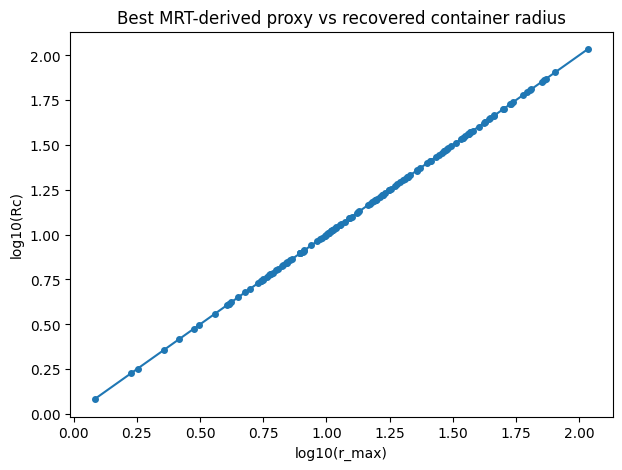

In [ ]:
# ============================================================
# INDEPENDENT MRT PROFILE -> GALAXY PROXY SCAN
# Purpose:
#   Treat MassModels_Lelli2016c.mrt as a radial profile table, not a galaxy summary.
#   Build one-row-per-galaxy structural proxies from radial columns.
#   Test which proxy best predicts recovered baseline structure.
#
# Inputs required in /content:
#   - recovered_freeRs_baseline.csv
#   - MassModels_Lelli2016c.mrt
#
# Prints everything directly in notebook.
# ============================================================

import os, re, math, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def fit_line(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 5:
        return None
    p = np.polyfit(x, y, 1)
    yhat = p[0]*x + p[1]
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot
    mae = np.mean(np.abs(y - yhat))
    medae = np.median(np.abs(y - yhat))
    p90 = np.quantile(np.abs(y - yhat), 0.90)
    return {
        "slope": float(p[0]),
        "intercept": float(p[1]),
        "r2": float(r2),
        "mae": float(mae),
        "medae": float(medae),
        "p90ae": float(p90),
        "n": int(len(x)),
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "rmse", "a0_eff", "rlever", "r_max", "qc_pass"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["Rc_fit"] = base["Rs_fit"] * base["rlever"]   # should be ~ r_max
base["logRc"] = safe_log10(base["Rc_fit"])
base["logRs"] = safe_log10(base["Rs_fit"])
base["loga0"] = safe_log10(base["a0_eff"])

print("="*70)
print("LOAD BASELINE")
print("="*70)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# PARSE MRT RAW PROFILE TABLE
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric profile rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan]*(maxlen - len(r)) for r in rows]

cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

print("\n" + "="*70)
print("RAW MRT PROFILE TABLE")
print("="*70)
print(f"Recovered profile rows: {len(prof)}")
print(f"Unique galaxies in MRT: {prof['gal'].nunique()}")
print("\nFirst 5 rows:")
print(prof.head().to_string(index=False))

# ------------------------------------------------------------
# IDENTIFY A RADIUS COLUMN
# Heuristic: choose the numeric column that is positive and mostly increasing
# within galaxies, with broad dynamic range.
# ------------------------------------------------------------
numcols = [c for c in prof.columns if c.startswith("c")]
radius_scores = []

for c in numcols:
    x = prof[c].values
    if np.nanmedian(x) <= 0:
        continue
    grp_scores = []
    for _, g in prof.groupby("gal"):
        v = g[c].dropna().values
        if len(v) < 4:
            continue
        frac_up = np.mean(np.diff(v) >= 0)
        dyn = np.nanmax(v) - np.nanmin(v)
        if np.isfinite(frac_up) and np.isfinite(dyn):
            grp_scores.append((frac_up, dyn))
    if len(grp_scores) < 20:
        continue
    frac_up_med = np.median([a for a,b in grp_scores])
    dyn_med = np.median([b for a,b in grp_scores])
    score = frac_up_med + 0.02*dyn_med
    radius_scores.append((c, score, frac_up_med, dyn_med))

radius_df = pd.DataFrame(radius_scores, columns=["col", "score", "median_frac_monotonic_up", "median_dynamic_range"])
radius_df = radius_df.sort_values("score", ascending=False).reset_index(drop=True)

if len(radius_df) == 0:
    raise ValueError("Could not identify a plausible radius column.")

rcol = radius_df.iloc[0]["col"]

print("\n" + "="*70)
print("RADIUS COLUMN DETECTION")
print("="*70)
print(radius_df.head(10).to_string(index=False))
print(f"\nSelected radius column: {rcol}")

# ------------------------------------------------------------
# COLLAPSE PROFILE TABLE TO ONE ROW PER GALAXY
# Build candidate proxies from:
#   - last radius
#   - max radius
#   - sums/integrals of columns
#   - radius-weighted squares of candidate component columns
# ------------------------------------------------------------
gal_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)
    row = {
        "gal": gal,
        "n_prof": len(g),
        "r_last": float(g[rcol].dropna().iloc[-1]) if g[rcol].notna().any() else np.nan,
        "r_max_prof": float(g[rcol].max()) if g[rcol].notna().any() else np.nan,
    }
    for c in numcols:
        arr = g[c].values.astype(float)
        r = g[rcol].values.astype(float)

        good = np.isfinite(arr)
        if np.any(good):
            row[f"{c}_last"] = float(arr[good][-1])
            row[f"{c}_max"] = float(np.nanmax(arr))
            row[f"{c}_mean"] = float(np.nanmean(arr))
        else:
            row[f"{c}_last"] = np.nan
            row[f"{c}_max"] = np.nan
            row[f"{c}_mean"] = np.nan

        good2 = np.isfinite(arr) & np.isfinite(r) & (r > 0)
        if np.sum(good2) >= 2:
            rr = r[good2]
            aa = arr[good2]
            row[f"{c}_trapz"] = float(np.trapz(aa, rr))
            row[f"{c}_trapz_sq"] = float(np.trapz(aa**2, rr))
            row[f"{c}_rmax_sq"] = float(np.nanmax(rr) * (aa[-1]**2))
        else:
            row[f"{c}_trapz"] = np.nan
            row[f"{c}_trapz_sq"] = np.nan
            row[f"{c}_rmax_sq"] = np.nan

    gal_rows.append(row)

gdf = pd.DataFrame(gal_rows)

merged = base.merge(gdf, on="gal", how="inner")
print("\n" + "="*70)
print("MERGED BASELINE + PROFILE PROXIES")
print("="*70)
print(f"Merged rows: {len(merged)}")

# ------------------------------------------------------------
# SCAN CANDIDATE PROXIES AGAINST logRc
# We want a one-parameter structural proxy first.
# ------------------------------------------------------------
proxy_cols = []
for c in merged.columns:
    if c.endswith(("_last", "_max", "_mean", "_trapz", "_trapz_sq", "_rmax_sq")) or c in ["r_last", "r_max_prof"]:
        if merged[c].notna().sum() >= 30:
            proxy_cols.append(c)

results = []
for c in proxy_cols:
    x = safe_log10(merged[c].values)
    y = merged["logRc"].values
    fit_all = fit_line(x, y)
    if fit_all is None:
        continue

    q = merged["qc_pass"].values.astype(bool)
    fit_qc = fit_line(x[q], y[q])

    if fit_qc is None:
        continue

    # score emphasizes QC residual quality and fit strength
    score = fit_qc["medae"] + 0.5*fit_qc["mae"] + 0.2*(1 - fit_qc["r2"])

    results.append({
        "proxy": c,
        "score": score,
        "all_n": fit_all["n"],
        "all_r2": fit_all["r2"],
        "all_medae": fit_all["medae"],
        "all_mae": fit_all["mae"],
        "all_p90ae": fit_all["p90ae"],
        "qc_n": fit_qc["n"],
        "qc_r2": fit_qc["r2"],
        "qc_medae": fit_qc["medae"],
        "qc_mae": fit_qc["mae"],
        "qc_p90ae": fit_qc["p90ae"],
        "qc_slope": fit_qc["slope"],
        "qc_intercept": fit_qc["intercept"],
    })

scan = pd.DataFrame(results).sort_values(
    ["score", "qc_medae", "qc_mae", "qc_p90ae"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "="*70)
print("BEST PROFILE-DERIVED GALAXY PROXIES FOR Rc")
print("="*70)
print(scan.head(25).to_string(index=False))

best = scan.iloc[0].to_dict()
best_proxy = best["proxy"]

print("\n" + "="*70)
print("BEST PROXY")
print("="*70)
print(best)

# ------------------------------------------------------------
# SHOW BEST-PROXY LAW
# logRc = a + b log(proxy)
# ------------------------------------------------------------
x = safe_log10(merged[best_proxy].values)
y = merged["logRc"].values
fit = fit_line(x, y)

print("\nBest empirical law:")
print(f"log10(Rc) = {fit['intercept']:.12f} + {fit['slope']:.12f} * log10({best_proxy})")
print(f"Rc = {10**fit['intercept']:.12e} * ({best_proxy})^{fit['slope']:.12f}")

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
m = np.isfinite(x) & np.isfinite(y)
plt.scatter(x[m], y[m], s=16)
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
yy = fit["intercept"] + fit["slope"]*xx
plt.plot(xx, yy)
plt.xlabel(f"log10({best_proxy})")
plt.ylabel("log10(Rc)")
plt.title("Best MRT-derived proxy vs recovered container radius")
plt.show()

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius column: c2

Merged rows with baseline: 143

BEST MRT PROXIES FOR Rs_fit
      proxy    score   all_r2  all_medae  all_mae  all_p90ae    qc_r2  qc_medae   qc_mae  qc_p90ae  qc_slope  qc_intercept  qc_n
c7_r2weight 0.425412 0.172152   0.456990 0.479978   0.886588 0.415252  0.201586 0.213753  0.298133  0.334042     -1.724774    11
c1_trapz_sq 0.429933 0.039755   0.313307 0.408548   0.905773 0.239814  0.172997 0.209798  0.403939  0.135832     -0.219727   103
c1_r2weight 0.432187 0.102897   0.289736 0.397956   0.891260 0.227600  0.169691 0.216031  0.418199  0.118524     -0.236652   103
   c1_trapz 0.433915 0.063379   0.316486 0.405318   0.898076 0.243646  0.177673 0.209943  0.404202  0.223183     -0.259589   103
 c1_rweight 0.433918 0.089306   0.308640 0.400912   0.920534 0.237461  0.174835 0.213150

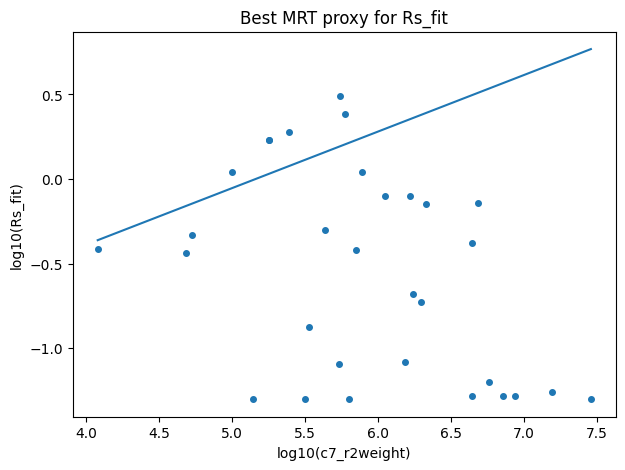


BEST MRT PROXIES FOR Vinf_fit
      proxy    score   all_r2  all_medae  all_mae  all_p90ae    qc_r2  qc_medae   qc_mae  qc_p90ae  qc_slope  qc_intercept  qc_n
   vobs_max 0.020322 0.782820   0.038996 0.056159   0.087862 0.990709  0.010703 0.015522  0.033599  0.962176      0.074084   103
     c3_max 0.020322 0.782820   0.038996 0.056159   0.087862 0.990709  0.010703 0.015522  0.033599  0.962176      0.074084   103
    c3_last 0.025498 0.775890   0.043654 0.059936   0.090585 0.987178  0.013452 0.018963  0.042623  0.994165      0.025035   103
    c3_mean 0.059243 0.721008   0.047323 0.071693   0.137891 0.949491  0.030353 0.037576  0.080690  0.852658      0.374117   103
c3_trapz_sq 0.093670 0.687752   0.067473 0.084904   0.145683 0.902195  0.047413 0.053391  0.121545  0.276527      0.638827   103
 c8_rweight 0.096331 0.793725   0.046123 0.066793   0.130687 0.889084  0.046865 0.054566  0.103644  0.204246      1.455013   103
c8_r2weight 0.100439 0.771798   0.048448 0.070668   0.127751 0.864

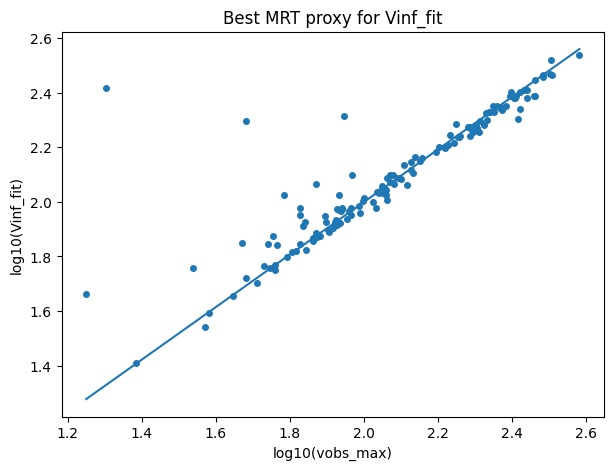


BEST MRT PROXIES FOR a0_eff
      proxy    score   all_r2  all_medae  all_mae  all_p90ae    qc_r2  qc_medae   qc_mae  qc_p90ae  qc_slope  qc_intercept  qc_n
    c3_mean 0.309098 0.696396   0.268149 0.341125   0.757754 0.732899  0.155292 0.200772  0.404416  1.722329      0.465011   103
c8_trapz_sq 0.333352 0.592400   0.245387 0.367453   0.844804 0.714775  0.169894 0.212827  0.418285  0.297665      2.516409   103
     c6_max 0.354041 0.610976   0.256594 0.373798   0.800364 0.674379  0.176589 0.224655  0.476964  1.029669      1.956735   103
   vobs_max 0.357090 0.674984   0.289300 0.358687   0.821688 0.660925  0.176505 0.225540  0.445843  1.806850      0.139215   103
     c3_max 0.357090 0.674984   0.289300 0.358687   0.821688 0.660925  0.176505 0.225540  0.445843  1.806850      0.139215   103
    c8_mean 0.361261 0.516446   0.251096 0.400223   0.834952 0.690985  0.187477 0.223962  0.434326  0.632839      2.865007   103
     c8_max 0.369909 0.518446   0.284059 0.392129   0.856829 0.68314

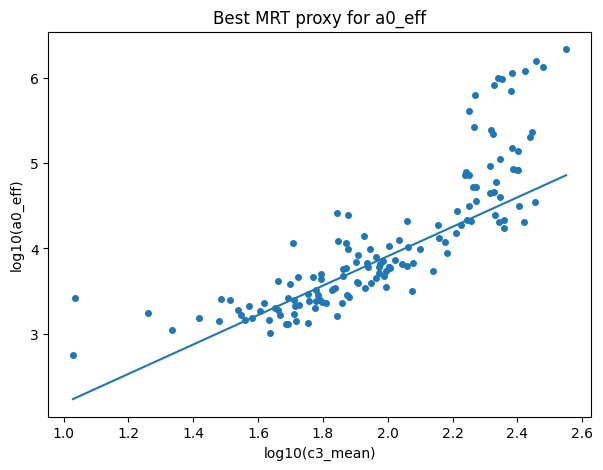

In [ ]:
# ============================================================
# INDEPENDENT MRT PROFILE -> STRUCTURAL TARGET SCAN
# Forces c2 as radius column.
# Scans integrated MRT profile proxies against:
#   Rs_fit, Vinf_fit, a0_eff
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def fit_line(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 8:
        return None
    p = np.polyfit(x, y, 1)
    yhat = p[0]*x + p[1]
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot
    ae = np.abs(y - yhat)
    return {
        "n": int(len(x)),
        "slope": float(p[0]),
        "intercept": float(p[1]),
        "r2": float(r2),
        "medae": float(np.median(ae)),
        "mae": float(np.mean(ae)),
        "p90ae": float(np.quantile(ae, 0.90)),
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "qc_pass"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Missing required baseline columns: {missing}")

base["logRs"] = safe_log10(base["Rs_fit"])
base["logVinf"] = safe_log10(base["Vinf_fit"])
base["loga0"] = safe_log10(base["a0_eff"])

print("=" * 70)
print("LOAD BASELINE")
print("=" * 70)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan]*(maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

print("\n" + "=" * 70)
print("LOAD MRT PROFILE TABLE")
print("=" * 70)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print("Forced radius column: c2")

rcol = "c2"
numcols = [c for c in prof.columns if c.startswith("c") and c != rcol]

# ------------------------------------------------------------
# BUILD PER-GALAXY PROXIES
# ------------------------------------------------------------
gal_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)
    r = g[rcol].values.astype(float)

    row = {
        "gal": gal,
        "n_prof": len(g),
        "r_last_prof": float(np.nanmax(r)) if np.isfinite(r).any() else np.nan,
    }

    for c in numcols:
        a = g[c].values.astype(float)
        good = np.isfinite(r) & np.isfinite(a) & (r > 0)

        if np.sum(good) >= 2:
            rr = r[good]
            aa = a[good]

            row[f"{c}_last"] = float(aa[-1])
            row[f"{c}_max"] = float(np.nanmax(aa))
            row[f"{c}_mean"] = float(np.nanmean(aa))
            row[f"{c}_trapz"] = float(np.trapz(aa, rr))
            row[f"{c}_trapz_sq"] = float(np.trapz(aa**2, rr))
            row[f"{c}_rweight"] = float(np.trapz(rr * aa, rr))
            row[f"{c}_r2weight"] = float(np.trapz((rr**2) * aa, rr))
        else:
            row[f"{c}_last"] = np.nan
            row[f"{c}_max"] = np.nan
            row[f"{c}_mean"] = np.nan
            row[f"{c}_trapz"] = np.nan
            row[f"{c}_trapz_sq"] = np.nan
            row[f"{c}_rweight"] = np.nan
            row[f"{c}_r2weight"] = np.nan

    gal_rows.append(row)

gdf = pd.DataFrame(gal_rows)

merged = base.merge(gdf, on="gal", how="inner")
print(f"\nMerged rows with baseline: {len(merged)}")

# ------------------------------------------------------------
# SCAN PROXIES AGAINST STRUCTURAL TARGETS
# ------------------------------------------------------------
proxy_cols = [c for c in merged.columns if any(c.endswith(suf) for suf in [
    "_last", "_max", "_mean", "_trapz", "_trapz_sq", "_rweight", "_r2weight"
])]

targets = [
    ("logRs", "Rs_fit"),
    ("logVinf", "Vinf_fit"),
    ("loga0", "a0_eff"),
]

for target_col, target_name in targets:
    rows_out = []
    y_all = merged[target_col].values
    y_qc = merged.loc[merged["qc_pass"], target_col].values

    for pcol in proxy_cols:
        x_all = safe_log10(merged[pcol].values)
        fit_all = fit_line(x_all, y_all)
        if fit_all is None:
            continue

        qmask = merged["qc_pass"].values.astype(bool)
        x_qc = safe_log10(merged.loc[qmask, pcol].values)
        fit_qc = fit_line(x_qc, y_qc)
        if fit_qc is None:
            continue

        score = fit_qc["medae"] + 0.5 * fit_qc["mae"] + 0.2 * (1 - fit_qc["r2"])
        rows_out.append({
            "proxy": pcol,
            "score": score,
            "all_r2": fit_all["r2"],
            "all_medae": fit_all["medae"],
            "all_mae": fit_all["mae"],
            "all_p90ae": fit_all["p90ae"],
            "qc_r2": fit_qc["r2"],
            "qc_medae": fit_qc["medae"],
            "qc_mae": fit_qc["mae"],
            "qc_p90ae": fit_qc["p90ae"],
            "qc_slope": fit_qc["slope"],
            "qc_intercept": fit_qc["intercept"],
            "qc_n": fit_qc["n"],
        })

    scan = pd.DataFrame(rows_out).sort_values(
        ["score", "qc_medae", "qc_mae", "qc_p90ae"],
        ascending=[True, True, True, True]
    ).reset_index(drop=True)

    print("\n" + "=" * 70)
    print(f"BEST MRT PROXIES FOR {target_name}")
    print("=" * 70)
    print(scan.head(20).to_string(index=False))

    best = scan.iloc[0].to_dict()
    print("\nBEST LAW")
    print(best)
    print(f"\nlog10({target_name}) = {best['qc_intercept']:.12f} + {best['qc_slope']:.12f} * log10({best['proxy']})")

    # one plot for the best proxy
    best_proxy = best["proxy"]
    x = safe_log10(merged[best_proxy].values)
    y = merged[target_col].values
    m = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(7,5))
    plt.scatter(x[m], y[m], s=16)
    xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
    yy = best["qc_intercept"] + best["qc_slope"] * xx
    plt.plot(xx, yy)
    plt.xlabel(f"log10({best_proxy})")
    plt.ylabel(f"log10({target_name})")
    plt.title(f"Best MRT proxy for {target_name}")
    plt.show()

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Profile cols: ['c1', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']

BUILT GALAXY DESCRIPTORS
Descriptor rows: 175
Descriptor columns: 276
Merged rows with baseline: 143

BEST CUMULATIVE-RADIUS / SHAPE DESCRIPTORS FOR Rs_fit
         descriptor    score  all_n   all_r2  all_medae  all_mae  all_p90ae  qc_n    qc_r2  qc_medae   qc_mae  qc_p90ae  qc_slope  qc_intercept
           c3_rpeak 0.318668    143 0.157799   0.234610 0.346123   0.770496   103 0.479503  0.131224 0.166689  0.344981  0.755791     -0.481176
        c3_sq_rpeak 0.318668    143 0.157799   0.234610 0.346123   0.770496   103 0.479503  0.131224 0.166689  0.344981  0.755791     -0.481176
          c3_sq_r10 0.366421    143 0.007980   0.305087 0.412558   0.900651   103 0.445201  0.162584 0.185756  0.379465  0.780584     -0.154114

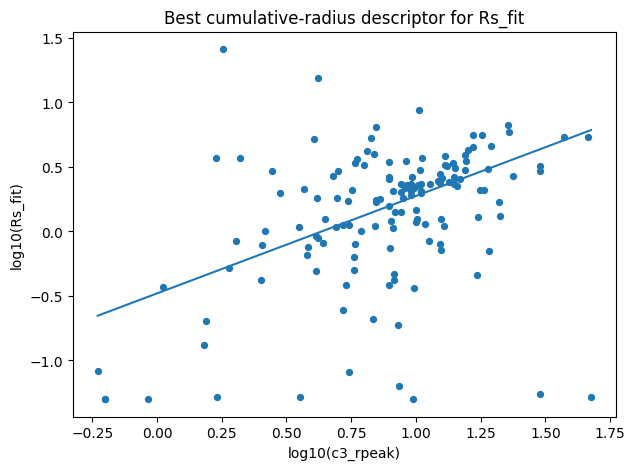


Top 10 descriptor names:
 - c3_rpeak
 - c3_sq_rpeak
 - c3_sq_r10
 - c8_r80
 - c6_rpeak
 - c6_sq_rpeak
 - c8_r90
 - c3_sq_r20
 - c3_r10
 - c6_sq_r20


In [ ]:
# ============================================================
# INDEPENDENT MRT CUMULATIVE-RADIUS DESCRIPTOR SCAN FOR Rs_fit
#
# What this does:
#   1) Loads /content/recovered_freeRs_baseline.csv
#   2) Loads /content/MassModels_Lelli2016c.mrt
#   3) Forces c2 as radius column
#   4) Builds per-galaxy cumulative-radius / concentration / peak descriptors
#      from each MRT profile column c1,c3,...,c9
#   5) Scans those descriptors directly against Rs_fit
#   6) Prints top results in the notebook
#
# No dependency on previous cells.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def fit_line(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 8:
        return None
    p = np.polyfit(x, y, 1)
    yhat = p[0] * x + p[1]
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res / ss_tot
    ae = np.abs(y - yhat)
    return {
        "n": int(len(x)),
        "slope": float(p[0]),
        "intercept": float(p[1]),
        "r2": float(r2),
        "medae": float(np.median(ae)),
        "mae": float(np.mean(ae)),
        "p90ae": float(np.quantile(ae, 0.90)),
    }

def cumulative_radius(r, w, frac):
    """
    Radius where cumulative integral of positive weights reaches given fraction.
    Uses trapezoidal cumulative integral.
    """
    r = np.asarray(r, float)
    w = np.asarray(w, float)

    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = w[order]

    # Require nonnegative cumulative weights for meaningful fraction radii
    w = np.clip(w, 0, None)
    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if not np.isfinite(c0) or not np.isfinite(c1) or c1 <= c0:
        return float(r[j])
    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def robust_slope(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan
    # simple linear slope
    try:
        p = np.polyfit(x, y, 1)
        return float(p[0])
    except:
        return np.nan

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing {BASELINE_CSV}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "r_max", "qc_pass"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Missing required baseline columns: {missing}")

base["logRs"] = safe_log10(base["Rs_fit"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT PROFILE TABLE
# ------------------------------------------------------------
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing {MRT_PATH}")

rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue
        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
if rcol not in prof.columns:
    raise ValueError("Forced radius column c2 is missing from MRT parse.")

numcols = [c for c in prof.columns if c.startswith("c") and c != rcol]

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print("Profile cols:", numcols)

# ------------------------------------------------------------
# BUILD CUMULATIVE-RADIUS / SHAPE DESCRIPTORS
# ------------------------------------------------------------
gal_rows = []

for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)
    r = g[rcol].values.astype(float)
    mr = np.isfinite(r) & (r > 0)
    if np.sum(mr) < 3:
        continue

    r_good = r[mr]
    row = {
        "gal": gal,
        "n_prof": int(np.sum(mr)),
        "r_last_prof": float(np.max(r_good)),
        "r_min_prof": float(np.min(r_good)),
    }

    for c in numcols:
        a = g[c].values.astype(float)
        m = np.isfinite(r) & np.isfinite(a) & (r > 0)
        rr = r[m]
        aa = a[m]
        if len(rr) < 3:
            continue

        # sort by radius
        order = np.argsort(rr)
        rr = rr[order]
        aa = aa[order]

        # positive versions for cumulative descriptors
        apos = np.clip(aa, 0, None)
        a2 = aa**2
        a2pos = np.clip(a2, 0, None)

        # fraction radii from raw positive amplitude
        for frac in [0.10, 0.20, 0.50, 0.80, 0.90]:
            row[f"{c}_r{int(frac*100):02d}"] = cumulative_radius(rr, apos, frac)

        # fraction radii from squared amplitude
        for frac in [0.10, 0.20, 0.50, 0.80, 0.90]:
            row[f"{c}_sq_r{int(frac*100):02d}"] = cumulative_radius(rr, a2pos, frac)

        # peak locations
        if np.any(np.isfinite(aa)):
            try:
                row[f"{c}_rpeak"] = float(rr[np.nanargmax(aa)])
                row[f"{c}_peak"] = float(np.nanmax(aa))
            except:
                row[f"{c}_rpeak"] = np.nan
                row[f"{c}_peak"] = np.nan

        if np.any(np.isfinite(a2)):
            try:
                row[f"{c}_sq_rpeak"] = float(rr[np.nanargmax(a2)])
            except:
                row[f"{c}_sq_rpeak"] = np.nan

        # normalized radii
        rlast = np.max(rr)
        for key in [
            f"{c}_r10", f"{c}_r20", f"{c}_r50", f"{c}_r80", f"{c}_r90",
            f"{c}_sq_r10", f"{c}_sq_r20", f"{c}_sq_r50", f"{c}_sq_r80", f"{c}_sq_r90",
            f"{c}_rpeak", f"{c}_sq_rpeak"
        ]:
            val = row.get(key, np.nan)
            row[f"{key}_over_rmax"] = float(val / rlast) if np.isfinite(val) and rlast > 0 else np.nan

        # concentration ratios
        def ratio(a_name, b_name, out_name):
            a_val = row.get(a_name, np.nan)
            b_val = row.get(b_name, np.nan)
            row[out_name] = float(a_val / b_val) if np.isfinite(a_val) and np.isfinite(b_val) and b_val > 0 else np.nan

        ratio(f"{c}_r50", f"{c}_r20", f"{c}_conc50_20")
        ratio(f"{c}_r80", f"{c}_r20", f"{c}_conc80_20")
        ratio(f"{c}_r90", f"{c}_r50", f"{c}_conc90_50")
        ratio(f"{c}_sq_r50", f"{c}_sq_r20", f"{c}_sq_conc50_20")
        ratio(f"{c}_sq_r80", f"{c}_sq_r20", f"{c}_sq_conc80_20")
        ratio(f"{c}_sq_r90", f"{c}_sq_r50", f"{c}_sq_conc90_50")

        # inner / outer slopes in log-log on positive amplitude
        pos = (rr > 0) & (apos > 0)
        if np.sum(pos) >= 6:
            xr = np.log10(rr[pos])
            ya = np.log10(apos[pos])

            n = len(xr)
            k = max(3, n // 3)
            row[f"{c}_inner_slope"] = robust_slope(xr[:k], ya[:k])
            row[f"{c}_outer_slope"] = robust_slope(xr[-k:], ya[-k:])
            inner = row[f"{c}_inner_slope"]
            outer = row[f"{c}_outer_slope"]
            row[f"{c}_slope_delta"] = float(inner - outer) if np.isfinite(inner) and np.isfinite(outer) else np.nan
        else:
            row[f"{c}_inner_slope"] = np.nan
            row[f"{c}_outer_slope"] = np.nan
            row[f"{c}_slope_delta"] = np.nan

    gal_rows.append(row)

desc = pd.DataFrame(gal_rows)

print("\n" + "=" * 72)
print("BUILT GALAXY DESCRIPTORS")
print("=" * 72)
print(f"Descriptor rows: {len(desc)}")
print(f"Descriptor columns: {len(desc.columns)}")

merged = base.merge(desc, on="gal", how="inner")
print(f"Merged rows with baseline: {len(merged)}")

# ------------------------------------------------------------
# SCAN DESCRIPTORS AGAINST Rs_fit
# ------------------------------------------------------------
exclude = {
    "gal", "source_file", "rmse", "Vinf_fit", "a0_eff", "rlever", "r_max",
    "qc_pass", "qc_npts_ok", "qc_rlever_low_ok", "qc_rlever_high_ok",
    "fail_reason", "n_pts", "r_min", "vobs_max", "vflat_obs", "logRs",
    "n_prof"
}
descriptor_cols = [c for c in merged.columns if c not in exclude and c != "Rs_fit"]

results = []
qmask = merged["qc_pass"].values.astype(bool)

for dcol in descriptor_cols:
    x_all = safe_log10(merged[dcol].values)
    y_all = merged["logRs"].values
    fit_all = fit_line(x_all, y_all)
    if fit_all is None:
        continue

    x_qc = safe_log10(merged.loc[qmask, dcol].values)
    y_qc = merged.loc[qmask, "logRs"].values
    fit_qc = fit_line(x_qc, y_qc)
    if fit_qc is None:
        continue

    # Penalize tiny sample size a bit
    n_penalty = 0.0 if fit_qc["n"] >= 40 else 0.005 * (40 - fit_qc["n"])
    score = fit_qc["medae"] + 0.5 * fit_qc["mae"] + 0.2 * (1 - fit_qc["r2"]) + n_penalty

    results.append({
        "descriptor": dcol,
        "score": score,
        "all_n": fit_all["n"],
        "all_r2": fit_all["r2"],
        "all_medae": fit_all["medae"],
        "all_mae": fit_all["mae"],
        "all_p90ae": fit_all["p90ae"],
        "qc_n": fit_qc["n"],
        "qc_r2": fit_qc["r2"],
        "qc_medae": fit_qc["medae"],
        "qc_mae": fit_qc["mae"],
        "qc_p90ae": fit_qc["p90ae"],
        "qc_slope": fit_qc["slope"],
        "qc_intercept": fit_qc["intercept"],
    })

scan = pd.DataFrame(results).sort_values(
    ["score", "qc_medae", "qc_mae", "qc_p90ae"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("BEST CUMULATIVE-RADIUS / SHAPE DESCRIPTORS FOR Rs_fit")
print("=" * 72)
print(scan.head(30).to_string(index=False))

best = scan.iloc[0].to_dict()
best_desc = best["descriptor"]

print("\n" + "=" * 72)
print("BEST LAW")
print("=" * 72)
print(best)
print(f"\nlog10(Rs_fit) = {best['qc_intercept']:.12f} + {best['qc_slope']:.12f} * log10({best_desc})")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
x = safe_log10(merged[best_desc].values)
y = merged["logRs"].values
m = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7,5))
plt.scatter(x[m], y[m], s=18)
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
yy = best["qc_intercept"] + best["qc_slope"] * xx
plt.plot(xx, yy)
plt.xlabel(f"log10({best_desc})")
plt.ylabel("log10(Rs_fit)")
plt.title("Best cumulative-radius descriptor for Rs_fit")
plt.show()

# show top 10 descriptor names only, compact
print("\nTop 10 descriptor names:")
for s in scan["descriptor"].head(10):
    print(" -", s)

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2

Merged rows with baseline: 143

Radial descriptors scanned:
['c3_rpeak', 'c3_sq_rpeak', 'c3_r10', 'c3_sq_r10', 'c3_r20', 'c3_sq_r20', 'c3_r50', 'c3_sq_r50', 'c6_rpeak', 'c6_sq_rpeak']

Amplitude descriptors scanned:
['c3_peak', 'c3_max', 'c3_mean', 'c6_peak', 'c6_max', 'c6_mean', 'vobs_max', 'Vinf_fit', 'a0_eff']

BEST TWO-FACTOR Rs LAWS
radial_desc amp_desc    score  all_n   all_r2  all_medae  all_mae  all_p90ae  qc_n    qc_r2  qc_medae   qc_mae  qc_p90ae    alpha      beta     logA
  c3_sq_r10   a0_eff 0.158916    143 0.797599   0.131126 0.173637   0.340811   103 0.840443  0.079351 0.095308  0.211442 0.907813 -0.393994 1.294390
     c3_r10   a0_eff 0.173294    143 0.788418   0.136279 0.177373   0.369127   103 0.803786  0.081615 0.104873  0.225307 0.864572 -0.432469 1.531800
  c3_sq

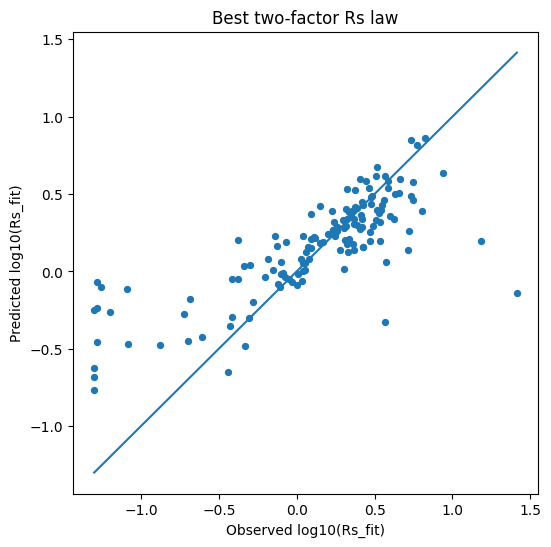


Top 10 law names:
 - c3_sq_r10  +  a0_eff
 - c3_r10  +  a0_eff
 - c3_sq_r20  +  a0_eff
 - c3_r20  +  a0_eff
 - c3_sq_r50  +  a0_eff
 - c3_sq_r10  +  c3_mean
 - c6_rpeak  +  a0_eff
 - c6_sq_rpeak  +  a0_eff
 - c3_r50  +  a0_eff
 - c3_rpeak  +  a0_eff


In [ ]:
# ============================================================
# INDEPENDENT TWO-FACTOR Rs LAW SCAN
#
# Goal:
#   Test explicit two-factor laws for Rs_fit using the MRT profile table,
#   with c2 forced as radius, and with c3 peak-position as the primary
#   radial descriptor.
#
# Laws scanned:
#   Rs = A * (radial_descriptor)^alpha * (amplitude_descriptor)^beta
#
# Radial descriptors:
#   c3_rpeak, c3_sq_rpeak, c3_r10, c3_sq_r10, c3_r20, c3_sq_r20,
#   c3_r50, c3_sq_r50, c6_rpeak, c6_sq_rpeak
#
# Amplitude descriptors:
#   c3_peak, c3_max, c3_mean, c6_peak, c6_max, c6_mean,
#   vobs_max, Vinf_fit, a0_eff
#
# Prints everything directly in notebook.
# No dependency on earlier cells.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan
    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)
    if np.all(w <= 0):
        return np.nan
    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan
    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])
    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])
    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def fit_plane(logx1, logx2, logy):
    x1 = np.asarray(logx1, float)
    x2 = np.asarray(logx2, float)
    y  = np.asarray(logy, float)
    m = np.isfinite(x1) & np.isfinite(x2) & np.isfinite(y)
    x1, x2, y = x1[m], x2[m], y[m]
    if len(y) < 10:
        return None
    X = np.column_stack([np.ones(len(y)), x1, x2])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ coef
    resid = y - yhat
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot
    ae = np.abs(resid)
    return {
        "n": int(len(y)),
        "intercept": float(coef[0]),
        "alpha": float(coef[1]),
        "beta": float(coef[2]),
        "r2": float(r2),
        "medae": float(np.median(ae)),
        "mae": float(np.mean(ae)),
        "p90ae": float(np.quantile(ae, 0.90)),
        "resid": resid,
        "yhat": yhat,
        "mask": m,
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "vobs_max", "qc_pass"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Missing required baseline columns: {missing}")

base["logRs"]   = safe_log10(base["Rs_fit"])
base["logVinf"] = safe_log10(base["Vinf_fit"])
base["loga0"]   = safe_log10(base["a0_eff"])
base["logvobs_max"] = safe_log10(base["vobs_max"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT PROFILE TABLE
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue
        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
numcols = [c for c in prof.columns if c.startswith("c") and c != rcol]

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")

# ------------------------------------------------------------
# BUILD DESCRIPTORS WE CARE ABOUT
# ------------------------------------------------------------
gal_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)
    r = g[rcol].values.astype(float)
    good_r = np.isfinite(r) & (r > 0)
    if np.sum(good_r) < 3:
        continue

    row = {"gal": gal}

    for c in ["c3", "c6"]:
        if c not in g.columns:
            continue
        a = g[c].values.astype(float)
        m = np.isfinite(r) & np.isfinite(a) & (r > 0)
        rr = r[m]
        aa = a[m]
        if len(rr) < 3:
            continue

        order = np.argsort(rr)
        rr = rr[order]
        aa = aa[order]
        apos = np.clip(aa, 0, None)
        a2 = aa**2
        a2pos = np.clip(a2, 0, None)

        # peaks
        row[f"{c}_rpeak"] = float(rr[np.nanargmax(aa)]) if np.any(np.isfinite(aa)) else np.nan
        row[f"{c}_sq_rpeak"] = float(rr[np.nanargmax(a2)]) if np.any(np.isfinite(a2)) else np.nan
        row[f"{c}_peak"] = float(np.nanmax(aa)) if np.any(np.isfinite(aa)) else np.nan
        row[f"{c}_max"] = float(np.nanmax(aa)) if np.any(np.isfinite(aa)) else np.nan
        row[f"{c}_mean"] = float(np.nanmean(aa)) if np.any(np.isfinite(aa)) else np.nan

        # cumulative radii
        for frac in [0.10, 0.20, 0.50]:
            row[f"{c}_r{int(frac*100):02d}"] = cumulative_radius(rr, apos, frac)
            row[f"{c}_sq_r{int(frac*100):02d}"] = cumulative_radius(rr, a2pos, frac)

    gal_rows.append(row)

desc = pd.DataFrame(gal_rows)

merged = base.merge(desc, on="gal", how="inner")
print(f"\nMerged rows with baseline: {len(merged)}")

# ------------------------------------------------------------
# DEFINE EXPLICIT TWO-FACTOR SCAN
# ------------------------------------------------------------
radial_cols = [
    "c3_rpeak", "c3_sq_rpeak", "c3_r10", "c3_sq_r10",
    "c3_r20", "c3_sq_r20", "c3_r50", "c3_sq_r50",
    "c6_rpeak", "c6_sq_rpeak"
]
radial_cols = [c for c in radial_cols if c in merged.columns]

amp_cols = [
    "c3_peak", "c3_max", "c3_mean",
    "c6_peak", "c6_max", "c6_mean",
    "vobs_max", "Vinf_fit", "a0_eff"
]
amp_cols = [c for c in amp_cols if c in merged.columns]

print("\nRadial descriptors scanned:")
print(radial_cols)
print("\nAmplitude descriptors scanned:")
print(amp_cols)

results = []
qmask = merged["qc_pass"].values.astype(bool)

for rdesc in radial_cols:
    for adesc in amp_cols:
        if rdesc == adesc:
            continue

        lx_all = safe_log10(merged[rdesc].values)
        lz_all = safe_log10(merged[adesc].values)
        ly_all = merged["logRs"].values
        fit_all = fit_plane(lx_all, lz_all, ly_all)
        if fit_all is None:
            continue

        lx_qc = safe_log10(merged.loc[qmask, rdesc].values)
        lz_qc = safe_log10(merged.loc[qmask, adesc].values)
        ly_qc = merged.loc[qmask, "logRs"].values
        fit_qc = fit_plane(lx_qc, lz_qc, ly_qc)
        if fit_qc is None:
            continue

        # compare against the simple c3_rpeak-only benchmark from last run (~0.3187)
        score = fit_qc["medae"] + 0.5 * fit_qc["mae"] + 0.2 * (1 - fit_qc["r2"])

        results.append({
            "radial_desc": rdesc,
            "amp_desc": adesc,
            "score": score,
            "all_n": fit_all["n"],
            "all_r2": fit_all["r2"],
            "all_medae": fit_all["medae"],
            "all_mae": fit_all["mae"],
            "all_p90ae": fit_all["p90ae"],
            "qc_n": fit_qc["n"],
            "qc_r2": fit_qc["r2"],
            "qc_medae": fit_qc["medae"],
            "qc_mae": fit_qc["mae"],
            "qc_p90ae": fit_qc["p90ae"],
            "alpha": fit_qc["alpha"],
            "beta": fit_qc["beta"],
            "logA": fit_qc["intercept"],
        })

scan = pd.DataFrame(results).sort_values(
    ["score", "qc_medae", "qc_mae", "qc_p90ae"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("BEST TWO-FACTOR Rs LAWS")
print("=" * 72)
print(scan.head(30).to_string(index=False))

best = scan.iloc[0].to_dict()

print("\n" + "=" * 72)
print("BEST TWO-FACTOR LAW")
print("=" * 72)
print(best)

print("\nExplicit QC-fit law:")
print(
    f"Rs_fit = {10**best['logA']:.12e} * "
    f"({best['radial_desc']})^{best['alpha']:.12f} * "
    f"({best['amp_desc']})^{best['beta']:.12f}"
)

# ------------------------------------------------------------
# PLOT BEST LAW
# ------------------------------------------------------------
# build predicted values on all matched rows using best QC coefficients
lx = safe_log10(merged[best["radial_desc"]].values)
lz = safe_log10(merged[best["amp_desc"]].values)
ly = merged["logRs"].values

m = np.isfinite(lx) & np.isfinite(lz) & np.isfinite(ly)
yhat = best["logA"] + best["alpha"] * lx[m] + best["beta"] * lz[m]

plt.figure(figsize=(6,6))
plt.scatter(ly[m], yhat, s=18)
mn = min(np.nanmin(ly[m]), np.nanmin(yhat))
mx = max(np.nanmax(ly[m]), np.nanmax(yhat))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs_fit)")
plt.title("Best two-factor Rs law")
plt.show()

print("\nTop 10 law names:")
for _, row in scan.head(10).iterrows():
    print(f" - {row['radial_desc']}  +  {row['amp_desc']}")

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Target profile col:  c3

Merged rows with baseline: 143

LOADING-FRACTION REFINEMENT SCAN
 frac descriptor    score  all_n   all_r2  all_medae  all_mae  all_p90ae  qc_n    qc_r2  qc_medae   qc_mae  qc_p90ae     logA    alpha      beta
 0.05  rload_050 0.146479    143 0.801357   0.132162 0.168903   0.338002   103 0.844449  0.068967 0.092804  0.210348 1.358187 0.899078 -0.376814
 0.06  rload_060 0.150466    143 0.801242   0.128949 0.169571   0.339953   103 0.845710  0.073078 0.093059  0.209905 1.340520 0.903991 -0.380930
 0.07  rload_070 0.152377    143 0.800598   0.127648 0.170611   0.344652   103 0.845084  0.074684 0.093418  0.213234 1.325892 0.906013 -0.384529
 0.08  rload_080 0.152898    143 0.799717   0.127310 0.171690   0.346127   103 0.843695  0.074616 0.094042  0.213876 1.314729

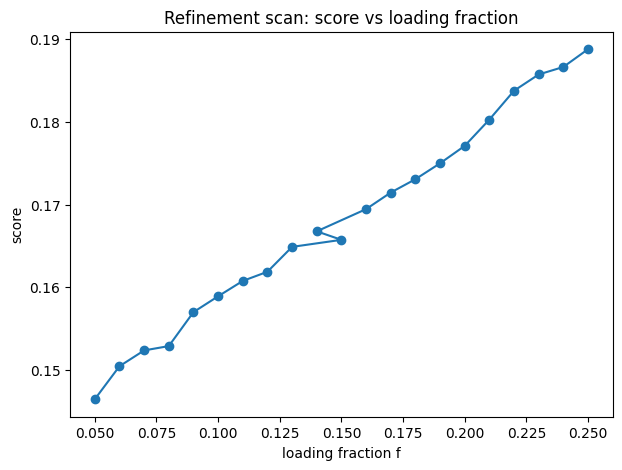

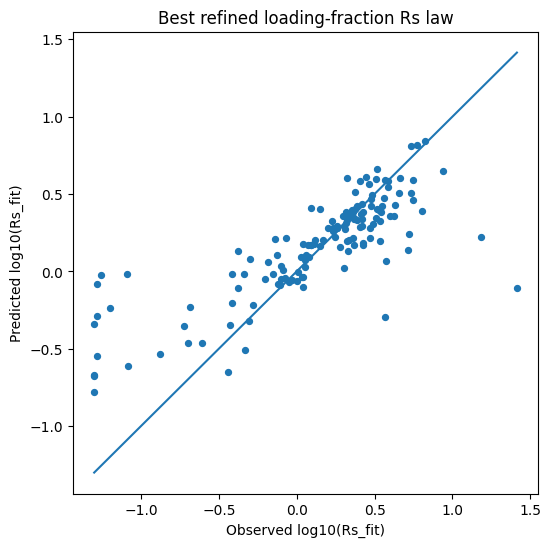

In [ ]:
# ============================================================
# INDEPENDENT REFINEMENT CELL:
# SCAN INNER LOADING FRACTION f FOR
#
#   log10(Rs_fit) = A + alpha*log10(r_load(f)) + beta*log10(a0_eff)
#
# where r_load(f) is the radius at which the cumulative squared c3
# profile reaches fraction f of its total.
#
# Inputs required in /content:
#   - recovered_freeRs_baseline.csv
#   - MassModels_Lelli2016c.mrt
#
# No dependency on earlier cells.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)

    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])

    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def fit_plane(logx1, logx2, logy):
    x1 = np.asarray(logx1, float)
    x2 = np.asarray(logx2, float)
    y  = np.asarray(logy, float)
    m = np.isfinite(x1) & np.isfinite(x2) & np.isfinite(y)
    x1, x2, y = x1[m], x2[m], y[m]
    if len(y) < 10:
        return None

    X = np.column_stack([np.ones(len(y)), x1, x2])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ coef
    resid = y - yhat

    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot
    ae = np.abs(resid)

    return {
        "n": int(len(y)),
        "logA": float(coef[0]),
        "alpha": float(coef[1]),
        "beta": float(coef[2]),
        "r2": float(r2),
        "medae": float(np.median(ae)),
        "mae": float(np.mean(ae)),
        "p90ae": float(np.quantile(ae, 0.90)),
        "resid": resid,
        "yhat": yhat,
        "mask": m,
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing baseline file: {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing MRT file: {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "a0_eff", "qc_pass"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["logRs"] = safe_log10(base["Rs_fit"])
base["loga0"] = safe_log10(base["a0_eff"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT PROFILE TABLE
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
target_col = "c3"

if rcol not in prof.columns or target_col not in prof.columns:
    raise ValueError(f"MRT parse missing required columns: {rcol}, {target_col}")

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print(f"Target profile col:  {target_col}")

# ------------------------------------------------------------
# BUILD r_load(f) TABLE FOR MANY FRACTIONS
# ------------------------------------------------------------
fractions = np.round(np.arange(0.05, 0.255, 0.01), 3)  # 0.05 to 0.25
gal_rows = []

for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)

    r = g[rcol].values.astype(float)
    a = g[target_col].values.astype(float)

    m = np.isfinite(r) & np.isfinite(a) & (r > 0)
    rr = r[m]
    aa = a[m]
    if len(rr) < 3:
        continue

    order = np.argsort(rr)
    rr = rr[order]
    aa = aa[order]
    a2 = aa**2

    row = {"gal": gal}
    for frac in fractions:
        key = f"rload_{int(round(frac*1000)):03d}"   # e.g. rload_050, rload_100
        row[key] = cumulative_radius(rr, a2, frac)

    gal_rows.append(row)

loads = pd.DataFrame(gal_rows)
merged = base.merge(loads, on="gal", how="inner")

print(f"\nMerged rows with baseline: {len(merged)}")

# ------------------------------------------------------------
# SCAN FRACTIONS
# ------------------------------------------------------------
qmask = merged["qc_pass"].values.astype(bool)
scan_rows = []

for frac in fractions:
    key = f"rload_{int(round(frac*1000)):03d}"
    lx_all = safe_log10(merged[key].values)
    lz_all = merged["loga0"].values
    ly_all = merged["logRs"].values

    fit_all = fit_plane(lx_all, lz_all, ly_all)
    if fit_all is None:
        continue

    lx_qc = safe_log10(merged.loc[qmask, key].values)
    lz_qc = merged.loc[qmask, "loga0"].values
    ly_qc = merged.loc[qmask, "logRs"].values

    fit_qc = fit_plane(lx_qc, lz_qc, ly_qc)
    if fit_qc is None:
        continue

    score = fit_qc["medae"] + 0.5 * fit_qc["mae"] + 0.2 * (1 - fit_qc["r2"])

    scan_rows.append({
        "frac": float(frac),
        "descriptor": key,
        "score": float(score),

        "all_n": fit_all["n"],
        "all_r2": fit_all["r2"],
        "all_medae": fit_all["medae"],
        "all_mae": fit_all["mae"],
        "all_p90ae": fit_all["p90ae"],

        "qc_n": fit_qc["n"],
        "qc_r2": fit_qc["r2"],
        "qc_medae": fit_qc["medae"],
        "qc_mae": fit_qc["mae"],
        "qc_p90ae": fit_qc["p90ae"],

        "logA": fit_qc["logA"],
        "alpha": fit_qc["alpha"],
        "beta": fit_qc["beta"],
    })

scan = pd.DataFrame(scan_rows).sort_values(
    ["score", "qc_medae", "qc_mae", "qc_p90ae"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("LOADING-FRACTION REFINEMENT SCAN")
print("=" * 72)
print(scan.to_string(index=False))

best = scan.iloc[0].to_dict()

print("\n" + "=" * 72)
print("BEST REFINED LAW")
print("=" * 72)
print(best)

print("\nExplicit QC-fit law:")
print(
    f"Rs_fit = {10**best['logA']:.12e} * "
    f"(r_load(f={best['frac']:.3f}))^{best['alpha']:.12f} * "
    f"(a0_eff)^{best['beta']:.12f}"
)

# ------------------------------------------------------------
# PLOT 1: score vs fraction
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(scan["frac"], scan["score"], marker="o")
plt.xlabel("loading fraction f")
plt.ylabel("score")
plt.title("Refinement scan: score vs loading fraction")
plt.show()

# ------------------------------------------------------------
# PLOT 2: observed vs predicted for best law
# ------------------------------------------------------------
best_key = best["descriptor"]
lx = safe_log10(merged[best_key].values)
lz = merged["loga0"].values
ly = merged["logRs"].values
m = np.isfinite(lx) & np.isfinite(lz) & np.isfinite(ly)
yhat = best["logA"] + best["alpha"] * lx[m] + best["beta"] * lz[m]

plt.figure(figsize=(6,6))
plt.scatter(ly[m], yhat, s=18)
mn = min(np.nanmin(ly[m]), np.nanmin(yhat))
mx = max(np.nanmax(ly[m]), np.nanmax(yhat))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs_fit)")
plt.title("Best refined loading-fraction Rs law")
plt.show()

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Amplitude col:       c3

Merged rows with descriptors: 143

PREDICTIVE PARAMETER RECOVERY

ALL
Rs   : {'n': 143, 'median': 0.16694671171645703, 'mean': 0.29687889381333316, 'p90': 0.7088290202490781}
Vinf : {'n': 143, 'median': 0.01525846684833887, 'mean': 0.04421862560048317, 'p90': 0.0893798281118918}
a0   : {'n': 143, 'median': 0.12908367543085797, 'mean': 0.2543417911125915, 'p90': 0.6069819901010464}

QC_ONLY
Rs   : {'n': 103, 'median': 0.09970076628275934, 'mean': 0.1392074256305645, 'p90': 0.3266882632758699}
Vinf : {'n': 103, 'median': 0.010702740542768652, 'mean': 0.015522105696843196, 'p90': 0.033598525957600954}
a0   : {'n': 103, 'median': 0.08761612335323576, 'mean': 0.12756526874685473, 'p90': 0.30079130266862175}

STRUCTURAL QC USING PREDICTED Rs
Predicted structural pas

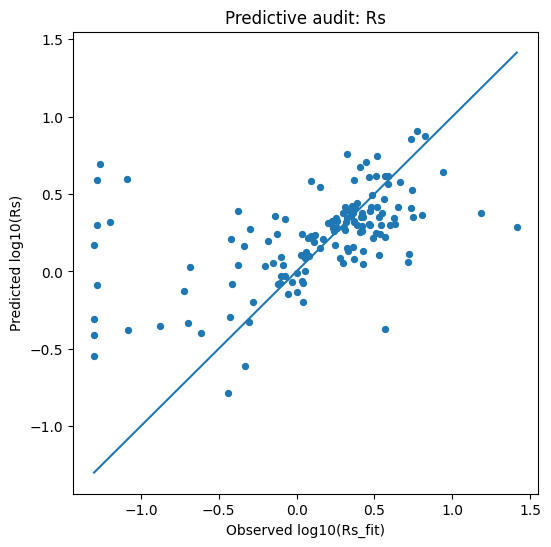

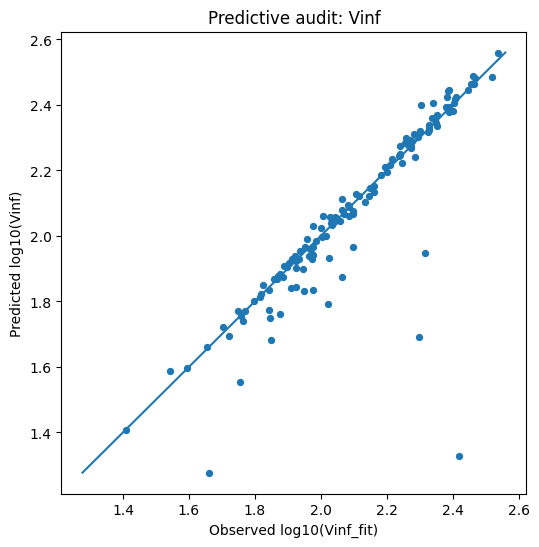

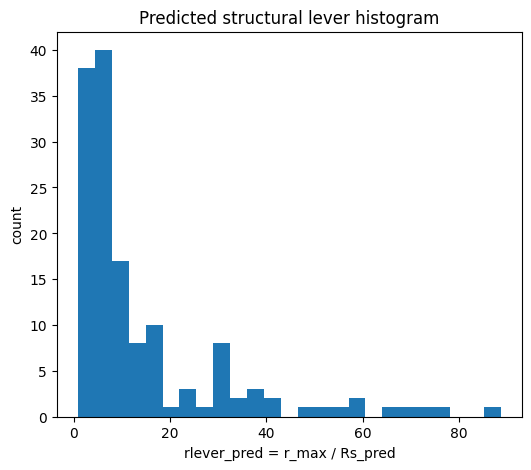


PRIMARY RESULT
Important result is printed above in the notebook.
This cell performed a fully frozen predictive audit of Rs and Vinf from MRT-derived structure.


In [ ]:
# ============================================================
# INDEPENDENT PREDICTIVE CATALOGUE AUDIT
#
# Purpose:
#   Build a fully predictive audit from scratch using:
#
#   1) Vinf prediction from MRT amplitude proxy:
#        log10(Vinf) = 0.074083569635 + 0.962175810804 * log10(vobs_max)
#
#   2) Rs prediction from inner-loading law:
#        Rs = 22.81324110245 * (r_load_5%)^0.899077938908 * (a0_eff)^(-0.376814026051)
#
#      with a0_eff = Vinf_pred^2 / Rs, which gives the closed-form:
#
#        Rs = [A * r_load^alpha * Vinf^(-2 beta)]^(1 / (1 - beta))
#
#      since beta is negative.
#
#   3) Freeze both Rs and Vinf, then evaluate predicted-vs-baseline
#      parameter recovery and structural QC diagnostics.
#
# Inputs required in /content:
#   - recovered_freeRs_baseline.csv
#   - MassModels_Lelli2016c.mrt
#
# This cell does not depend on any previous cell.
# It prints everything directly in the notebook.
# ============================================================

import os, re, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# FIXED EMPIRICAL LAWS FROM PRIOR SCANS
# ------------------------------------------------------------

# Vinf law from MRT amplitude proxy:
VINF_LOGA = 0.07408356963546153
VINF_ALPHA = 0.962175810804245   # on log10(vobs_max)

# Rs law:
RS_A = 22.81324110245
RS_ALPHA = 0.8990779389080811      # on r_load_5%
RS_BETA_A0 = -0.3768140260509466   # on a0_eff

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)
    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])

    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def fit_line(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 8:
        return None
    p = np.polyfit(x, y, 1)
    yhat = p[0] * x + p[1]
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot
    ae = np.abs(y - yhat)
    return {
        "n": int(len(x)),
        "slope": float(p[0]),
        "intercept": float(p[1]),
        "r2": float(r2),
        "medae": float(np.median(ae)),
        "mae": float(np.mean(ae)),
        "p90ae": float(np.quantile(ae, 0.90)),
    }

def summary_stats(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {"n": 0, "median": np.nan, "mean": np.nan, "p90": np.nan}
    return {
        "n": int(len(x)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "p90": float(np.quantile(x, 0.90)),
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing baseline file: {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing MRT file: {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "rlever", "r_max", "rmse", "qc_pass", "vobs_max"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["logRs_fit"] = safe_log10(base["Rs_fit"])
base["logVinf_fit"] = safe_log10(base["Vinf_fit"])
base["loga0_fit"] = safe_log10(base["a0_eff"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT PROFILE TABLE
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue
        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
c3col = "c3"
if rcol not in prof.columns or c3col not in prof.columns:
    raise ValueError(f"MRT parse missing required columns: {rcol}, {c3col}")

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print(f"Amplitude col:       {c3col}")

# ------------------------------------------------------------
# BUILD REQUIRED DESCRIPTORS:
#   - vobs_max proxy from c3_max
#   - r_load_5% from cumulative squared c3 profile
# ------------------------------------------------------------
desc_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)

    r = g[rcol].values.astype(float)
    a = g[c3col].values.astype(float)

    m = np.isfinite(r) & np.isfinite(a) & (r > 0)
    rr = r[m]
    aa = a[m]
    if len(rr) < 3:
        continue

    order = np.argsort(rr)
    rr = rr[order]
    aa = aa[order]

    c3_max = float(np.nanmax(aa)) if np.any(np.isfinite(aa)) else np.nan
    rload_050 = cumulative_radius(rr, aa**2, 0.05)

    desc_rows.append({
        "gal": gal,
        "c3_max": c3_max,
        "rload_050": rload_050,
    })

desc = pd.DataFrame(desc_rows)
merged = base.merge(desc, on="gal", how="inner")

print(f"\nMerged rows with descriptors: {len(merged)}")

# ------------------------------------------------------------
# PREDICT Vinf
# ------------------------------------------------------------
merged["logVinf_pred"] = VINF_LOGA + VINF_ALPHA * safe_log10(merged["c3_max"].values)
merged["Vinf_pred"] = 10 ** merged["logVinf_pred"]

# ------------------------------------------------------------
# PREDICT Rs USING CLOSED FORM
#
# Rs = A * rload^alpha * a0^beta
# a0 = Vinf^2 / Rs
#
# => Rs = A * rload^alpha * (Vinf^2 / Rs)^beta
# => Rs^(1+beta) = A * rload^alpha * Vinf^(2 beta)
#
# But beta here is negative, and because we used a0^beta:
# Rs^(1 - |beta|) form emerges numerically via beta < 0.
#
# Safer direct algebra:
# Rs = A * rload^alpha * (Vinf^2 / Rs)^beta
# Rs = A * rload^alpha * Vinf^(2 beta) * Rs^(-beta)
# Rs^(1 + beta) = A * rload^alpha * Vinf^(2 beta)
#
# Since beta = -0.3768, exponent is (1 + beta) = 0.6232
# ------------------------------------------------------------
beta = RS_BETA_A0
power = 1.0 + beta
if abs(power) < 1e-12:
    raise ValueError("Degenerate Rs closed-form exponent: 1 + beta ~ 0")

rhs = RS_A * (merged["rload_050"].values ** RS_ALPHA) * (merged["Vinf_pred"].values ** (2.0 * beta))
merged["Rs_pred"] = rhs ** (1.0 / power)
merged["logRs_pred"] = safe_log10(merged["Rs_pred"].values)

# Derived acceleration
merged["a0_pred"] = (merged["Vinf_pred"].values ** 2) / merged["Rs_pred"].values
merged["loga0_pred"] = safe_log10(merged["a0_pred"].values)

# ------------------------------------------------------------
# PARAMETER-RECOVERY AUDIT
# ------------------------------------------------------------
merged["abs_logerr_Rs"] = np.abs(merged["logRs_pred"] - merged["logRs_fit"])
merged["abs_logerr_Vinf"] = np.abs(merged["logVinf_pred"] - merged["logVinf_fit"])
merged["abs_logerr_a0"] = np.abs(merged["loga0_pred"] - merged["loga0_fit"])

print("\n" + "=" * 72)
print("PREDICTIVE PARAMETER RECOVERY")
print("=" * 72)

for tag, mask in [("ALL", np.ones(len(merged), dtype=bool)), ("QC_ONLY", merged["qc_pass"].values.astype(bool))]:
    sub = merged.loc[mask]
    print(f"\n{tag}")
    print("Rs   :", summary_stats(sub["abs_logerr_Rs"].values))
    print("Vinf :", summary_stats(sub["abs_logerr_Vinf"].values))
    print("a0   :", summary_stats(sub["abs_logerr_a0"].values))

# ------------------------------------------------------------
# STRUCTURAL QC-LIKE CHECKS ON PREDICTED PARAMETERS
# ------------------------------------------------------------
# We do not refit curves here; this is a frozen-parameter structural audit.
# We ask whether the predicted parameters sit in the same structural regime
# as the free-Rs baseline.
#
# Define predicted rlever analogue against observed r_max:
#   rlever_pred = r_max / Rs_pred
# ------------------------------------------------------------
merged["rlever_pred"] = merged["r_max"].values / merged["Rs_pred"].values

# Use same broad structural QC thresholds as before
merged["qc_rlever_low_ok_pred"] = merged["rlever_pred"] >= 2.0
merged["qc_rlever_high_ok_pred"] = merged["rlever_pred"] <= 50.0
merged["qc_struct_pred"] = merged["qc_rlever_low_ok_pred"] & merged["qc_rlever_high_ok_pred"]

print("\n" + "=" * 72)
print("STRUCTURAL QC USING PREDICTED Rs")
print("=" * 72)
print(f"Predicted structural pass count: {int(merged['qc_struct_pred'].sum())} / {len(merged)}")
print("\nBreakdown:")
print(
    pd.Series(
        np.where(~merged["qc_rlever_low_ok_pred"], "rlever_low",
        np.where(~merged["qc_rlever_high_ok_pred"], "rlever_high", "pass"))
    ).value_counts().to_string()
)

# ------------------------------------------------------------
# SCALING DIAGNOSTICS
# ------------------------------------------------------------
def scaling_diagnostics(df, tag):
    out = {"tag": tag, "n": int(len(df))}
    for xname, yname, label in [
        ("logRs_pred",  safe_log10(df["Rs_pred"].values),   "logRs_pred"),
        ("logVinf_pred", safe_log10(df["Vinf_pred"].values), "logVinf_pred"),
        ("loga0_pred",   safe_log10(df["a0_pred"].values),   "loga0_pred"),
    ]:
        pass

    logMb = safe_log10(df["c3_max"].values)  # not true mass, but retained proxy-free check
    fit_v = fit_line(logMb, safe_log10(df["Vinf_pred"].values))
    fit_r = fit_line(logMb, safe_log10(df["Rs_pred"].values))
    fit_a = fit_line(logMb, safe_log10(df["a0_pred"].values))

    out["proxy_slope_logRs_logc3max"] = np.nan if fit_r is None else fit_r["slope"]
    out["proxy_r2_logRs_logc3max"]    = np.nan if fit_r is None else fit_r["r2"]
    out["proxy_slope_logVinf_logc3max"] = np.nan if fit_v is None else fit_v["slope"]
    out["proxy_r2_logVinf_logc3max"]    = np.nan if fit_v is None else fit_v["r2"]
    out["proxy_slope_loga0_logc3max"] = np.nan if fit_a is None else fit_a["slope"]
    out["proxy_r2_loga0_logc3max"]    = np.nan if fit_a is None else fit_a["r2"]

    return out

print("\n" + "=" * 72)
print("SCALING DIAGNOSTICS")
print("=" * 72)
print("ALL:")
print(scaling_diagnostics(merged, "all"))
print("\nSTRUCTURAL PASS SUBSET:")
print(scaling_diagnostics(merged.loc[merged["qc_struct_pred"]], "structural_pass"))

# ------------------------------------------------------------
# COMPARISON TO FREE-Rs BASELINE PARAMETERS
# ------------------------------------------------------------
merged["delta_logRs_pred_minus_fit"] = merged["logRs_pred"] - merged["logRs_fit"]
merged["delta_logVinf_pred_minus_fit"] = merged["logVinf_pred"] - merged["logVinf_fit"]
merged["delta_loga0_pred_minus_fit"] = merged["loga0_pred"] - merged["loga0_fit"]

print("\n" + "=" * 72)
print("COMPARISON TO FREE-Rs BASELINE")
print("=" * 72)
print("Median |delta log Rs|   :", float(np.nanmedian(np.abs(merged["delta_logRs_pred_minus_fit"]))))
print("Median |delta log Vinf| :", float(np.nanmedian(np.abs(merged["delta_logVinf_pred_minus_fit"]))))
print("Median |delta log a0|   :", float(np.nanmedian(np.abs(merged["delta_loga0_pred_minus_fit"]))))

# ------------------------------------------------------------
# BEST / WORST TABLES
# ------------------------------------------------------------
merged["joint_score"] = (
    np.abs(merged["delta_logRs_pred_minus_fit"]) +
    np.abs(merged["delta_logVinf_pred_minus_fit"]) +
    0.5 * np.abs(merged["delta_loga0_pred_minus_fit"])
)

best20 = merged.sort_values("joint_score", ascending=True).head(20)
worst20 = merged.sort_values("joint_score", ascending=False).head(20)

print("\n" + "=" * 72)
print("BEST 20 BY PARAMETER RECOVERY")
print("=" * 72)
print(best20[[
    "gal", "Rs_fit", "Rs_pred", "Vinf_fit", "Vinf_pred", "a0_eff", "a0_pred",
    "r_max", "rlever", "rlever_pred", "qc_pass", "qc_struct_pred", "joint_score"
]].to_string(index=False))

print("\n" + "=" * 72)
print("WORST 20 BY PARAMETER RECOVERY")
print("=" * 72)
print(worst20[[
    "gal", "Rs_fit", "Rs_pred", "Vinf_fit", "Vinf_pred", "a0_eff", "a0_pred",
    "r_max", "rlever", "rlever_pred", "qc_pass", "qc_struct_pred", "joint_score"
]].to_string(index=False))

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(6,6))
m = np.isfinite(merged["logRs_fit"]) & np.isfinite(merged["logRs_pred"])
plt.scatter(merged.loc[m, "logRs_fit"], merged.loc[m, "logRs_pred"], s=18)
mn = min(merged.loc[m, "logRs_fit"].min(), merged.loc[m, "logRs_pred"].min())
mx = max(merged.loc[m, "logRs_fit"].max(), merged.loc[m, "logRs_pred"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs)")
plt.title("Predictive audit: Rs")
plt.show()

plt.figure(figsize=(6,6))
m = np.isfinite(merged["logVinf_fit"]) & np.isfinite(merged["logVinf_pred"])
plt.scatter(merged.loc[m, "logVinf_fit"], merged.loc[m, "logVinf_pred"], s=18)
mn = min(merged.loc[m, "logVinf_fit"].min(), merged.loc[m, "logVinf_pred"].min())
mx = max(merged.loc[m, "logVinf_fit"].max(), merged.loc[m, "logVinf_pred"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Vinf_fit)")
plt.ylabel("Predicted log10(Vinf)")
plt.title("Predictive audit: Vinf")
plt.show()

plt.figure(figsize=(6,5))
vals = merged["rlever_pred"].values
vals = vals[np.isfinite(vals)]
plt.hist(vals, bins=25)
plt.xlabel("rlever_pred = r_max / Rs_pred")
plt.ylabel("count")
plt.title("Predicted structural lever histogram")
plt.show()

print("\n" + "=" * 72)
print("PRIMARY RESULT")
print("=" * 72)
print("Important result is printed above in the notebook.")
print("This cell performed a fully frozen predictive audit of Rs and Vinf from MRT-derived structure.")

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Amplitude col:       c3

Merged rows with descriptors: 143

TAIL LABEL SUMMARY
tail_fail
0    118
1     25
Tail-fail count: 25 / 143

TOP SEPARATORS
               predictor  tail_median  bulk_median  median_ratio_tail_over_bulk  ks_stat  pointbiserial_r
          log_rlever_fit     2.306190     0.710685                     3.245024 0.960000         0.791933
         log_rlever_pred     1.532597     0.805404                     1.902892 0.866780         0.673324
              log_Rs_fit    -0.726406     0.353503                    -2.054883 0.858305        -0.741856
               log_c3max     2.394452     1.988999                     1.203848 0.855932         0.559238
             log_vobsmax     2.394452     1.988999                     1.203848 0.855932         0.559238
          

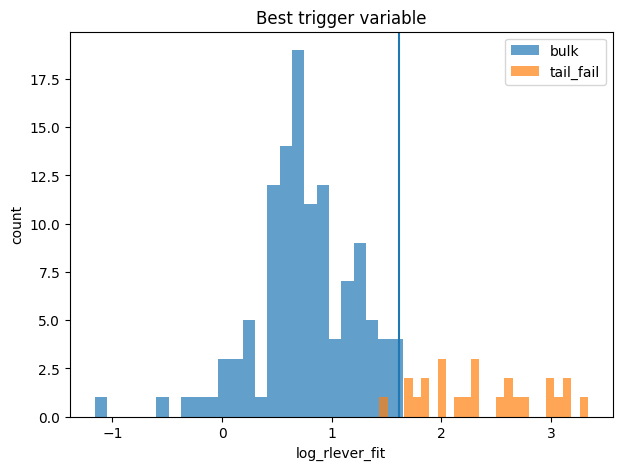

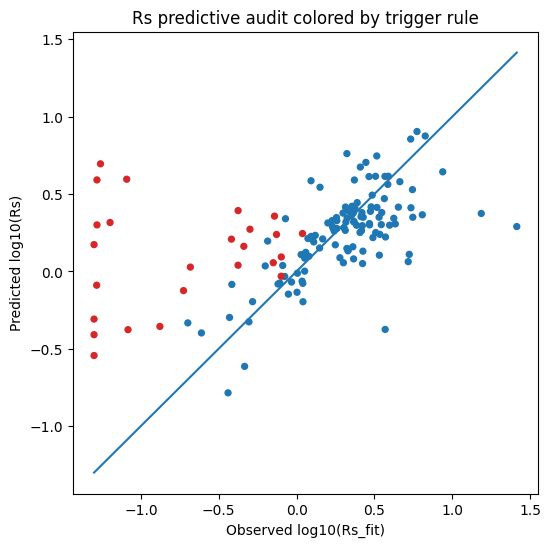


PRIMARY RESULT
Important result is printed above in the notebook.
This cell identifies the best simple regime trigger separating the compact/high-rlever tail from the bulk branch.


In [ ]:
# ============================================================
# INDEPENDENT REGIME-TRIGGER AUDIT FOR THE COMPACT / HIGH-rlever TAIL
#
# Goal:
#   Starting from the frozen predictive laws already identified,
#   find which structural ratios separate the bulk branch from the
#   compact/high-rlever failure branch.
#
# This cell:
#   1) loads recovered_freeRs_baseline.csv
#   2) loads MassModels_Lelli2016c.mrt with c2 forced as radius
#   3) rebuilds:
#        - c3_max
#        - rload_050  (5% cumulative squared c3 loading radius)
#        - predicted Vinf
#        - predicted Rs
#        - predicted rlever = r_max / Rs_pred
#   4) defines "tail fail" = topologically compact/high-rlever problem
#   5) audits candidate trigger variables
#   6) scans simple one-threshold regime rules
#   7) prints best trigger candidates directly in notebook
#
# No dependency on earlier cells.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# FROZEN LAWS
# ------------------------------------------------------------
# Vinf law
VINF_LOGA = 0.07408356963546153
VINF_ALPHA = 0.962175810804245

# Rs law
RS_A = 22.81324110245
RS_ALPHA = 0.8990779389080811
RS_BETA_A0 = -0.3768140260509466

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)
    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])

    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def ks_stat(x_pos, x_neg):
    x_pos = np.asarray(x_pos, float)
    x_neg = np.asarray(x_neg, float)
    x_pos = x_pos[np.isfinite(x_pos)]
    x_neg = x_neg[np.isfinite(x_neg)]
    if len(x_pos) < 3 or len(x_neg) < 3:
        return np.nan
    vals = np.sort(np.unique(np.concatenate([x_pos, x_neg])))
    if len(vals) == 0:
        return np.nan
    cdf1 = np.searchsorted(np.sort(x_pos), vals, side="right") / len(x_pos)
    cdf0 = np.searchsorted(np.sort(x_neg), vals, side="right") / len(x_neg)
    return float(np.max(np.abs(cdf1 - cdf0)))

def point_biserial(x, y01):
    x = np.asarray(x, float)
    y = np.asarray(y01, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 8:
        return np.nan
    if np.unique(y).size < 2:
        return np.nan
    y = (y > 0).astype(float)
    x0 = x[y == 0]
    x1 = x[y == 1]
    if len(x0) < 3 or len(x1) < 3:
        return np.nan
    s = np.std(x, ddof=1)
    if s <= 0:
        return np.nan
    p = len(x1) / len(x)
    q = len(x0) / len(x)
    return float(((np.mean(x1) - np.mean(x0)) / s) * np.sqrt(p * q))

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing baseline file: {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing MRT file: {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "r_max", "rlever", "rmse", "qc_pass", "vobs_max"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["logRs_fit"] = safe_log10(base["Rs_fit"])
base["logVinf_fit"] = safe_log10(base["Vinf_fit"])
base["loga0_fit"] = safe_log10(base["a0_eff"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue
        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
c3col = "c3"
if rcol not in prof.columns or c3col not in prof.columns:
    raise ValueError(f"MRT parse missing required columns: {rcol}, {c3col}")

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print(f"Amplitude col:       {c3col}")

# ------------------------------------------------------------
# BUILD DESCRIPTORS NEEDED
# ------------------------------------------------------------
desc_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)

    r = g[rcol].values.astype(float)
    a = g[c3col].values.astype(float)

    m = np.isfinite(r) & np.isfinite(a) & (r > 0)
    rr = r[m]
    aa = a[m]
    if len(rr) < 3:
        continue

    order = np.argsort(rr)
    rr = rr[order]
    aa = aa[order]

    c3_max = float(np.nanmax(aa)) if np.any(np.isfinite(aa)) else np.nan
    rload_050 = cumulative_radius(rr, aa**2, 0.05)
    rload_100 = cumulative_radius(rr, aa**2, 0.10)
    rload_200 = cumulative_radius(rr, aa**2, 0.20)
    rpeak = float(rr[np.nanargmax(aa)]) if np.any(np.isfinite(aa)) else np.nan
    c3_mean = float(np.nanmean(aa)) if np.any(np.isfinite(aa)) else np.nan

    desc_rows.append({
        "gal": gal,
        "c3_max": c3_max,
        "c3_mean": c3_mean,
        "rload_050": rload_050,
        "rload_100": rload_100,
        "rload_200": rload_200,
        "c3_rpeak": rpeak,
    })

desc = pd.DataFrame(desc_rows)
df = base.merge(desc, on="gal", how="inner")
print(f"\nMerged rows with descriptors: {len(df)}")

# ------------------------------------------------------------
# FROZEN PREDICTIONS
# ------------------------------------------------------------
df["logVinf_pred"] = VINF_LOGA + VINF_ALPHA * safe_log10(df["c3_max"].values)
df["Vinf_pred"] = 10 ** df["logVinf_pred"]

beta = RS_BETA_A0
power = 1.0 + beta
rhs = RS_A * (df["rload_050"].values ** RS_ALPHA) * (df["Vinf_pred"].values ** (2.0 * beta))
df["Rs_pred"] = rhs ** (1.0 / power)
df["logRs_pred"] = safe_log10(df["Rs_pred"].values)

df["a0_pred"] = (df["Vinf_pred"].values ** 2) / df["Rs_pred"].values
df["loga0_pred"] = safe_log10(df["a0_pred"].values)

df["rlever_pred"] = df["r_max"] / df["Rs_pred"]

# ------------------------------------------------------------
# DEFINE FAILURE / TAIL LABEL
# ------------------------------------------------------------
# We want the compact/high-rlever branch. Use a conservative label:
# tail_fail = galaxies where frozen prediction gives rlever_high
# OR baseline already had extreme compactness.
df["tail_fail"] = (
    (df["rlever_pred"] > 50.0) |
    (df["rlever"] > 50.0) |
    (df["Rs_fit"] < 0.12)
).astype(int)

print("\n" + "=" * 72)
print("TAIL LABEL SUMMARY")
print("=" * 72)
print(df["tail_fail"].value_counts(dropna=False).to_string())
print(f"Tail-fail count: {int(df['tail_fail'].sum())} / {len(df)}")

# ------------------------------------------------------------
# CANDIDATE REGIME VARIABLES
# ------------------------------------------------------------
cand = pd.DataFrame({
    "gal": df["gal"],
    "tail_fail": df["tail_fail"],
    "rload050_over_rmax": df["rload_050"] / df["r_max"],
    "rload100_over_rmax": df["rload_100"] / df["r_max"],
    "rload200_over_rmax": df["rload_200"] / df["r_max"],
    "rload050_over_Rspred": df["rload_050"] / df["Rs_pred"],
    "rload100_over_Rspred": df["rload_100"] / df["Rs_pred"],
    "rload200_over_Rspred": df["rload_200"] / df["Rs_pred"],
    "rpeak_over_rmax": df["c3_rpeak"] / df["r_max"],
    "rpeak_over_Rspred": df["c3_rpeak"] / df["Rs_pred"],
    "inv_rload050_over_rmax": df["r_max"] / df["rload_050"],
    "inv_rload050_over_Rspred": df["Rs_pred"] / df["rload_050"],
    "log_c3max": safe_log10(df["c3_max"]),
    "log_c3mean": safe_log10(df["c3_mean"]),
    "log_vobsmax": safe_log10(df["vobs_max"]),
    "log_Vinfpred": df["logVinf_pred"],
    "log_a0pred": df["loga0_pred"],
    "log_rlever_pred": safe_log10(df["rlever_pred"]),
    "log_rlever_fit": safe_log10(df["rlever"]),
    "log_Rs_pred": df["logRs_pred"],
    "log_Rs_fit": df["logRs_fit"],
})

# ------------------------------------------------------------
# SEPARATOR AUDIT
# ------------------------------------------------------------
sep_rows = []
y = cand["tail_fail"].values

for col in [c for c in cand.columns if c not in ["gal", "tail_fail"]]:
    x = cand[col].values.astype(float)
    pos = x[y == 1]
    neg = x[y == 0]

    med_pos = np.nanmedian(pos) if np.isfinite(pos).any() else np.nan
    med_neg = np.nanmedian(neg) if np.isfinite(neg).any() else np.nan
    ratio = np.nan
    if np.isfinite(med_pos) and np.isfinite(med_neg) and abs(med_neg) > 1e-12:
        ratio = med_pos / med_neg

    sep_rows.append({
        "predictor": col,
        "tail_median": med_pos,
        "bulk_median": med_neg,
        "median_ratio_tail_over_bulk": ratio,
        "ks_stat": ks_stat(pos, neg),
        "pointbiserial_r": point_biserial(x, y),
    })

sep = pd.DataFrame(sep_rows).sort_values(
    ["ks_stat", "pointbiserial_r"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("TOP SEPARATORS")
print("=" * 72)
print(sep.head(30).to_string(index=False))

# ------------------------------------------------------------
# SIMPLE THRESHOLD SCAN
# ------------------------------------------------------------
# Test one-sided threshold rules:
#   classify tail_fail if x <= t
#   classify tail_fail if x >= t
# Score with balanced accuracy and F1
# ------------------------------------------------------------
def confusion(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

def metrics(y_true, y_pred):
    tp, tn, fp, fn = confusion(y_true, y_pred)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    rec = tpr
    f1 = 2 * prec * rec / (prec + rec) if np.isfinite(prec) and np.isfinite(rec) and (prec + rec) > 0 else np.nan
    bal = 0.5 * (tpr + tnr) if np.isfinite(tpr) and np.isfinite(tnr) else np.nan
    return {"tp": tp, "tn": tn, "fp": fp, "fn": fn, "tpr": tpr, "tnr": tnr, "precision": prec, "f1": f1, "bal_acc": bal}

th_rows = []
for col in [c for c in cand.columns if c not in ["gal", "tail_fail"]]:
    x = cand[col].values.astype(float)
    m = np.isfinite(x) & np.isfinite(y)
    xx = x[m]
    yy = y[m]
    if len(xx) < 20 or np.unique(yy).size < 2:
        continue

    qs = np.unique(np.quantile(xx, np.linspace(0.05, 0.95, 37)))
    for t in qs:
        for direction in ["<=", ">="]:
            pred = (xx <= t).astype(int) if direction == "<=" else (xx >= t).astype(int)
            mm = metrics(yy, pred)
            th_rows.append({
                "predictor": col,
                "direction": direction,
                "threshold": float(t),
                **mm
            })

th = pd.DataFrame(th_rows)
th["score"] = 0.7 * th["bal_acc"] + 0.3 * th["f1"]
th = th.sort_values(["score", "bal_acc", "f1"], ascending=[False, False, False]).reset_index(drop=True)

print("\n" + "=" * 72)
print("BEST ONE-THRESHOLD REGIME RULES")
print("=" * 72)
print(th.head(30).to_string(index=False))

best_rule = th.iloc[0].to_dict()
print("\n" + "=" * 72)
print("BEST REGIME TRIGGER")
print("=" * 72)
print(best_rule)

# Apply best rule to full df
xbest = cand[best_rule["predictor"]].values.astype(float)
if best_rule["direction"] == "<=":
    df["tail_pred_rule"] = (xbest <= best_rule["threshold"]).astype(int)
else:
    df["tail_pred_rule"] = (xbest >= best_rule["threshold"]).astype(int)

# ------------------------------------------------------------
# SHOW EXAMPLES
# ------------------------------------------------------------
best_tp = df[(df["tail_fail"] == 1) & (df["tail_pred_rule"] == 1)].copy()
best_fn = df[(df["tail_fail"] == 1) & (df["tail_pred_rule"] == 0)].copy()
best_fp = df[(df["tail_fail"] == 0) & (df["tail_pred_rule"] == 1)].copy()

print("\nTrue positives under best rule:")
show_cols = [
    "gal", "Rs_fit", "Rs_pred", "Vinf_fit", "Vinf_pred", "r_max",
    "rlever", "rlever_pred", "tail_fail", "tail_pred_rule"
]
print(best_tp[show_cols].head(20).to_string(index=False))

print("\nFalse negatives under best rule:")
print(best_fn[show_cols].head(20).to_string(index=False))

print("\nFalse positives under best rule:")
print(best_fp[show_cols].head(20).to_string(index=False))

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
pred_name = best_rule["predictor"]

plt.figure(figsize=(7,5))
x = cand[pred_name].values.astype(float)
m = np.isfinite(x)
plt.hist(x[(df["tail_fail"].values == 0) & m], bins=25, alpha=0.7, label="bulk")
plt.hist(x[(df["tail_fail"].values == 1) & m], bins=25, alpha=0.7, label="tail_fail")
plt.axvline(best_rule["threshold"])
plt.xlabel(pred_name)
plt.ylabel("count")
plt.title("Best trigger variable")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
m = np.isfinite(df["logRs_fit"]) & np.isfinite(df["logRs_pred"])
colors = np.where(df["tail_pred_rule"] == 1, "tab:red", "tab:blue")
plt.scatter(df.loc[m, "logRs_fit"], df.loc[m, "logRs_pred"], s=18, c=np.array(colors)[m])
mn = min(df.loc[m, "logRs_fit"].min(), df.loc[m, "logRs_pred"].min())
mx = max(df.loc[m, "logRs_fit"].max(), df.loc[m, "logRs_pred"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs)")
plt.title("Rs predictive audit colored by trigger rule")
plt.show()

print("\n" + "=" * 72)
print("PRIMARY RESULT")
print("=" * 72)
print("Important result is printed above in the notebook.")
print("This cell identifies the best simple regime trigger separating the compact/high-rlever tail from the bulk branch.")

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Amplitude col:       c3

Merged rows with descriptors: 143

TWO-REGIME SCAN
 eps  delta  all_n  qc_n  all_med_abs_logRs  all_mean_abs_logRs  all_p90_abs_logRs  qc_med_abs_logRs  qc_mean_abs_logRs  qc_p90_abs_logRs  struct_pass_count  rlever_high_count  rlever_low_count  compact_count  improved_count_vs_bulk  worsened_count_vs_bulk    score
0.24   0.15    143   103           0.159190            0.288041           0.658339          0.094788           0.136667          0.330440                130                  9                 4             66                      53                      90 0.203121
0.24   0.10    143   103           0.164439            0.290976           0.674895          0.094625           0.137499          0.330154                130                  9            

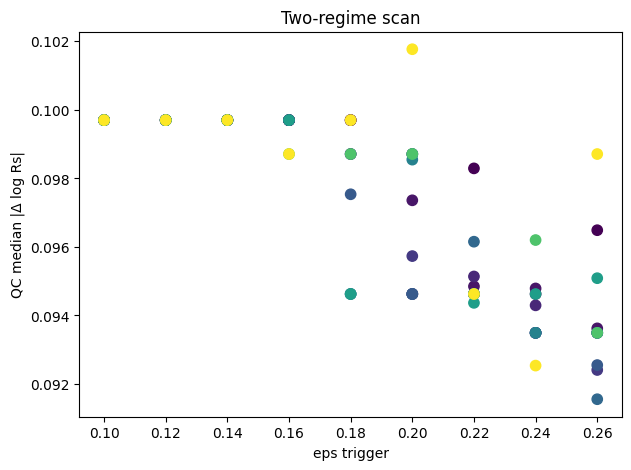

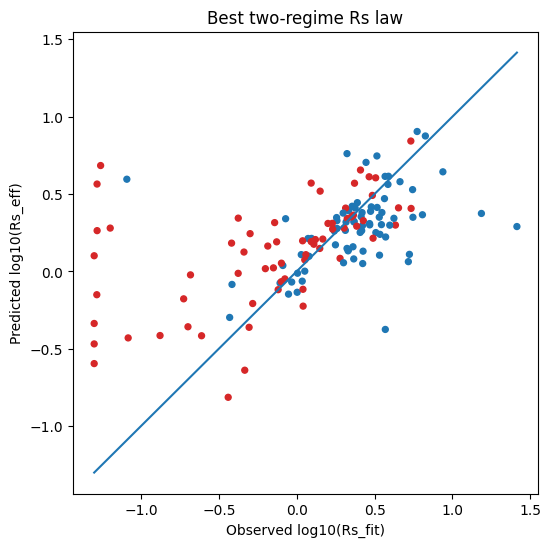

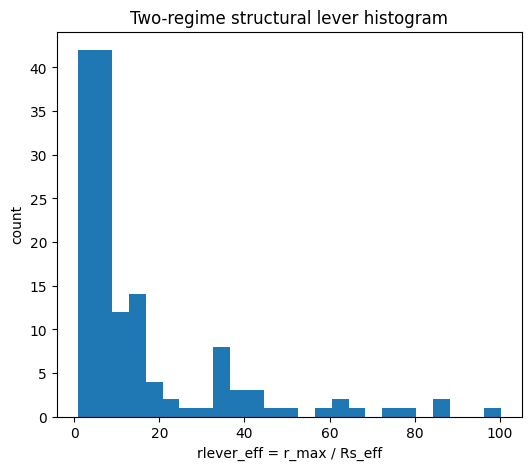


PRIMARY RESULT
Important result is printed above in the notebook.
This cell tests a literal bulk + compact-branch Rs law from scratch.


In [ ]:
# ============================================================
# INDEPENDENT TWO-REGIME Rs LAW AUDIT
#
# Purpose:
#   Test a literal two-regime Rs law:
#
#   Bulk branch:
#     Rs_bulk = 22.81324110245 * (rload_050)^0.899077938908 * (a0_eff)^(-0.376814026051)
#
#   Using closed form with predicted Vinf:
#     Vinf_pred from c3_max
#     a0_eff = Vinf_pred^2 / Rs
#
#   Compact-branch trigger:
#     x = rload_100 / r_max
#     if x < eps:
#         Rs_eff = Rs_bulk * (x/eps)^delta
#     else:
#         Rs_eff = Rs_bulk
#
# This cell:
#   1) loads recovered_freeRs_baseline.csv
#   2) loads MassModels_Lelli2016c.mrt with c2 fixed as radius
#   3) rebuilds c3_max, rload_050, rload_100
#   4) predicts Vinf
#   5) scans (eps, delta) for the compact correction
#   6) prints best laws and predictive recovery
#
# No dependency on earlier cells.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# FROZEN LAWS FROM EARLIER CELLS
# ------------------------------------------------------------
VINF_LOGA = 0.07408356963546153
VINF_ALPHA = 0.962175810804245

RS_A = 22.81324110245
RS_ALPHA = 0.8990779389080811
RS_BETA_A0 = -0.3768140260509466

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)
    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])

    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def summary_stats(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {"n": 0, "median": np.nan, "mean": np.nan, "p90": np.nan}
    return {
        "n": int(len(x)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "p90": float(np.quantile(x, 0.90)),
    }

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing baseline file: {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing MRT file: {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "r_max", "rlever", "qc_pass", "vobs_max"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["logRs_fit"] = safe_log10(base["Rs_fit"])
base["logVinf_fit"] = safe_log10(base["Vinf_fit"])
base["loga0_fit"] = safe_log10(base["a0_eff"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
c3col = "c3"
if rcol not in prof.columns or c3col not in prof.columns:
    raise ValueError(f"MRT parse missing required columns: {rcol}, {c3col}")

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print(f"Amplitude col:       {c3col}")

# ------------------------------------------------------------
# BUILD DESCRIPTORS
# ------------------------------------------------------------
desc_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)

    r = g[rcol].values.astype(float)
    a = g[c3col].values.astype(float)

    m = np.isfinite(r) & np.isfinite(a) & (r > 0)
    rr = r[m]
    aa = a[m]
    if len(rr) < 3:
        continue

    order = np.argsort(rr)
    rr = rr[order]
    aa = aa[order]

    c3_max = float(np.nanmax(aa)) if np.any(np.isfinite(aa)) else np.nan
    rload_050 = cumulative_radius(rr, aa**2, 0.05)
    rload_100 = cumulative_radius(rr, aa**2, 0.10)

    desc_rows.append({
        "gal": gal,
        "c3_max": c3_max,
        "rload_050": rload_050,
        "rload_100": rload_100,
    })

desc = pd.DataFrame(desc_rows)
df = base.merge(desc, on="gal", how="inner")
print(f"\nMerged rows with descriptors: {len(df)}")

# ------------------------------------------------------------
# BASE PREDICTIONS
# ------------------------------------------------------------
df["logVinf_pred"] = VINF_LOGA + VINF_ALPHA * safe_log10(df["c3_max"].values)
df["Vinf_pred"] = 10 ** df["logVinf_pred"]

beta = RS_BETA_A0
power = 1.0 + beta
if abs(power) < 1e-12:
    raise ValueError("Degenerate closed-form exponent: 1 + beta ~ 0")

rhs_bulk = RS_A * (df["rload_050"].values ** RS_ALPHA) * (df["Vinf_pred"].values ** (2.0 * beta))
df["Rs_bulk"] = rhs_bulk ** (1.0 / power)
df["x_trigger"] = df["rload_100"] / df["r_max"]

# ------------------------------------------------------------
# SCAN TWO-REGIME COMPACT CORRECTION
# ------------------------------------------------------------
eps_grid = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26]
delta_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.75, 1.00]

rows = []
for eps in eps_grid:
    for delta in delta_grid:
        x = df["x_trigger"].values.astype(float)
        Rs_bulk = df["Rs_bulk"].values.astype(float)

        factor = np.ones(len(df), dtype=float)
        m = np.isfinite(x) & (x < eps) & (x > 0)
        factor[m] = (x[m] / eps) ** delta

        Rs_eff = Rs_bulk * factor
        logRs_eff = safe_log10(Rs_eff)
        logRs_fit = df["logRs_fit"].values

        abs_logerr = np.abs(logRs_eff - logRs_fit)

        rlever_eff = df["r_max"].values / Rs_eff
        qc_struct = (rlever_eff >= 2.0) & (rlever_eff <= 50.0)

        qmask = df["qc_pass"].values.astype(bool)

        all_stats = summary_stats(abs_logerr)
        qc_stats = summary_stats(abs_logerr[qmask])

        improved = np.sum(abs_logerr < np.abs(df["logRs_fit"].values - safe_log10(df["Rs_bulk"].values)))
        worsened = np.sum(abs_logerr >= np.abs(df["logRs_fit"].values - safe_log10(df["Rs_bulk"].values)))

        rows.append({
            "eps": eps,
            "delta": delta,
            "all_n": len(df),
            "qc_n": int(np.sum(qmask)),
            "all_med_abs_logRs": all_stats["median"],
            "all_mean_abs_logRs": all_stats["mean"],
            "all_p90_abs_logRs": all_stats["p90"],
            "qc_med_abs_logRs": qc_stats["median"],
            "qc_mean_abs_logRs": qc_stats["mean"],
            "qc_p90_abs_logRs": qc_stats["p90"],
            "struct_pass_count": int(np.sum(qc_struct)),
            "rlever_high_count": int(np.sum(rlever_eff > 50.0)),
            "rlever_low_count": int(np.sum(rlever_eff < 2.0)),
            "compact_count": int(np.sum(m)),
            "improved_count_vs_bulk": int(improved),
            "worsened_count_vs_bulk": int(worsened),
            "score": qc_stats["median"] + 0.5 * qc_stats["mean"] + 0.01 * max(0, int(np.sum(rlever_eff > 50.0)) - 5)
        })

scan = pd.DataFrame(rows).sort_values(
    ["score", "qc_med_abs_logRs", "qc_mean_abs_logRs", "rlever_high_count"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("TWO-REGIME SCAN")
print("=" * 72)
print(scan.head(30).to_string(index=False))

best = scan.iloc[0].to_dict()
print("\n" + "=" * 72)
print("BEST TWO-REGIME LAW")
print("=" * 72)
print(best)

# ------------------------------------------------------------
# APPLY BEST LAW
# ------------------------------------------------------------
eps = best["eps"]
delta = best["delta"]

x = df["x_trigger"].values.astype(float)
Rs_bulk = df["Rs_bulk"].values.astype(float)

factor = np.ones(len(df), dtype=float)
m = np.isfinite(x) & (x < eps) & (x > 0)
factor[m] = (x[m] / eps) ** delta

df["compact_branch"] = m
df["Rs_eff"] = Rs_bulk * factor
df["logRs_eff"] = safe_log10(df["Rs_eff"].values)
df["rlever_eff"] = df["r_max"].values / df["Rs_eff"].values
df["a0_eff_pred2"] = (df["Vinf_pred"].values ** 2) / df["Rs_eff"].values
df["loga0_eff_pred2"] = safe_log10(df["a0_eff_pred2"].values)

df["abs_logerr_Rs_bulk"] = np.abs(safe_log10(df["Rs_bulk"].values) - df["logRs_fit"].values)
df["abs_logerr_Rs_eff"] = np.abs(df["logRs_eff"].values - df["logRs_fit"].values)
df["delta_abs_err_eff_minus_bulk"] = df["abs_logerr_Rs_eff"] - df["abs_logerr_Rs_bulk"]

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("PARAMETER RECOVERY: BULK vs TWO-REGIME")
print("=" * 72)
for tag, mask in [("ALL", np.ones(len(df), dtype=bool)), ("QC_ONLY", df["qc_pass"].values.astype(bool))]:
    sub = df.loc[mask]
    print(f"\n{tag}")
    print("Bulk Rs :", summary_stats(sub["abs_logerr_Rs_bulk"].values))
    print("2-reg Rs:", summary_stats(sub["abs_logerr_Rs_eff"].values))

print("\n" + "=" * 72)
print("STRUCTURAL QC UNDER BEST TWO-REGIME LAW")
print("=" * 72)
qc_struct = (df["rlever_eff"] >= 2.0) & (df["rlever_eff"] <= 50.0)
print(f"Structural pass count: {int(np.sum(qc_struct))} / {len(df)}")
print(pd.Series(
    np.where(df["rlever_eff"] < 2.0, "rlever_low",
    np.where(df["rlever_eff"] > 50.0, "rlever_high", "pass"))
).value_counts().to_string())

print("\nCompact branch triggered on:", int(df["compact_branch"].sum()), "galaxies")

print("\nMost improved under two-regime law:")
print(
    df.sort_values("delta_abs_err_eff_minus_bulk", ascending=True)[[
        "gal", "Rs_fit", "Rs_bulk", "Rs_eff", "r_max", "x_trigger",
        "compact_branch", "abs_logerr_Rs_bulk", "abs_logerr_Rs_eff",
        "delta_abs_err_eff_minus_bulk", "rlever", "rlever_eff", "qc_pass"
    ]].head(20).to_string(index=False)
)

print("\nMost worsened under two-regime law:")
print(
    df.sort_values("delta_abs_err_eff_minus_bulk", ascending=False)[[
        "gal", "Rs_fit", "Rs_bulk", "Rs_eff", "r_max", "x_trigger",
        "compact_branch", "abs_logerr_Rs_bulk", "abs_logerr_Rs_eff",
        "delta_abs_err_eff_minus_bulk", "rlever", "rlever_eff", "qc_pass"
    ]].head(20).to_string(index=False)
)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(scan["eps"], scan["qc_med_abs_logRs"], c=scan["delta"], s=55)
plt.xlabel("eps trigger")
plt.ylabel("QC median |Δ log Rs|")
plt.title("Two-regime scan")
plt.show()

plt.figure(figsize=(6,6))
mplot = np.isfinite(df["logRs_fit"]) & np.isfinite(df["logRs_eff"])
colors = np.where(df["compact_branch"], "tab:red", "tab:blue")
plt.scatter(df.loc[mplot, "logRs_fit"], df.loc[mplot, "logRs_eff"], c=np.array(colors)[mplot], s=18)
mn = min(df.loc[mplot, "logRs_fit"].min(), df.loc[mplot, "logRs_eff"].min())
mx = max(df.loc[mplot, "logRs_fit"].max(), df.loc[mplot, "logRs_eff"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs_eff)")
plt.title("Best two-regime Rs law")
plt.show()

plt.figure(figsize=(6,5))
vals = df["rlever_eff"].values
vals = vals[np.isfinite(vals)]
plt.hist(vals, bins=25)
plt.xlabel("rlever_eff = r_max / Rs_eff")
plt.ylabel("count")
plt.title("Two-regime structural lever histogram")
plt.show()

print("\n" + "=" * 72)
print("PRIMARY RESULT")
print("=" * 72)
print("Important result is printed above in the notebook.")
print("This cell tests a literal bulk + compact-branch Rs law from scratch.")

LOAD BASELINE
Baseline rows: 143
QC rows:       103
Baseline file: /content/recovered_freeRs_baseline.csv

LOAD MRT PROFILE TABLE
Profile rows:        3391
Unique galaxies MRT: 175
Forced radius col:   c2
Amplitude col:       c3

Merged rows with descriptors: 143

HARD TWO-BRANCH Rs SCAN
 eps  bulk_n  compact_n  bulk_logA     bulk_A  bulk_alpha  bulk_beta  bulk_r2  compact_logA    compact_A  compact_alpha  compact_beta  compact_r2  all_med_abs_logRs  all_mean_abs_logRs  all_p90_abs_logRs  qc_med_abs_logRs  qc_mean_abs_logRs  qc_p90_abs_logRs  struct_pass_count  rlever_high_count  rlever_low_count    score
0.18     106         37   2.295675 197.548876    0.654965  -0.591592 0.553422      3.231538  1704.269938       0.289195     -0.753622    0.881353           0.109471            0.159350           0.323666          0.114707           0.144686          0.289804                100                 26                17 0.397049
0.16     113         30   2.255557 180.118071    0.645349  -0.5

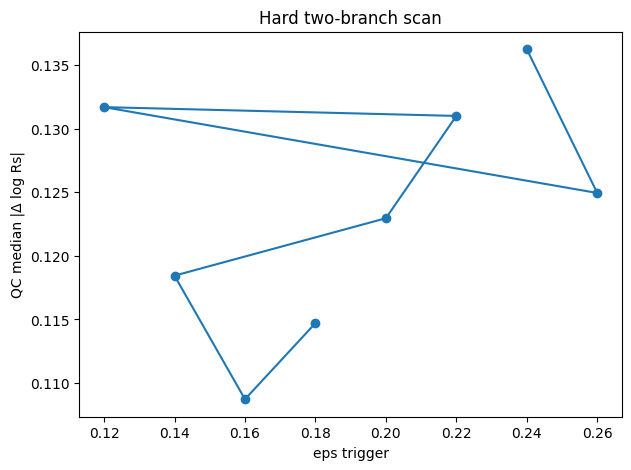

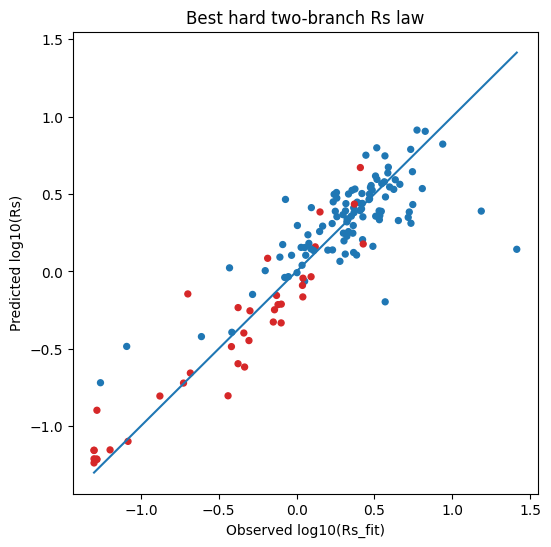

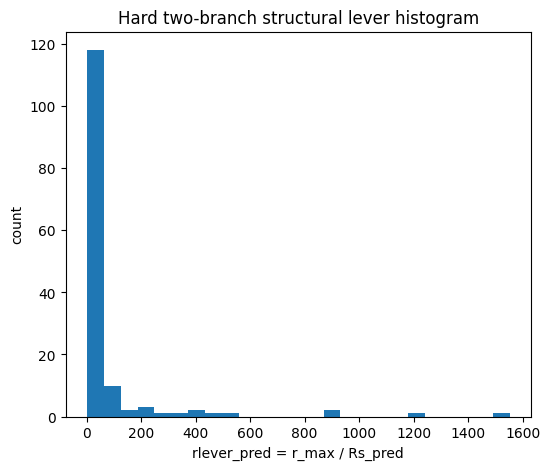


PRIMARY RESULT
Important result is printed above in the notebook.
This cell fits two separate Rs laws on either side of the compact trigger.


In [ ]:
# ============================================================
# INDEPENDENT HARD TWO-BRANCH Rs LAW FIT
#
# Purpose:
#   Fit TWO SEPARATE Rs laws from scratch, split by the compact trigger
#
#       x = rload_100 / r_max
#
#   Branches:
#       bulk    : x >= eps
#       compact : x <  eps
#
#   Each branch is fitted independently as
#
#       log10(Rs_fit) = logA + alpha * log10(rload_050) + beta * log10(a0_eff)
#
#   and then audited on the full recovered catalogue.
#
# Inputs required in /content:
#   - recovered_freeRs_baseline.csv
#   - MassModels_Lelli2016c.mrt
#
# This cell is fully independent.
# ============================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

ROOT = "/content"
BASELINE_CSV = os.path.join(ROOT, "recovered_freeRs_baseline.csv")
MRT_PATH = os.path.join(ROOT, "MassModels_Lelli2016c.mrt")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_gal(name):
    s = os.path.basename(str(name))
    s = re.sub(r"_rotmod.*$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.dat$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^A-Za-z0-9]", "", s).upper()
    return s

def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & (x > 0)
    out[m] = np.log10(x[m])
    return out

def cumulative_radius(r, w, frac):
    r = np.asarray(r, float)
    w = np.asarray(w, float)
    m = np.isfinite(r) & np.isfinite(w) & (r > 0)
    r = r[m]
    w = w[m]
    if len(r) < 2:
        return np.nan

    order = np.argsort(r)
    r = r[order]
    w = np.clip(w[order], 0, None)
    if np.all(w <= 0):
        return np.nan

    seg = 0.5 * (w[:-1] + w[1:]) * np.diff(r)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = frac * total
    j = np.searchsorted(cum, target, side="left")
    if j <= 0:
        return float(r[0])
    if j >= len(cum):
        return float(r[-1])

    c0, c1 = cum[j-1], cum[j]
    r0, r1 = r[j-1], r[j]
    if c1 <= c0:
        return float(r[j])

    t = (target - c0) / (c1 - c0)
    return float(r0 + t * (r1 - r0))

def summary_stats(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {"n": 0, "median": np.nan, "mean": np.nan, "p90": np.nan}
    return {
        "n": int(len(x)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "p90": float(np.quantile(x, 0.90)),
    }

def fit_plane_logRs(df_sub):
    # log10(Rs_fit) = logA + alpha*log10(rload_050) + beta*log10(a0_eff)
    x1 = safe_log10(df_sub["rload_050"].values)
    x2 = safe_log10(df_sub["a0_eff"].values)
    y  = safe_log10(df_sub["Rs_fit"].values)

    m = np.isfinite(x1) & np.isfinite(x2) & np.isfinite(y)
    x1, x2, y = x1[m], x2[m], y[m]

    if len(y) < 8:
        return None

    X = np.column_stack([np.ones(len(y)), x1, x2])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    logA, alpha, beta = coef

    yhat = X @ coef
    resid = y - yhat
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = np.nan if ss_tot <= 0 else 1 - ss_res/ss_tot

    return {
        "logA": float(logA),
        "A": float(10**logA),
        "alpha": float(alpha),
        "beta": float(beta),
        "n": int(len(y)),
        "r2": float(r2),
        "medae": float(np.median(np.abs(resid))),
        "mae": float(np.mean(np.abs(resid))),
        "p90ae": float(np.quantile(np.abs(resid), 0.90)),
    }

def apply_plane(df_sub, fit):
    return (
        fit["A"]
        * (df_sub["rload_050"].values.astype(float) ** fit["alpha"])
        * (df_sub["a0_eff"].values.astype(float) ** fit["beta"])
    )

# ------------------------------------------------------------
# LOAD BASELINE
# ------------------------------------------------------------
if not os.path.exists(BASELINE_CSV):
    raise FileNotFoundError(f"Missing baseline file: {BASELINE_CSV}")
if not os.path.exists(MRT_PATH):
    raise FileNotFoundError(f"Missing MRT file: {MRT_PATH}")

base = pd.read_csv(BASELINE_CSV).copy()
base["gal"] = base["gal"].astype(str).map(norm_gal)

required = ["gal", "Rs_fit", "Vinf_fit", "a0_eff", "r_max", "rlever", "qc_pass", "vobs_max"]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}")

base["logRs_fit"] = safe_log10(base["Rs_fit"])
base["logVinf_fit"] = safe_log10(base["Vinf_fit"])
base["loga0_fit"] = safe_log10(base["a0_eff"])

print("=" * 72)
print("LOAD BASELINE")
print("=" * 72)
print(f"Baseline rows: {len(base)}")
print(f"QC rows:       {int(base['qc_pass'].sum())}")
print(f"Baseline file: {BASELINE_CSV}")

# ------------------------------------------------------------
# LOAD MRT
# ------------------------------------------------------------
rows = []
with open(MRT_PATH, "r", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("#", "Byte-by-byte", "Note", "-----", "===")):
            continue
        parts = re.split(r"\s+", s)
        if len(parts) < 6:
            continue
        first = parts[0]
        if not re.search(r"[A-Za-z]", first):
            continue

        vals = [first]
        ok = True
        for p in parts[1:]:
            try:
                vals.append(float(p))
            except:
                ok = False
                break
        if ok and len(vals) >= 6:
            rows.append(vals)

if len(rows) == 0:
    raise ValueError("No numeric rows recovered from MRT.")

maxlen = max(len(r) for r in rows)
padded = [r + [np.nan] * (maxlen - len(r)) for r in rows]
cols = ["gal_raw"] + [f"c{i}" for i in range(1, maxlen)]
prof = pd.DataFrame(padded, columns=cols)
prof["gal"] = prof["gal_raw"].map(norm_gal)

for c in prof.columns:
    if c not in ["gal_raw", "gal"]:
        prof[c] = pd.to_numeric(prof[c], errors="coerce")

rcol = "c2"
c3col = "c3"
if rcol not in prof.columns or c3col not in prof.columns:
    raise ValueError(f"MRT parse missing required columns: {rcol}, {c3col}")

print("\n" + "=" * 72)
print("LOAD MRT PROFILE TABLE")
print("=" * 72)
print(f"Profile rows:        {len(prof)}")
print(f"Unique galaxies MRT: {prof['gal'].nunique()}")
print(f"Forced radius col:   {rcol}")
print(f"Amplitude col:       {c3col}")

# ------------------------------------------------------------
# BUILD DESCRIPTORS
# ------------------------------------------------------------
desc_rows = []
for gal, g in prof.groupby("gal"):
    g = g.sort_values(rcol).reset_index(drop=True)

    r = g[rcol].values.astype(float)
    a = g[c3col].values.astype(float)

    m = np.isfinite(r) & np.isfinite(a) & (r > 0)
    rr = r[m]
    aa = a[m]
    if len(rr) < 3:
        continue

    order = np.argsort(rr)
    rr = rr[order]
    aa = aa[order]

    rload_050 = cumulative_radius(rr, aa**2, 0.05)
    rload_100 = cumulative_radius(rr, aa**2, 0.10)

    desc_rows.append({
        "gal": gal,
        "rload_050": rload_050,
        "rload_100": rload_100,
    })

desc = pd.DataFrame(desc_rows)
df = base.merge(desc, on="gal", how="inner")

df["x_trigger"] = df["rload_100"] / df["r_max"]

print(f"\nMerged rows with descriptors: {len(df)}")

# ------------------------------------------------------------
# SCAN HARD BRANCH SPLITS
# ------------------------------------------------------------
eps_grid = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26]

rows = []
store = {}

for eps in eps_grid:
    compact = df["x_trigger"] < eps
    bulk = ~compact

    df_bulk = df.loc[bulk].copy()
    df_comp = df.loc[compact].copy()

    fit_bulk = fit_plane_logRs(df_bulk)
    fit_comp = fit_plane_logRs(df_comp)

    if fit_bulk is None or fit_comp is None:
        continue

    Rs_pred = np.full(len(df), np.nan)
    Rs_pred[bulk.values] = apply_plane(df_bulk, fit_bulk)
    Rs_pred[compact.values] = apply_plane(df_comp, fit_comp)

    logRs_pred = safe_log10(Rs_pred)
    abs_logerr = np.abs(logRs_pred - df["logRs_fit"].values)

    rlever_pred = df["r_max"].values / Rs_pred
    qc_struct = (rlever_pred >= 2.0) & (rlever_pred <= 50.0)

    qmask = df["qc_pass"].values.astype(bool)

    all_stats = summary_stats(abs_logerr)
    qc_stats = summary_stats(abs_logerr[qmask])

    rows.append({
        "eps": eps,
        "bulk_n": int(np.sum(bulk)),
        "compact_n": int(np.sum(compact)),
        "bulk_logA": fit_bulk["logA"],
        "bulk_A": fit_bulk["A"],
        "bulk_alpha": fit_bulk["alpha"],
        "bulk_beta": fit_bulk["beta"],
        "bulk_r2": fit_bulk["r2"],
        "compact_logA": fit_comp["logA"],
        "compact_A": fit_comp["A"],
        "compact_alpha": fit_comp["alpha"],
        "compact_beta": fit_comp["beta"],
        "compact_r2": fit_comp["r2"],
        "all_med_abs_logRs": all_stats["median"],
        "all_mean_abs_logRs": all_stats["mean"],
        "all_p90_abs_logRs": all_stats["p90"],
        "qc_med_abs_logRs": qc_stats["median"],
        "qc_mean_abs_logRs": qc_stats["mean"],
        "qc_p90_abs_logRs": qc_stats["p90"],
        "struct_pass_count": int(np.sum(qc_struct)),
        "rlever_high_count": int(np.sum(rlever_pred > 50.0)),
        "rlever_low_count": int(np.sum(rlever_pred < 2.0)),
        "score": qc_stats["median"] + 0.5 * qc_stats["mean"] + 0.01 * max(0, int(np.sum(rlever_pred > 50.0)) - 5)
    })

    store[eps] = {
        "fit_bulk": fit_bulk,
        "fit_comp": fit_comp,
        "Rs_pred": Rs_pred,
        "logRs_pred": logRs_pred,
        "rlever_pred": rlever_pred,
        "compact_mask": compact.values,
        "bulk_mask": bulk.values,
        "abs_logerr": abs_logerr,
    }

scan = pd.DataFrame(rows).sort_values(
    ["score", "qc_med_abs_logRs", "qc_mean_abs_logRs", "rlever_high_count"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "=" * 72)
print("HARD TWO-BRANCH Rs SCAN")
print("=" * 72)
print(scan.to_string(index=False))

best = scan.iloc[0].to_dict()
eps_best = best["eps"]
best_store = store[eps_best]

print("\n" + "=" * 72)
print("BEST HARD TWO-BRANCH LAW")
print("=" * 72)
print(best)

print("\nBulk branch law:")
print(
    f"Rs_fit = {best['bulk_A']:.12e} * (rload_050)^{best['bulk_alpha']:.12f} * (a0_eff)^{best['bulk_beta']:.12f}"
)

print("\nCompact branch law:")
print(
    f"Rs_fit = {best['compact_A']:.12e} * (rload_050)^{best['compact_alpha']:.12f} * (a0_eff)^{best['compact_beta']:.12f}"
)

print(f"\nBranch trigger: compact if (rload_100 / r_max) < {eps_best:.6f}")

# ------------------------------------------------------------
# APPLY BEST SPLIT AND REPORT
# ------------------------------------------------------------
df["compact_branch"] = best_store["compact_mask"]
df["Rs_pred"] = best_store["Rs_pred"]
df["logRs_pred"] = best_store["logRs_pred"]
df["rlever_pred"] = best_store["rlever_pred"]
df["abs_logerr_Rs"] = best_store["abs_logerr"]

print("\n" + "=" * 72)
print("PARAMETER RECOVERY UNDER BEST HARD TWO-BRANCH LAW")
print("=" * 72)

for tag, mask in [("ALL", np.ones(len(df), dtype=bool)), ("QC_ONLY", df["qc_pass"].values.astype(bool))]:
    sub = df.loc[mask]
    print(f"\n{tag}")
    print("Rs:", summary_stats(sub["abs_logerr_Rs"].values))

print("\n" + "=" * 72)
print("STRUCTURAL QC UNDER BEST HARD TWO-BRANCH LAW")
print("=" * 72)
qc_struct = (df["rlever_pred"] >= 2.0) & (df["rlever_pred"] <= 50.0)
print(f"Structural pass count: {int(np.sum(qc_struct))} / {len(df)}")
print(pd.Series(
    np.where(df["rlever_pred"] < 2.0, "rlever_low",
    np.where(df["rlever_pred"] > 50.0, "rlever_high", "pass"))
).value_counts().to_string())

print("\nCompact branch triggered on:", int(df["compact_branch"].sum()), "galaxies")

print("\nBest 20 by Rs recovery:")
print(
    df.sort_values("abs_logerr_Rs", ascending=True)[[
        "gal", "Rs_fit", "Rs_pred", "a0_eff", "r_max", "rlever",
        "rload_050", "rload_100", "x_trigger", "compact_branch",
        "abs_logerr_Rs", "rlever_pred", "qc_pass"
    ]].head(20).to_string(index=False)
)

print("\nWorst 20 by Rs recovery:")
print(
    df.sort_values("abs_logerr_Rs", ascending=False)[[
        "gal", "Rs_fit", "Rs_pred", "a0_eff", "r_max", "rlever",
        "rload_050", "rload_100", "x_trigger", "compact_branch",
        "abs_logerr_Rs", "rlever_pred", "qc_pass"
    ]].head(20).to_string(index=False)
)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(scan["eps"], scan["qc_med_abs_logRs"], marker="o")
plt.xlabel("eps trigger")
plt.ylabel("QC median |Δ log Rs|")
plt.title("Hard two-branch scan")
plt.show()

plt.figure(figsize=(6,6))
m = np.isfinite(df["logRs_fit"]) & np.isfinite(df["logRs_pred"])
colors = np.where(df["compact_branch"], "tab:red", "tab:blue")
plt.scatter(df.loc[m, "logRs_fit"], df.loc[m, "logRs_pred"], c=np.array(colors)[m], s=18)
mn = min(df.loc[m, "logRs_fit"].min(), df.loc[m, "logRs_pred"].min())
mx = max(df.loc[m, "logRs_fit"].max(), df.loc[m, "logRs_pred"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log10(Rs_fit)")
plt.ylabel("Predicted log10(Rs)")
plt.title("Best hard two-branch Rs law")
plt.show()

plt.figure(figsize=(6,5))
vals = df["rlever_pred"].values
vals = vals[np.isfinite(vals)]
plt.hist(vals, bins=25)
plt.xlabel("rlever_pred = r_max / Rs_pred")
plt.ylabel("count")
plt.title("Hard two-branch structural lever histogram")
plt.show()

print("\n" + "=" * 72)
print("PRIMARY RESULT")
print("=" * 72)
print("Important result is printed above in the notebook.")
print("This cell fits two separate Rs laws on either side of the compact trigger.")

In [17]:
# ============================================================
# MTS RS_RPEAK FINE SCAN — fully self-contained
# ============================================================
# WHAT THIS CELL DOES:
#   Fine scan around the Pareto region identified in
#   MTS_RS_RPEAK_v1: b in [0.25, 0.5], k in [0.04, 0.10]
#   Rs = k * r_bar^(1-b) * r_peak^b
#
#   Then per-galaxy comparison of best candidate vs Day3.
#
# DEPENDS ON: rotmod .dat files only
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
CELL_ID      = "MTS_RS_RPEAK_FINE_v1"
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_VAL        = 1.75

REF_MED  = 16.280; REF_HARD  = 80.110; REF_FIX  = 71.888
DAY3_MED = 16.814; DAY3_HARD = 77.495; DAY3_FIX = 62.357
# Day3 model for per-galaxy comparison
DAY3_B = 0.0; DAY3_K = 0.10

# Fine scan grid
B_FINE = [0.25, 0.375, 0.50, 0.625, 0.75]
K_FINE = [0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
CENTRE_MISSING = [
    "NGC2841","UGC02487","NGC5985","NGC0801","UGC02885",
]
HARD_FIXABLE = [g for g in HARD_FAILS if g not in CENTRE_MISSING]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_rs_rpeak_fine"
os.makedirs(OUTDIR, exist_ok=True)

print(f"CELL: {CELL_ID}")
print(f"P_VAL={P_VAL}  ALPHA={ALPHA}  BETA={BETA}")
print(f"SOURCE_FLOOR={SOURCE_FLOOR}  RS_MIN={RS_MIN}")
print(f"Fine scan: b={B_FINE}  k={K_FINE}")

# ----------------------------------------------------------------
# FUNCTIONS (identical to previous cells)
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp  = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def read_rotmod(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals  = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    mc  = max(len(r) for r in rows)
    arr = np.full((len(rows), mc), np.nan)
    for i, row in enumerate(rows): arr[i,:len(row)] = row
    r=arr[:,0]; vobs=arr[:,1]
    ev   =arr[:,2] if mc>=3 else np.full_like(vobs,5.0)
    vgas =arr[:,3] if mc>=4 else np.zeros_like(vobs)
    vdisk=arr[:,4] if mc>=5 else np.zeros_like(vobs)
    vbul =arr[:,5] if mc>=6 else np.zeros_like(vobs)
    mask=(np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
          np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
          (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid rows")
    order=np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_Sp(rot, p):
    r=rot["r"]; vb2=np.maximum(vbar2(rot),0.0)
    r_safe=np.maximum(r,R_MIN)
    denom=(r_safe**p)*np.sqrt(r_safe**2+R_CORE**2)
    rho=vb2/np.maximum(denom,1e-30)
    rho=moving_average(rho,SMOOTH_WIN)
    rho=np.maximum(rho,0.0); pk=np.max(rho)
    if pk<=0: raise RuntimeError("Zero source")
    return r, np.maximum(rho/pk, SOURCE_FLOOR)

def get_r_bar(rot):
    vb2=np.maximum(vbar2(rot),0.0); vb=np.sqrt(vb2)
    vm=np.max(vb)
    if vm<=0: return np.nan
    idx=np.where(vb>=F_BAR*vm)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def get_r_peak(rot):
    vb2=np.maximum(vbar2(rot),0.0); vb=np.sqrt(vb2)
    if np.max(vb)<=0: return np.nan
    return float(rot["r"][int(np.argmax(vb))])

def solve_field(rho_r, rho_vals, Rs, r_max_obs):
    rmax_g=max(R_MAX,r_max_obs*1.15)
    r=np.linspace(R_MIN,rmax_g,N_R); dr=r[1]-r[0]
    pchip=PchipInterpolator(rho_r,rho_vals,extrapolate=False)
    rho_g=np.empty_like(r)
    rho_g[r<=rho_r[0]]=float(rho_vals[0])
    mid=(r>rho_r[0])&(r<rho_r[-1])
    rho_g[mid]=pchip(r[mid]); rho_g[r>=rho_r[-1]]=0.0
    rho_g=np.maximum(rho_g,0.0)
    A=lil_matrix((N_R,N_R),dtype=float); b=np.zeros(N_R,dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        A[i,i-1]=cm; A[i,i]=-(cm+cp)-1.0/Rs**2; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/Rs**2
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid=spsolve(A.tocsr(),b)
    u=np.maximum(m_grid-m_inf_val,0.0)
    U=cumulative_trapezoid(u,r,initial=0.0)
    return r, u, np.maximum(U,0.0)

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs=rot["r"]; vb2=np.maximum(vbar2(rot),0.0)
    r_g,u_g,U_g=solve_field(rho_r,rho_n,Rs,float(r_obs.max()))
    U_inf=float(np.max(U_g))
    if not (np.isfinite(U_inf) and U_inf>0): raise RuntimeError("U_inf")
    U_fn=interp1d(r_g,U_g,bounds_error=False,fill_value="extrapolate")
    u_fn=interp1d(r_g,u_g,bounds_error=False,fill_value="extrapolate")
    idx=np.where(U_g>=F_FRAC*U_inf)[0]
    if len(idx)==0: raise RuntimeError("rt")
    rt=float(r_g[idx[0]])
    u_t=max(float(u_fn(rt)),1e-30)
    vb2_fn=interp1d(r_obs,vb2,bounds_error=False,fill_value="extrapolate")
    vb2_t=max(float(vb2_fn(rt)),1e-30)
    carrier=(rt*u_t)**ALPHA * vb2_t**BETA
    shape=U_fn(r_obs)/U_inf
    return {"carrier":carrier,"shape":shape,
            "vobs":rot["vobs"],"vmax_obs":float(np.max(rot["vobs"]))}

def score(gal_data):
    carriers=np.array([g["carrier"] for g in gal_data])
    vmaxes  =np.array([g["vmax_obs"] for g in gal_data])
    C=float(np.mean(vmaxes**2)/np.mean(carriers))
    rmses=[]; srms=[]
    ih=[]; ihf=[]; ihm=[]; ia=[]; ib=[]
    for g in gal_data:
        Vp=float(np.sqrt(max(C*g["carrier"],0.0)))*g["shape"]
        vo=g["vobs"]
        rmses.append(safe_rmse(vo,Vp))
        os_=vo/max(float(np.max(vo)),1e-12)
        ps_=Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_,ps_))
        ih.append(g["is_hard"]); ihf.append(g["is_fixable"])
        ihm.append(g["is_missing"]); ia.append(g["is_A"])
        ib.append(g["is_B"])
    rmses=np.array(rmses); srms=np.array(srms)
    ih=np.array(ih); ihf=np.array(ihf); ihm=np.array(ihm)
    ia=np.array(ia); ib=np.array(ib)
    return {
        "C":C,
        "med":  float(np.nanmedian(rmses)),
        "p90":  float(np.nanpercentile(rmses,90)),
        "hard": float(np.nanmedian(rmses[ih]))  if ih.any()  else np.nan,
        "fix":  float(np.nanmedian(rmses[ihf])) if ihf.any() else np.nan,
        "miss": float(np.nanmedian(rmses[ihm])) if ihm.any() else np.nan,
        "A":    float(np.nanmedian(rmses[ia]))  if ia.any()  else np.nan,
        "B":    float(np.nanmedian(rmses[ib]))  if ib.any()  else np.nan,
        "sh":   float(np.nanmedian(srms)),
        "n":    len(gal_data),
        "rmses":rmses,
        "names":[g["name"] for g in gal_data],
    }

# ----------------------------------------------------------------
# LOAD
# ----------------------------------------------------------------
def bootstrap():
    files=sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files=sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files")
    return files

files=bootstrap(); name_to_path={}
for fp in files:
    base=os.path.basename(fp)
    key=re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key=re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key]=fp
print(f"\nFiles: {len(name_to_path)}")

gal_store={}
for name,fp in name_to_path.items():
    try:
        rot=read_rotmod(fp)
        r_bar=get_r_bar(rot)
        r_peak=get_r_peak(rot)
        if not (np.isfinite(r_bar) and r_bar>0): continue
        if not (np.isfinite(r_peak) and r_peak>0): continue
        rr,rn=build_Sp(rot,P_VAL)
        gal_store[name]={
            "rot":rot,"r_bar":r_bar,"r_peak":r_peak,
            "rho_r":rr,"rho_n":rn,
            "r_max":float(rot["r"][-1]),
            "vmax_obs":float(np.max(rot["vobs"])),
        }
    except: pass
print(f"Loaded: {len(gal_store)}")

# ----------------------------------------------------------------
# FINE SCAN
# ----------------------------------------------------------------
print("\n"+"="*72)
print("FINE SCAN: Rs = k * r_bar^(1-b) * r_peak^b")
print("="*72)
print(f"\n  {'b':6s} {'k':5s}  {'C':8s}  {'med':7s}  "
      f"{'p90':7s}  {'hard':8s}  {'fix':8s}  {'sh':7s}")

scan_rows=[]
for b_val in B_FINE:
    print(f"\n  -- b={b_val} --")
    for k_val in K_FINE:
        gal_data=[]
        for name,gd in gal_store.items():
            r_eff=float((gd["r_bar"]**(1-b_val))*(gd["r_peak"]**b_val))
            Rs=float(np.clip(k_val*r_eff, RS_MIN, RS_MAX))
            try:
                res=run_galaxy(gd["rot"],gd["rho_r"],gd["rho_n"],Rs)
                res["name"]=name
                res["is_hard"]   =name in HARD_FAILS
                res["is_fixable"]=name in HARD_FIXABLE
                res["is_missing"]=name in CENTRE_MISSING
                res["is_A"]      =name in SUBCLASS_A
                res["is_B"]      =name in SUBCLASS_B
                gal_data.append(res)
            except: pass
        if len(gal_data)<10: continue
        sc=score(gal_data)
        print(f"  b={b_val:.3f} k={k_val:.2f}  "
              f"C={sc['C']:8.2f}  med={sc['med']:7.3f}  "
              f"p90={sc['p90']:7.2f}  hard={sc['hard']:8.3f}  "
              f"fix={sc['fix']:8.3f}  sh={sc['sh']:.4f}")
        scan_rows.append({"b":b_val,"k":k_val,
                          **{kk:sc[kk] for kk in
                             ["C","med","p90","hard","fix",
                              "miss","A","B","sh","n"]},
                          "rmses":sc["rmses"].tolist(),
                          "names":sc["names"]})

df_scan=pd.DataFrame(scan_rows)

# ----------------------------------------------------------------
# FIND BEST AND RUN PER-GALAXY COMPARISON
# ----------------------------------------------------------------
print("\n"+"="*72)
print("PARETO ANALYSIS")
print("="*72)

# Best by fix within 1km/s of Day2 median
pareto=df_scan[(df_scan["med"]<=REF_MED+1.0)].sort_values("fix")
print(f"\nAll results with med <= {REF_MED+1:.2f}:")
print(pareto[["b","k","med","p90","hard","fix","miss","sh"]
             ].to_string(index=False))

best_row=pareto.iloc[0] if len(pareto)>0 else \
         df_scan.loc[df_scan["fix"].idxmin()]
BEST_B=float(best_row["b"])
BEST_K=float(best_row["k"])
print(f"\nSelected best: b={BEST_B}  k={BEST_K}  "
      f"med={best_row['med']:.3f}  fix={best_row['fix']:.3f}  "
      f"hard={best_row['hard']:.3f}")

# ----------------------------------------------------------------
# PER-GALAXY COMPARISON: Day3 vs Best
# ----------------------------------------------------------------
print("\n"+"="*72)
print(f"PER-GALAXY COMPARISON")
print(f"Day3 (b={DAY3_B} k={DAY3_K}) vs New (b={BEST_B} k={BEST_K})")
print("="*72)

def run_full(b_val, k_val):
    gal_data=[]
    for name,gd in gal_store.items():
        r_eff=float((gd["r_bar"]**(1-b_val))*(gd["r_peak"]**b_val))
        Rs=float(np.clip(k_val*r_eff, RS_MIN, RS_MAX))
        try:
            res=run_galaxy(gd["rot"],gd["rho_r"],gd["rho_n"],Rs)
            res["name"]=name
            res["is_hard"]   =name in HARD_FAILS
            res["is_fixable"]=name in HARD_FIXABLE
            res["is_missing"]=name in CENTRE_MISSING
            res["is_A"]      =name in SUBCLASS_A
            res["is_B"]      =name in SUBCLASS_B
            gal_data.append(res)
        except: pass
    return gal_data

gd3  =run_full(DAY3_B, DAY3_K)
gd_new=run_full(BEST_B, BEST_K)

sc3  =score(gd3)
sc_new=score(gd_new)
C3   =sc3["C"];   C_new=sc_new["C"]

rmse3  ={g["name"]:safe_rmse(g["vobs"],
         float(np.sqrt(max(C3*g["carrier"],0.0)))*g["shape"])
         for g in gd3}
rmse_new={g["name"]:safe_rmse(g["vobs"],
          float(np.sqrt(max(C_new*g["carrier"],0.0)))*g["shape"])
          for g in gd_new}

cmp_rows=[]
for name in set(rmse3)&set(rmse_new):
    r3=rmse3[name]; rn=rmse_new[name]
    gd_ref=next(g for g in gd3 if g["name"]==name)
    cmp_rows.append({
        "name":name,
        "rmse_d3":r3,"rmse_new":rn,
        "delta":rn-r3,
        "improved":rn<r3,
        "vmax":gd_ref["vmax_obs"],
        "is_hard":gd_ref["is_hard"],
        "is_fixable":gd_ref["is_fixable"],
        "is_missing":gd_ref["is_missing"],
    })

df_cmp=pd.DataFrame(cmp_rows).sort_values("delta")
n_imp=int((df_cmp["delta"]<0).sum())
n_wrs=int((df_cmp["delta"]>0).sum())

print(f"\n  Total: {len(df_cmp)}  "
      f"Improved: {n_imp} ({100*n_imp/len(df_cmp):.1f}%)  "
      f"Worsened: {n_wrs} ({100*n_wrs/len(df_cmp):.1f}%)")
print(f"  Median delta: {df_cmp['delta'].median():+.3f} km/s")
print(f"  Day3 med={sc3['med']:.3f}  New med={sc_new['med']:.3f}")
print(f"  Day3 fix={sc3['fix']:.3f}  New fix={sc_new['fix']:.3f}")
print(f"  Day3 hard={sc3['hard']:.3f}  New hard={sc_new['hard']:.3f}")

print(f"\n  Hard galaxy breakdown:")
print(f"  {'Name':20s} {'grp':4s} "
      f"{'RMSE_d3':9s} {'RMSE_new':9s} {'delta':8s}")
print("  "+"-"*55)
for _,row in df_cmp[df_cmp["is_hard"]].sort_values("delta").iterrows():
    grp="fix" if row["is_fixable"] else "miss"
    print(f"  {row['name']:20s} {grp:4s} "
          f"{row['rmse_d3']:9.2f} {row['rmse_new']:9.2f} "
          f"{row['delta']:+8.2f}")

print(f"\n  Top 10 most improved (all):")
for _,row in df_cmp.nsmallest(10,"delta").iterrows():
    tag=(" [hard]" if row["is_hard"] else "")
    print(f"    {row['name']:20s}  "
          f"d3={row['rmse_d3']:7.2f}  "
          f"new={row['rmse_new']:7.2f}  "
          f"delta={row['delta']:+7.2f}{tag}")

print(f"\n  Top 10 most worsened (all):")
for _,row in df_cmp.nlargest(10,"delta").iterrows():
    tag=(" [hard]" if row["is_hard"] else "")
    print(f"    {row['name']:20s}  "
          f"d3={row['rmse_d3']:7.2f}  "
          f"new={row['rmse_new']:7.2f}  "
          f"delta={row['delta']:+7.2f}{tag}")

# Vmax bin breakdown
print(f"\n  Delta by Vmax bin:")
bins=[0,100,150,200,250,300,400,999]
lbls=["<100","100-150","150-200","200-250","250-300","300-400",">400"]
df_cmp["vbin"]=pd.cut(df_cmp["vmax"],bins=bins,labels=lbls)
print(f"  {'Vmax':12s} {'n':4s} {'impr':5s} "
      f"{'med_delta':10s} {'med_d3':8s} {'med_new':8s}")
for lbl in lbls:
    d=df_cmp[df_cmp["vbin"]==lbl]
    if len(d)==0: continue
    print(f"  {lbl:12s} {len(d):4d} "
          f"{(d['delta']<0).sum():5d} "
          f"{d['delta'].median():+10.3f} "
          f"{d['rmse_d3'].median():8.3f} "
          f"{d['rmse_new'].median():8.3f}")

# Save
df_scan.drop(columns=["rmses","names"],errors="ignore").to_csv(
    os.path.join(OUTDIR,"fine_scan.csv"),index=False)
df_cmp.to_csv(os.path.join(OUTDIR,"per_galaxy_cmp.csv"),index=False)

print(f"\nCELL {CELL_ID} complete.")
print(f"Best model: Rs = {BEST_K} * r_bar^{1-BEST_B:.3f} "
      f"* r_peak^{BEST_B:.3f}  (p={P_VAL})")

CELL: MTS_RS_RPEAK_FINE_v1
P_VAL=1.75  ALPHA=0.175  BETA=0.55
SOURCE_FLOOR=1e-06  RS_MIN=0.1
Fine scan: b=[0.25, 0.375, 0.5, 0.625, 0.75]  k=[0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

Files: 175
Loaded: 175

FINE SCAN: Rs = k * r_bar^(1-b) * r_peak^b

  b      k      C         med      p90      hard      fix       sh     

  -- b=0.25 --
  b=0.250 k=0.04  C=  397.88  med= 18.025  p90=  67.10  hard=  78.359  fix=  67.465  sh=0.1240
  b=0.250 k=0.05  C=  382.61  med= 17.146  p90=  65.32  hard=  78.516  fix=  64.209  sh=0.1241
  b=0.250 k=0.06  C=  368.52  med= 17.603  p90=  62.80  hard=  76.961  fix=  61.646  sh=0.1241
  b=0.250 k=0.07  C=  355.58  med= 16.783  p90=  60.89  hard=  75.228  fix=  59.889  sh=0.1241
  b=0.250 k=0.08  C=  343.96  med= 16.635  p90=  60.87  hard=  73.981  fix=  60.762  sh=0.1241
  b=0.250 k=0.09  C=  333.25  med= 16.724  p90=  62.38  hard=  73.150  fix=  61.006  sh=0.1241
  b=0.250 k=0.10  C=  323.68  med= 16.634  p90=  64.08  hard=  72.524  fix=  62.000  sh=0.